In [ ]:
import os

# 1. Отключаем оптимизацию oneDNN (как просит само сообщение)
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

# 2. Понижаем уровень логов самого TensorFlow (скрывает INFO и WARNING)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# 3. Скрываем системные логи Abseil / gRPC
os.environ['GRPC_VERBOSITY'] = 'NONE'

import numpy as np
import pandas as pd



class RLCN:
    """Row-wise Logical Conjunctive Network"""

    def __init__(self, n_feats, n_iter=1000, alpha=0.01):
        self.w = np.random.randn(n_feats + 1) * 0.1
        self.s = np.random.randn(6) * 0.1
        self.n_iter = n_iter
        self.alpha = alpha

    def sigmoid(self, v: np.ndarray, w: np.ndarray):
        b = w[0]
        w = w[1:]
        z = v @ w + b
        z = np.clip(z, -50, 50)
        return 1 / (1 + np.exp(-z))

    def bceloss(self, p, y):
        eps = 1e-10
        p = np.clip(p, eps, 1 - eps)
        return -(y * np.log(p) + (1 - y) * np.log(1 - p))
    
    def get_probabilities(self, X: np.ndarray):
        z = X.reshape(-1, 28) @ self.w[1:] + self.w[0]
        z = np.clip(z, -50, 50)
        p = 1 / (1 + np.exp(-z)) 
        return p.reshape(-1, 28) if X.ndim == 3 else p

    def get_gradient(self, X, p, y_pred, y):
        eps = 1e-10
        y_pred_clipped = np.clip(y_pred, eps, 1 - eps)
        
        # Производная лосса по выходу сети F
        dL_dF = (y_pred_clipped - y) / (y_pred_clipped - y_pred_clipped**2)
        
        grad_w = np.zeros_like(self.w)
        grad_s = np.zeros_like(self.s)
        
        # Массив для накопления ошибок, пришедших на каждую вероятность p[i]
        dL_dp = np.zeros_like(p)
        
        # Повторяем логику КНФ для восстановления промежуточных l_i и r_i
        for i in range(p.shape[0] - 1): 
            v = np.array([p[i], p[i + 1]])
            
            # Считаем выходы сигмоид логического слоя
            l_i = self.sigmoid(v, self.s[:3])
            r_i = self.sigmoid(v, self.s[3:])
            
            # Производная F по выходу левой и правой сигмоиды текущего шага
            dF_dl_i = y_pred / (l_i + eps) * r_i
            dF_dr_i = y_pred / (r_i + eps) * l_i
            
            # Полная ошибка лосса, дошедшая до левой и правой сигмоиды
            dL_dl_i = dL_dF * dF_dl_i
            dL_dr_i = dL_dF * dF_dr_i
            
            # Производные по линейной части z = v @ w + b
            dl_dz_left = l_i * (1 - l_i)
            dr_dz_right = r_i * (1 - r_i)
            
            # Градиенты для весов s (включая bias на позиции 0)
            grad_s[:3] += dL_dl_i * dl_dz_left * np.append(1.0, v)
            grad_s[3:] += dL_dr_i * dr_dz_right * np.append(1.0, v)
            
            # Переносим ошибку дальше назад — на элементы вектора p
            # Отрезаем bias-составляющую весов, берем только веса при p[i] и p[i+1]
            w_left_inputs = self.s[1:3]
            w_right_inputs = self.s[4:6]
            
            # Влияние на p[i] (первый элемент пары v)
            dL_dp[i] += dL_dl_i * dl_dz_left * w_left_inputs[0] + dL_dr_i * dr_dz_right * w_right_inputs[0]
            # Влияние на p[i+1] (второй элемент пары v)
            dL_dp[i + 1] += dL_dl_i * dl_dz_left * w_left_inputs[1] + dL_dr_i * dr_dz_right * w_right_inputs[1]
            
        # Считаем градиент для базовых весов w признаков пикселей
        for i in range(X.shape[0]):
            # dL_dp[i] — ошибка, пришедшая от логического слоя к i-й строке
            # Умножаем на производную базовой сигмоиды этой строки
            dp_dz = p[i] * (1 - p[i])
            
            # Накапливаем градиент весов w (на позиции 0 стоит bias, дальше — пиксели строки X[i])
            grad_w += dL_dp[i] * dp_dz * np.append(1.0, X[i])
            
        return grad_w, grad_s








    def get_gradient(self, X, p, y_pred, y):
        # Сначала находим градиент grad_F_s = (F_s_1, ..., F_s6)
        F_L = (y_pred - y) / (y_pred - y_pred**2)







    def cnf(self, P: np.ndarray):
        F = 1.0
        for i in range(P.shape[0] - 1):
            v = np.array([P[i], P[i + 1]])
            left_conjunct = self.sigmoid(v, self.s[:3])
            right_conjunct = self.sigmoid(v, self.s[3:])
            F *= left_conjunct * right_conjunct
        return F

    def forward(self, X: np.ndarray):
        p = self.get_probabilities(X)
        return self.cnf(p), p

    def predict(self, X: np.ndarray):
        f = self.forward(X)[0]
        return 1 if f >= 0.5 else 0

    def fit(self, X, y):
        n_samples = y.shape[0]
        batch_size = 64

        for epoch in range(self.n_iter):
            loss_sum = 0

            grad_w_batch = np.zeros_like(self.w)
            grad_s_batch = np.zeros_like(self.s)

            for i in range(n_samples):
                x_i = X[i]
                y_i = y[i]
                y_pred, p = self.forward(x_i)

                loss_sum += self.bceloss(y_pred, y_i)

                grad_w_x, grad_s_x = self.get_gradient(x_i, p,  y_pred, y_i)

                grad_w_batch += grad_w_x
                grad_s_batch += grad_s_x
                
                if (i + 1) % batch_size == 0 or i == n_samples - 1:
                    current_batch_size = batch_size if (i + 1) % batch_size == 0 else n_samples % batch_size

                    grad_w_batch /= current_batch_size
                    grad_s_batch /= current_batch_size

                    grad_w_batch = np.clip(grad_w_batch, -1, 1)
                    grad_s_batch = np.clip(grad_s_batch, -1, 1)

                    print(grad_w_batch)
                    print(grad_s_batch)

                    self.w -= self.alpha * grad_w_batch
                    self.s -= self.alpha * grad_s_batch
                
                    grad_w_batch = np.zeros_like(self.w)
                    grad_s_batch = np.zeros_like(self.s)
        print(self.w, self.s)


from keras.datasets import mnist
import numpy as np
import os

# Путь для сохранения
DATA_PATH = 'mnist_data.npz'

# Проверяем, есть ли уже сохраненные данные
if os.path.exists(DATA_PATH):
    print("Загрузка из локального файла...")
    data = np.load(DATA_PATH)
    x_train = data['x_train'][:500]
    y_train = data['y_train'][:500]
    x_test = data['x_test']
    y_test = data['y_test']
else:
    print("Скачивание MNIST (только один раз)...")
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    
    # Сохраняем для будущих запусков
    np.savez(DATA_PATH, 
             x_train=x_train, y_train=y_train,
             x_test=x_test, y_test=y_test)
    print(f"Данные сохранены в {DATA_PATH}")

# Для бинарной классификации (0 и 1)
mask_train = (y_train == 0) | (y_train == 1)
mask_test = (y_test == 0) | (y_test == 1)

X_train_binary = x_train[mask_train]
y_train_binary = y_train[mask_train]
X_test_binary = x_test[mask_test]
y_test_binary = y_test[mask_test]

# Нормализация (важно для сходимости)
X_train_binary = X_train_binary.astype(np.float32) / 255.0
X_test_binary = X_test_binary.astype(np.float32) / 255.0
print(X_train_binary.shape)
print(y_train_binary[1])


clf = RLCN(X_train_binary.shape[2], n_iter=5, alpha=0.1)
print(clf.w)
print(clf.s)
print(clf.predict(X_train_binary[1]))
clf.fit(X_train_binary, y_train_binary)
print(clf.predict(X_train_binary[1]))

<!-- #region drawinline -->
<svg xmlns="http://www.w3.org/2000/svg" direction="ltr" width="1027.8360328366418" height="1073.3535868708543" viewBox="-76.2864142357842 -1188.1439119330253 1027.8360328366418 1073.3535868708543" stroke-linecap="round" stroke-linejoin="round" data-color-mode="dark" class="tl-container tl-theme__force-sRGB tl-theme__dark" style="background-color: transparent;"><!-- drawinline-version:0.1 --><!-- draw-start -->...=<!-- draw-end --><defs/><g transform="matrix(1, 0, 0, 1, 124.6801, -305.9403)" opacity="1"><g transform="scale(1)"><path d="M2.2466,0.0665 T2.2135,0.8368 2.1703,2.7267 2.0264,5.0323 1.8308,7.3276 1.7684,9.6427 1.781,11.9279 1.806,14.0981 1.8306,16.1255 1.8528,18.0466 2.0242,20.0924 2.2679,22.3457 2.3645,24.543 2.3946,26.6746 2.4059,28.9005 2.402,29.9999 A2.502,2.502 0 0 1 -2.602,30.0001 T-2.5987,28.2554 -2.5905,25.4704 -2.608,23.4235 -2.8268,21.3879 -3.0162,19.0612 -2.9983,16.7702 -2.9734,14.7971 -2.9447,12.6446 -2.9032,10.2899 -2.7883,7.8012 -2.514,5.1416 -2.2998,2.632 -2.2591,0.7045 -2.2466,-0.0665 A2.2476,2.2476 0 0 1 2.2466,0.0665 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 124.6801, -306.7855)" opacity="1"><g transform="scale(1)"><path d="M0.4788,-2.1092 T1.3191,-1.9048 3.359,-1.5666 5.7522,-1.4007 8.2034,-1.3629 10.6156,-1.3642 12.9522,-1.2258 15.2148,-0.9152 17.8308,-0.4134 20.2038,0.8563 21.1806,2.8236 21.1225,4.8869 20.2782,6.8877 18.6362,8.8577 16.8815,10.5398 15.3007,11.8012 13.4847,12.9234 11.3322,13.8915 9.2417,14.6522 7.3804,15.336 6.6679,14.6597 7.614,14.3529 9.635,15.5371 11.9493,16.405 13.9138,17.2915 15.632,18.5182 16.997,20.7378 17.5846,22.2176 A2.5351,2.5351 0 0 1 12.6331,23.3084 T12.4692,22.6937 11.4681,21.623 9.277,20.5873 6.683,19.4681 4.3747,18.0178 2.8295,15.8104 2.6872,13.4936 4.0765,11.7468 6.3246,10.5638 8.4911,9.8354 10.5472,9.0168 12.5874,7.7562 14.2686,6.3698 15.5882,4.75 14.9286,3.5832 12.7107,3.204 10.5862,3.0289 8.1301,2.991 5.4712,2.9054 2.6607,2.6544 0.3681,2.2878 -0.4788,2.1092 A2.1628,2.1628 0 0 1 0.4788,-2.1092 ZM16.6019,24.8118 T15.8699,25.3493 14.133,26.3443 11.9271,26.917 9.7341,27.0443 7.707,27.0621 5.328,26.8077 3.9843,26.5474 A2.5486,2.5486 0 0 1 5.3357,21.6326 T5.7729,21.7926 7.1859,21.9539 9.3426,21.9427 11.4454,21.7729 12.9917,21.1649 13.6158,20.7142 A2.5351,2.5351 0 0 1 16.6019,24.8118 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 164.2136, -295.3751)" opacity="1"><g transform="scale(1)"><path d="M-2.1764,-0.7734 T-1.9068,-1.4654 -1.2432,-1.1522 -1.8889,0.1372 -3.8006,1.3057 -5.0938,3.4465 -5.606,5.7092 -5.7121,7.9852 -5.7216,10.5206 -5.0648,12.6063 -3.2947,13.8571 -1.1047,14.3315 0.9951,14.3978 3.2771,14.4462 5.6067,14.412 8.0571,14.1373 10.7474,13.4713 13.0533,12.5251 14.836,11.3729 15.3396,9.8275 15.0366,7.8916 15.0259,5.7234 15.2319,3.5783 15.6531,1.4301 16.0689,-0.6508 16.3428,-2.7721 16.4195,-3.9356 A2.5341,2.5341 0 0 1 21.4805,-3.6644 T21.3808,-2.4286 21.0923,-0.2237 20.6924,1.8423 20.2461,3.8997 20.0139,5.8525 19.9998,7.9091 19.9462,9.9127 19.7123,11.8809 18.7115,13.9649 16.8238,15.7681 14.6278,16.9948 12.4208,17.8506 10.1047,18.4738 7.3867,19.0084 4.549,19.3214 2.0785,19.3554 -0.0664,19.3516 -2.0137,19.253 -4.4593,18.6506 -7.2035,17.4051 -9.0963,15.8663 -10.2169,13.8378 -10.6765,11.4913 -10.6678,9.4084 -10.6254,7.454 -10.5119,5.4435 -10.1117,3.0789 -9.0819,0.2831 -7.5323,-2.0458 -5.5368,-3.6129 -3.2648,-4.6097 -1.1791,-4.8703 0.7088,-4.4884 2.2302,-2.687 2.5052,-0.2188 2.1764,0.7734 A2.3097,2.3097 0 0 1 -2.1764,-0.7734 ZM21.4841,-3.7982 T21.4856,-2.954 21.4749,-0.7635 21.4503,1.6112 21.4209,3.7847 21.3933,6.0128 21.3667,8.3091 21.3355,10.7735 21.313,13.1918 21.3087,15.8093 21.3215,18.5159 21.3477,20.6611 21.3641,21.55 A2.4141,2.4141 0 0 1 16.5359,21.55 T16.5523,20.6611 16.5785,18.5159 16.5913,15.8093 16.587,13.1918 16.5645,10.7735 16.5333,8.3091 16.5067,6.0128 16.4791,3.7849 16.4495,1.6117 16.4237,-0.7594 16.4132,-2.9522 16.4159,-3.8018 A2.5341,2.5341 0 0 1 21.4841,-3.7982 ZM16.5359,21.55 T16.5219,20.8369 16.5031,18.9916 16.542,16.3246 16.5856,14.79 A2.3644,2.3644 0 0 1 21.3144,14.79 T21.358,16.3246 21.3969,18.9916 21.3781,20.8369 21.3641,21.55 A2.4141,2.4141 0 0 1 16.5359,21.55 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 180.8843, -299.6012)" opacity="1"><g transform="scale(1)"><path d="M0,-2.1975 T0.8436,-2.1838 2.9503,-2.1788 5.2561,-2.2038 7.4487,-2.2289 9.6078,-2.2504 11.6962,-2.2698 13.715,-2.2872 15.267,-2.3129 15.8795,-2.328 A2.328,2.328 0 0 1 15.8795,2.328 T15.267,2.3129 13.715,2.2872 11.6962,2.2698 9.6078,2.2504 7.4487,2.2289 5.2561,2.2038 2.9503,2.1788 0.8436,2.1838 0,2.1975 A2.1975,2.1975 0 0 1 0,-2.1975 ZM17.9608,-1.043 T18.0127,-0.9492 18.0645,-0.8554 A2.3367,2.3367 0 0 1 13.8865,1.2384 T13.8423,1.1407 13.7982,1.043 A2.328,2.328 0 0 1 17.9608,-1.043 ZM17.0087,2.2874 T16.3558,2.6215 15.7029,2.9557 A2.3588,2.3588 0 0 1 13.6171,-1.2757 T14.2797,-1.59 14.9423,-1.9044 A2.3367,2.3367 0 0 1 17.0087,2.2874 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 183.7421, -288.1907)" opacity="1"><g transform="scale(1)"><path d="M0.2883,-2.2169 T1.0238,-2.1141 3.1408,-1.9452 6.4293,-1.6969 8.3364,-1.5148 A2.3369,2.3369 0 0 1 7.3609,3.0561 T6.3668,2.8657 4.3615,2.637 2.2683,2.4966 0.4491,2.3057 -0.2883,2.2169 A2.2356,2.2356 0 0 1 0.2883,-2.2169 ZM9.9713,-0.2068 T10.2919,0.4633 10.6124,1.1334 A2.3587,2.3587 0 0 1 6.3276,3.1066 T6.0267,2.4273 5.7259,1.7481 A2.3369,2.3369 0 0 1 9.9713,-0.2068 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 183.7421, -275.5124)" opacity="1"><g transform="scale(1)"><path d="M0.4874,-2.1467 T1.3272,-1.9395 3.2955,-1.6014 5.5008,-1.4393 7.6312,-1.4075 9.7727,-1.4117 12.0541,-1.2729 14.4015,-1.1102 16.6156,-0.8418 17.676,-0.5927 A2.3697,2.3697 0 0 1 16.404,3.9727 T15.6589,3.7803 13.9403,3.5013 11.9082,3.2521 9.7457,3.0763 7.5498,3.0356 5.2303,2.944 2.6051,2.6892 0.36,2.3225 -0.4874,2.1467 A2.2013,2.2013 0 0 1 0.4874,-2.1467 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 222.9035, -283.542)" opacity="1"><g transform="scale(1)"><path d="M0,-2.19 T0.8436,-2.1769 2.9503,-2.1732 5.4251,-2.1924 7.8331,-2.2108 10.056,-2.2331 12.54,-2.2786 13.9976,-2.3103 A2.3103,2.3103 0 0 1 13.9976,2.3103 T12.54,2.2786 10.056,2.2331 7.8331,2.2108 5.4251,2.1924 2.9503,2.1732 0.8436,2.1769 0,2.19 A2.19,2.19 0 0 1 0,-2.19 ZM11.8972,-0.962 T11.9369,-1.0596 11.9767,-1.1572 A2.3193,2.3193 0 0 1 16.194,0.7742 T16.1461,0.8681 16.0981,0.962 A2.3103,2.3103 0 0 1 11.8972,-0.962 ZM13.4523,2.0397 T12.3025,1.7402 11.1528,1.4407 A2.3708,2.3708 0 0 1 12.4472,-3.1207 T13.5828,-2.7717 14.7185,-2.4227 A2.3193,2.3193 0 0 1 13.4523,2.0397 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 220.9983, -290.3038)" opacity="1"><g transform="scale(1)"><path d="M0,-2.2781 T0.8436,-2.2589 2.6636,-2.2504 4.566,-2.4599 6.5252,-2.7102 8.5243,-2.7825 10.6939,-2.8222 13.0438,-2.8295 14.1898,-2.818 A2.398,2.398 0 0 1 14.1902,1.978 T13.5668,1.9866 11.5296,1.9857 9.1718,1.9633 7.0343,1.9522 4.7641,2.1075 2.6872,2.2504 0.8436,2.2589 0,2.2781 A2.2781,2.2781 0 0 1 0,-2.2781 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 246.823, -290.3037)" opacity="1"><g transform="scale(1)"><path d="M0,-2.2401 T0.627,-2.2408 2.3601,-2.2672 4.4109,-2.3147 6.4465,-2.3528 8.4679,-2.3686 10.1242,-2.3544 10.85,-2.3405 A2.3405,2.3405 0 0 1 10.85,2.3405 T10.1242,2.3544 8.4679,2.3686 6.4465,2.3528 4.4109,2.3147 2.3601,2.2672 0.627,2.2408 0,2.2401 A2.2401,2.2401 0 0 1 0,-2.2401 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 268.7332, -304.6725)" opacity="1"><g transform="scale(1)"><path d="M1.2682,1.8686 T0.7005,2.2486 -0.7681,3.5258 -2.542,5.3869 -4.1155,7.3507 -5.176,9.2605 -5.7933,11.511 -6.1438,13.8744 -6.2689,15.8919 -6.3065,17.8307 -6.3046,19.9788 -6.2924,22.2299 -5.1567,24.1296 -4.0254,24.982 A2.4505,2.4505 0 0 1 -6.6546,29.118 T-8.1322,27.8971 -10.1488,25.7417 -10.8818,23.764 -11.0624,21.615 -11.0335,19.1549 -10.9984,16.706 -10.9098,14.4791 -10.6388,12.1288 -10.2223,9.744 -9.5628,7.4295 -8.3311,5.1789 -6.6874,3.0312 -5.0115,1.2698 -3.2981,-0.2672 -1.8359,-1.478 -1.2682,-1.8686 A2.2583,2.2583 0 0 1 1.2682,1.8686 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 273.0199, -299.1785)" opacity="1"><g transform="scale(1)"><path d="M2.3153,0.0782 T2.2857,0.7529 2.2487,2.7409 2.2547,5.0809 2.2883,7.2128 2.3298,9.4013 1.6648,9.7099 1.2876,8.0068 2.5784,6.1865 4.2578,4.6743 5.8694,3.1076 7.6158,1.0663 8.2107,-0.0947 7.9731,-0.1606 A2.51,2.51 0 0 1 12.612,-2.0789 T12.7861,-0.1268 12.5288,2.6907 11.1937,4.5651 9.5782,6.3666 7.8668,8.0619 5.9433,9.8148 4.1766,11.4722 2.5519,12.8294 0.0908,13.1319 -2.066,11.4725 -2.5208,8.9571 -2.475,6.6985 -2.4291,4.3375 -2.3768,2.2018 -2.3313,0.5969 -2.3153,-0.0782 A2.3166,2.3166 0 0 1 2.3153,0.0782 ZM11.9982,0.7217 T11.3582,1.2825 10.6404,2.8862 10.554,5.0396 10.5426,7.3183 10.7323,9.6988 11.1923,12.0573 11.8338,14.1605 12.5006,16.1301 13.2744,18.2026 14.0296,20.4139 14.559,22.6481 14.8419,24.7002 14.6205,26.9087 13.8156,28.9013 12.0634,30.2154 9.7282,30.8426 7.3207,30.6853 4.867,29.4525 3.1211,27.5096 2.1609,25.6633 1.6753,23.6402 2.016,21.3259 3.1962,19.3979 5.1653,17.9396 7.5976,16.6041 9.4134,15.5565 10.0127,15.1107 A2.5808,2.5808 0 0 1 12.6473,19.5493 T11.6417,20.1539 9.5858,21.3492 7.5923,22.6852 7.1568,24.5722 8.6737,25.9218 9.6683,25.1386 9.4288,23.1843 9.0283,21.3071 8.3226,19.1814 7.3353,16.7259 6.6431,14.4172 6.0985,12.1819 5.6152,9.7468 5.443,7.5348 5.4757,5.4269 5.787,3.0732 6.3369,0.8281 7.2616,-1.25 8.2517,-2.6186 8.5869,-2.9611 A2.51,2.51 0 0 1 11.9982,0.7217 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 298.7405, -278.4707)" opacity="1"><g transform="scale(1)"><path d="M1.9731,1.1308 T1.4576,2.0447 0.898,3.9899 0.3389,4.2303 0.8395,3.4627 1.855,3.4861 A2.4245,2.4245 0 0 1 1.745,8.3339 T0.3808,8.2761 -1.9787,7.7835 -3.4236,5.6768 -3.7409,3.0761 -3.2407,1.2784 -2.4228,-0.3606 -1.9731,-1.1308 A2.2742,2.2742 0 0 1 1.9731,1.1308 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 301.5983, -286.0777)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -1.8239713269865065, 0 a 1.8239713269865065,1.8239713269865065 0 1,1 3.647942653973013,0 a 1.8239713269865065,1.8239713269865065 0 1,1 -3.647942653973013,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 310.6482, -291.149)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -2.1213203435596424, 0 a 2.1213203435596424,2.1213203435596424 0 1,1 4.242640687119285,0 a 2.1213203435596424,2.1213203435596424 0 1,1 -4.242640687119285,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 322.5558, -305.5177)" opacity="1"><g transform="scale(1)"><path d="M1.6934,1.5867 T1.0355,2.2986 -0.2693,4.1898 -1.4109,6.3323 -2.1362,8.3516 -2.6246,10.5127 -2.8531,12.7456 -3.7663,13.6127 -3.8209,12.6273 -2.2091,11.0228 -0.858,9.252 0.8034,7.2799 2.043,5.7208 2.2482,5.2428 A2.5719,2.5719 0 0 1 6.834,7.5728 T6.4715,8.271 5.3076,9.8766 3.8919,11.5547 2.5819,13.1511 0.9657,15.1545 -0.8778,16.9255 -3.3068,17.7907 -5.8374,17.6171 -7.3621,15.9402 -7.8436,13.6207 -7.6973,11.3739 -7.3602,9.2323 -6.8311,7.2067 -5.9577,4.8179 -4.847,2.5478 -3.6326,0.6925 -2.3341,-0.9127 -1.6934,-1.5867 A2.3206,2.3206 0 0 1 1.6934,1.5867 ZM3.267,4.1737 T3.2938,4.1577 3.3206,4.1418 A2.5731,2.5731 0 0 1 5.8701,8.612 T5.8427,8.6269 5.8153,8.6419 A2.5719,2.5719 0 0 1 3.267,4.1737 ZM7.1661,6.2677 T7.2003,7.0061 7.2313,8.8147 7.018,10.9084 6.5303,12.877 6.0616,14.6912 5.8706,15.5603 A2.5971,2.5971 0 0 1 0.882,14.1132 T1.2715,13.0245 1.876,10.8429 2.0826,8.7687 2.0493,7.1367 2.0246,6.4861 A2.5731,2.5731 0 0 1 7.1661,6.2677 ZM2.5864,17.3108 T2.5529,17.3006 2.5194,17.2905 A2.5982,2.5982 0 0 1 4.0998,12.3403 T4.133,12.3515 4.1662,12.3627 A2.5971,2.5971 0 0 1 2.5864,17.3108 ZM0.7141,14.9342 T0.6707,14.057 0.8725,12.1684 1.6908,10.252 3.032,8.7652 4.8818,7.4403 7.1762,6.0581 9.0136,4.9816 9.6382,4.5445 A2.6165,2.6165 0 0 1 12.0841,9.1707 T11.814,9.2169 10.4899,9.9593 8.3713,11.2021 6.5735,12.4437 5.8727,13.9176 5.9051,14.6966 A2.5982,2.5982 0 0 1 0.7141,14.9342 ZM12.6662,4.9634 T13.5578,5.9352 14.6389,7.8447 14.8599,9.8225 14.895,11.9392 14.8856,14.7479 14.8728,16.48 A2.5928,2.5928 0 0 1 9.6872,16.48 T9.674,14.9594 9.6603,12.3859 9.6796,10.2268 9.3778,8.9362 9.0561,8.7518 A2.6165,2.6165 0 0 1 12.6662,4.9634 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 352.5632, -303.8272)" opacity="1"><g transform="scale(1)"><path d="M2.1369,0.8918 T1.8924,1.468 1.3154,2.987 0.7611,4.8547 0.5832,7.0373 0.6269,8.2951 A2.4385,2.4385 0 0 1 -4.2133,8.8927 T-4.2973,7.9208 -4.2596,6.0002 -3.8333,3.9209 -3.0716,1.5313 -2.3758,-0.3097 -2.1369,-0.8918 A2.3155,2.3155 0 0 1 2.1369,0.8918 ZM-3.1288,6.5537 T-2.3336,6.0444 -0.7269,4.8171 0.7826,3.4786 2.1673,2.092 2.9535,0.1726 3.0529,-0.9804 A2.5526,2.5526 0 0 1 8.1395,-0.5465 T7.813,1.1039 7.0275,3.7062 5.9291,5.4078 4.5597,6.7978 3.0861,8.0748 1.3377,9.4027 -0.0623,10.364 -0.4576,10.6341 A2.4385,2.4385 0 0 1 -3.1288,6.5537 ZM5.1738,1.7539 T5.0695,1.738 4.9652,1.7222 A2.5558,2.5558 0 0 1 5.8111,-3.3189 T5.9149,-3.2999 6.0186,-3.2808 A2.5526,2.5526 0 0 1 5.1738,1.7539 ZM7.6454,0.4003 T7.4567,0.6655 7.079,1.9606 6.6629,4.1413 6.3521,6.2496 6.2547,8.2214 6.2396,10.1872 6.3908,12.086 6.7714,14.3079 7.2803,16.9318 7.7911,19.3879 8.2675,21.6263 8.476,24.0359 7.8517,26.2903 6.2596,27.718 4.1496,28.2459 1.7747,28.1463 -0.6564,27.2203 -2.3298,25.333 -3.1193,23.1265 -3.494,20.9309 -3.436,18.3927 -2.6766,15.7938 -1.2551,13.9351 0.4217,12.898 2.3868,12.2342 4.9848,11.7138 7.1621,11.4712 7.848,11.4512 A2.4928,2.4928 0 0 1 8.132,16.4288 T7.4483,16.4869 5.6991,16.7538 3.6581,17.1267 2.0984,18.123 1.5459,20.0354 1.5469,22.0452 2.5205,23.5502 3.3044,23.0743 2.9936,21.0672 2.7307,19.17 2.2737,17.152 1.741,14.6934 1.328,12.2226 1.1654,10.1726 1.1769,8.1326 1.2852,5.8266 1.5982,3.5458 2.0311,1.1671 2.6904,-1.0774 3.1309,-1.997 A2.5558,2.5558 0 0 1 7.6454,0.4003 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 366.8524, -289.8811)" opacity="1"><g transform="scale(1)"><path d="M2.1782,-0.3173 T2.2677,0.2611 2.4349,1.8191 2.6278,2.1683 2.743,1.5377 A2.3092,2.3092 0 0 1 1.817,6.0623 T-0.0102,4.7889 -1.9286,2.4963 -2.099,0.8971 -2.1782,0.3173 A2.2012,2.2012 0 0 1 2.1782,-0.3173 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 367.805, -299.6012)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -1.8538089827592714, 0 a 1.8538089827592714,1.8538089827592714 0 1,1 3.707617965518543,0 a 1.8538089827592714,1.8538089827592714 0 1,1 -3.707617965518543,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 351.6106, -314.3925)" opacity="1"><g transform="scale(1)"><path d="M-2.1997,-0.7361 T-2.0035,-1.3135 -1.5141,-3.184 -0.9522,-5.375 0.0897,-7.914 0.8631,-9.5552 A2.4336,2.4336 0 0 1 4.8675,-6.7883 T4.3804,-5.8956 3.4545,-3.777 2.7992,-1.4884 2.3911,0.1552 2.1997,0.7361 A2.3196,2.3196 0 0 1 -2.1997,-0.7361 ZM4.5759,-9.9027 T5.1934,-9.293 6.3365,-7.5587 7.1354,-5.3797 7.7039,-2.916 8.5931,-0.0925 9.187,1.3216 A2.4687,2.4687 0 0 1 4.893,3.7584 T4.1678,2.3024 3.2214,-0.3233 2.7542,-2.5909 2.199,-4.701 1.5222,-6.077 1.1546,-6.4408 A2.4336,2.4336 0 0 1 4.5759,-9.9027 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 386.4852, -297.4881)" opacity="1"><g transform="scale(1)"><path d="M0,-2.2868 T0.627,-2.2849 2.3601,-2.3042 4.61,-2.342 6.7372,-2.374 8.7097,-2.4021 11.2243,-2.418 12.75,-2.4213 A2.4213,2.4213 0 0 1 12.75,2.4213 T11.2243,2.418 8.7097,2.4021 6.7372,2.374 4.61,2.342 2.3601,2.3042 0.627,2.2849 0,2.2868 A2.2868,2.2868 0 0 1 0,-2.2868 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 394.1061, -305.5177)" opacity="1"><g transform="scale(1)"><path d="M2.2379,0.384 T2.093,1.1528 1.5042,3.3954 0.7904,5.8505 0.4334,7.8396 0.3666,9.8792 0.3933,12.0057 0.3996,13.1007 A2.4096,2.4096 0 0 1 -4.4196,13.0993 T-4.3936,11.3533 -4.305,8.6043 -3.9889,6.4534 -3.4412,4.3311 -2.8122,2.2589 -2.3575,0.3885 -2.2379,-0.384 A2.2706,2.2706 0 0 1 2.2379,0.384 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 417.9214, -311.0116)" opacity="1"><g transform="scale(1)"><path d="M1.4338,1.7052 T0.9768,2.0934 -0.3551,3.1937 -1.9987,5.1173 -3.0783,7.4108 -3.427,9.7544 -3.1191,12.033 -2.3141,14.0544 -1.3942,15.7302 -0.9335,16.4014 A2.4343,2.4343 0 0 1 -4.9865,19.0986 T-5.5505,18.1714 -6.6646,15.9806 -7.6875,13.4335 -8.1393,11.1596 -8.0115,8.9906 -7.5642,6.4337 -6.725,4.1699 -5.2866,1.9846 -3.3499,-0.1278 -1.8933,-1.3228 -1.4338,-1.7052 A2.2279,2.2279 0 0 1 1.4338,1.7052 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 417.9214, -301.7142)" opacity="1"><g transform="scale(1)"><path d="M-1.358,-1.8321 T-0.8365,-2.2151 0.512,-3.2807 2.1675,-4.5341 3.9851,-5.7968 5.8672,-7.148 6.7601,-7.8074 A2.3952,2.3952 0 0 1 9.6251,-3.9681 T9.2435,-3.7235 7.6009,-2.668 5.2965,-1.1548 3.3238,0.3021 1.8762,1.4445 1.358,1.8321 A2.2805,2.2805 0 0 1 -1.358,-1.8321 ZM10.5546,-6.2855 T10.7135,-5.3856 10.7318,-2.9802 10.1524,-0.1059 9.6206,2.3063 9.5204,4.6342 9.5132,5.9186 A2.4732,2.4732 0 0 1 4.5668,5.9014 T4.5945,4.2687 4.7629,1.5943 5.3094,-0.5884 5.8671,-3.0068 5.9249,-4.8871 5.8306,-5.49 A2.3952,2.3952 0 0 1 10.5546,-6.2855 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 428.8765, -303.4046)" opacity="1"><g transform="scale(1)"><path d="M0,-2.2003 T0.627,-2.2034 2.3601,-2.2359 4.8266,-2.2822 6.8485,-2.2942 7.51,-2.2893 A2.2893,2.2893 0 0 1 7.51,2.2893 T6.8485,2.2942 4.8266,2.2822 2.3601,2.2359 0.627,2.2034 0,2.2003 A2.2003,2.2003 0 0 1 0,-2.2003 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 444.5946, -309.3212)" opacity="1"><g transform="scale(1)"><path d="M2.3218,0.0784 T2.2917,0.7531 2.2555,2.6481 2.2689,5.0166 2.7555,4.9023 3.9516,2.7549 5.3606,0.8711 6.0036,-0.4813 5.9666,-0.835 A2.5375,2.5375 0 0 1 10.9734,-0.005 T10.7703,0.961 9.8472,3.0813 8.2741,5.3521 6.7513,7.3091 4.9846,9.2215 2.8595,10.7218 0.7818,10.9721 -0.9932,10.056 -2.1132,8.1971 -2.4852,6.0793 -2.4368,4.107 -2.382,2.2017 -2.3373,0.5967 -2.3218,-0.0784 A2.3231,2.3231 0 0 1 2.3218,0.0784 ZM11.0075,-0.4142 T11.0024,0.3139 10.7986,1.9632 10.3615,4.0314 10.0881,6.1572 10.0447,8.2087 10.0327,10.3921 10.1795,12.4763 10.7654,14.8724 11.6615,17.577 12.4683,20.0113 12.8572,22.1504 12.6121,24.6291 11.1323,27.0331 8.769,28.2836 5.892,28.5283 4.1864,28.4344 A2.5689,2.5689 0 0 1 5.0451,23.3689 T6.4374,23.2787 7.816,22.2105 7.2598,19.8655 6.2838,17.1908 5.5791,14.7849 5.1507,12.2752 4.9911,9.6954 4.9969,7.3825 5.0894,4.9664 5.5549,2.302 5.9344,0.2416 5.9325,-0.4258 A2.5375,2.5375 0 0 1 11.0075,-0.4142 ZM2.3545,27.1207 T1.9478,26.3577 1.1711,24.1933 0.5611,21.6551 0.2777,19.2152 0.3877,16.3223 1.1135,13.7049 2.5086,11.9585 4.5077,10.7943 5.6843,10.3489 A2.4902,2.4902 0 0 1 7.4357,15.0111 T6.3542,15.617 5.293,17.4171 5.4026,19.7413 5.889,22.2375 6.5815,24.1432 6.8769,24.6826 A2.5689,2.5689 0 0 1 2.3545,27.1207 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 460.3128, -296.2203)" opacity="1"><g transform="scale(1)"><path d="M2.1993,0.0866 T2.182,0.6659 2.172,2.2167 2.3928,4.0569 2.6063,4.9257 A2.3064,2.3064 0 0 1 -1.8663,6.0543 T-2.114,4.5903 -2.3088,2.0987 -2.2276,0.4923 -2.1993,-0.0866 A2.201,2.201 0 0 1 2.1993,0.0866 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 459.3601, -300.869)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -2.1213203435596424, 0 a 2.1213203435596424,2.1213203435596424 0 1,1 4.242640687119285,0 a 2.1213203435596424,2.1213203435596424 0 1,1 -4.242640687119285,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 468.9905, -312.2794)" opacity="1"><g transform="scale(1)"><path d="M1.3849,-1.7964 T2.0034,-1.3026 3.5771,-0.0877 5.2776,1.2431 6.8606,2.5886 8.3858,3.9526 9.6006,5.6832 10.4428,7.9041 10.8315,10.1403 10.4995,12.6389 9.2477,15.2807 7.5921,16.9856 6.7821,17.4293 A2.501,2.501 0 0 1 4.4379,13.0107 T5.2252,12.386 5.9933,10.6929 5.6605,8.5796 4.584,6.6927 2.6205,4.8747 0.653,3.3203 -0.7494,2.2693 -1.3849,1.7964 A2.2683,2.2683 0 0 1 1.3849,-1.7964 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 486.6138, -306.7855)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -1.9613830779899362, 0 a 1.9613830779899362,1.9613830779899362 0 1,1 3.9227661559798723,0 a 1.9613830779899362,1.9613830779899362 0 1,1 -3.9227661559798723,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 549.416, -318.6631)" opacity="1"><g transform="scale(1)"><path d="M2.265,0.0765 T2.2379,0.7546 2.0193,2.5372 1.6112,4.7296 1.1718,6.8818 0.9079,9.0034 0.8671,11.1465 0.8758,13.294 1.2095,15.5651 2.7437,17.2801 4.6277,18.1213 5.3029,18.4572 A2.5127,2.5127 0 0 1 3.0771,22.9628 T1.7533,22.2906 -0.5,21.0109 -2.3079,19.3007 -3.5785,16.5684 -3.9587,13.9686 -3.9289,11.8975 -3.8577,9.4531 -3.5448,6.917 -3.0292,4.6747 -2.5374,2.4459 -2.2835,0.5952 -2.265,-0.0765 A2.2663,2.2663 0 0 1 2.265,0.0765 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 554.6554, -308.5204)" opacity="1"><g transform="scale(1)"><path d="M-1.5674,-1.6857 T-1.0417,-2.1628 0.375,-3.3427 2.0608,-4.8503 3.7824,-6.5904 5.3792,-8.0511 6.0495,-8.5763 A2.4359,2.4359 0 0 1 8.9715,-4.6781 T8.1345,-3.9766 6.5843,-2.6429 5.1244,-1.3009 3.4865,0.0576 2.0814,1.196 1.5674,1.6857 A2.3018,2.3018 0 0 1 -1.5674,-1.6857 ZM9.8598,-7.2707 T10.1328,-6.2148 10.4266,-3.9213 10.4495,-1.423 10.455,0.9576 10.4685,3.0842 10.6714,4.6807 10.8643,5.2706 A2.4782,2.4782 0 0 1 6.0757,6.5494 T5.7886,5.3419 5.5113,3.1065 5.5238,0.9608 5.5227,-1.4032 5.5046,-3.7752 5.3257,-5.4423 5.1611,-5.9837 A2.4359,2.4359 0 0 1 9.8598,-7.2707 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 572.7551, -307.6752)" opacity="1"><g transform="scale(1)"><path d="M0,-2.2182 T0.627,-2.2202 2.3601,-2.2499 5.3616,-2.5063 7.2569,-2.735 A2.3288,2.3288 0 0 1 7.7631,1.895 T6.961,1.953 4.8125,2.1443 2.3601,2.2499 0.627,2.2202 0,2.2182 A2.2182,2.2182 0 0 1 0,-2.2182 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 587.9969, -319.5083)" opacity="1"><g transform="scale(1)"><path d="M2.2684,0.0597 T2.2245,0.9255 2.1664,2.9942 2.1608,5.1461 2.191,7.151 2.333,8.3028 2.4537,8.3988 A2.4038,2.4038 0 0 1 0.1466,12.6167 T-0.7377,12.0334 -2.0164,9.8258 -2.3855,7.1385 -2.3399,5.109 -2.2959,2.9083 -2.2701,0.8073 -2.2684,-0.0597 A2.2692,2.2692 0 0 1 2.2684,0.0597 ZM-0.2462,8.6674 T0.4161,8.0945 1.9543,6.5654 3.6088,4.6494 5.0887,2.5682 6.3985,0.673 7.5123,-1.2796 8.0177,-2.4585 A2.4746,2.4746 0 0 1 12.7223,-0.9215 T11.9931,0.6168 10.6138,3.0425 9.4319,4.8118 8.2094,6.6569 6.7107,8.5388 5.0842,10.3229 3.5561,11.7682 2.8465,12.3481 A2.4038,2.4038 0 0 1 -0.2462,8.6674 ZM12.6213,-0.6626 T12.313,0.0375 11.6116,2.122 10.9624,4.5748 10.4113,6.8007 9.8442,9.2711 9.4185,12.5264 9.2292,16.0643 9.205,18.7752 9.3876,20.9573 9.8493,23.0532 10.4184,25.2001 11.2957,27.6625 12.2046,30.4055 11.6048,32.9827 9.4883,34.3295 7.2397,34.5276 5.0173,34.3849 2.476,33.2924 0.4844,31.6154 -0.7744,29.7636 -1.5181,27.5863 -1.3608,25.0646 0.0115,22.6135 2.0623,20.9872 4.2117,19.7936 6.2086,18.6813 7.4527,17.7818 7.8975,17.4152 A2.5333,2.5333 0 0 1 10.9425,21.4648 T10.2186,21.929 8.5722,23.0344 6.3745,24.2837 4.2403,25.6035 3.7716,27.3802 4.9336,29.0581 6.6283,29.8922 6.9849,28.8305 6.1653,26.4443 5.5494,23.8943 5.0305,21.1665 4.8992,18.7504 4.9329,15.987 4.9274,13.2911 5.029,10.3121 5.4133,6.9217 5.976,4.4429 6.5064,2.3484 7.0877,-0.0043 7.7756,-1.9899 8.1187,-2.7174 A2.4746,2.4746 0 0 1 12.6213,-0.6626 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 586.0917, -322.4665)" opacity="1"><g transform="scale(1)"><path d="M-1.5268,-1.653 T-0.8877,-2.2183 0.4971,-3.6147 2.1932,-5.5545 3.8452,-7.7005 5.1251,-9.8095 5.7033,-10.881 A2.3852,2.3852 0 0 1 9.9045,-8.6214 T9.3985,-7.7151 8.3079,-5.8759 6.7171,-3.8913 5.0935,-2.1109 3.6164,-0.4576 2.1417,1.0601 1.5268,1.653 A2.2503,2.2503 0 0 1 -1.5268,-1.653 ZM7.9155,-12.1338 T8.0676,-12.1312 8.2196,-12.1286 A2.3943,2.3943 0 0 1 7.9956,-7.3453 T7.844,-7.357 7.6923,-7.3686 A2.3852,2.3852 0 0 1 7.9155,-12.1338 ZM10.2788,-10.7463 T10.7048,-9.8191 11.4492,-7.5254 12.1959,-4.7923 13.2307,-2.2933 14.2363,-0.7666 14.6356,-0.3723 A2.5005,2.5005 0 0 1 10.8644,2.9123 T10.1474,1.9923 8.8723,-0.0286 7.8521,-2.4431 7.1404,-4.687 6.6562,-6.6615 6.179,-8.2166 5.9365,-8.7277 A2.3943,2.3943 0 0 1 10.2788,-10.7463 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 606.5728, -301.7587)" opacity="1"><g transform="scale(1)"><path d="M2.2328,0.0879 T2.2137,0.6672 2.2075,1.3653 2.2205,1.4841 A2.3757,2.3757 0 0 1 3.2795,6.1159 T1.5577,6.0977 -1.0089,5.1014 -2.0697,2.5966 -2.2593,0.4911 -2.2328,-0.0879 A2.2346,2.2346 0 0 1 2.2328,0.0879 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 610.8596, -309.3657)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -1.802655747848304, 0 a 1.802655747848304,1.802655747848304 0 1,1 3.605311495696608,0 a 1.802655747848304,1.802655747848304 0 1,1 -3.605311495696608,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 622.7673, -322.8892)" opacity="1"><g transform="scale(1)"><path d="M1.5025,-1.6267 T2.1182,-1.0364 3.7427,0.4056 5.5232,1.9641 6.9925,3.3984 8.2784,5.0032 9.2837,6.826 10.0838,8.9273 10.5869,11.3316 10.7195,14.0501 10.6062,17.0109 10.0733,19.7365 9.1795,22.0573 8.1739,23.989 6.991,25.5008 5.5421,26.9196 4.2641,28.0915 3.7711,28.5105 A2.3999,2.3999 0 0 1 0.7889,24.7495 T1.9835,23.7237 3.8702,21.9172 4.9611,20.2932 5.7724,18.2004 6.1513,15.5368 6.0681,13.046 5.7137,10.7226 4.9766,8.5154 3.905,6.739 2.4565,5.1427 0.7108,3.5625 -0.8642,2.1946 -1.5025,1.6267 A2.2144,2.2144 0 0 1 1.5025,-1.6267 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 636.6434, -332.2696)" opacity="1"><g transform="scale(1)"><path d="M2.1937,-0.3858 T2.3083,0.2737 2.7389,1.9494 3.6572,4.0951 4.7595,6.5466 5.8098,9.3747 6.7426,12.1695 7.2407,14.5545 7.5947,16.6931 7.939,18.9235 8.0638,21.1868 8.0796,23.4721 7.8314,25.9216 7.3335,28.3603 6.7385,30.6831 6.0622,32.7645 5.3493,34.6006 4.2821,36.437 2.9642,38.4855 1.6893,40.7391 0.5552,42.9518 0.0669,44.001 A2.4395,2.4395 0 0 1 -4.2869,41.799 T-3.8707,40.9669 -2.7829,38.9675 -1.383,36.5658 -0.0679,34.5509 1.1324,32.5494 2.0459,30.4449 2.5936,28.5581 3.1073,26.1095 3.3573,23.4917 3.318,21.3329 3.2243,19.4053 2.9066,17.2295 2.6006,15.036 2.1979,13.0243 1.5065,11.0051 0.9189,9.1107 0.2673,7.2604 -0.7139,5.2007 -1.6208,2.8874 -2.0757,1.0487 -2.1937,0.3858 A2.2274,2.2274 0 0 1 2.1937,-0.3858 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 74.2104, -961.1528)" opacity="1"><g transform="scale(1)"><path d="M1.7628,1.0693 T1.2955,1.8245 0.0991,3.8493 -1.7211,6.6725 -3.4186,9.0276 -5.2359,11.3365 -7.4615,14.3417 -9.1249,16.6074 -10.5429,18.5246 -11.957,20.7903 -13.0287,22.7662 -12.5238,22.7126 -10.4526,21.0262 -8.3952,19.6962 -6.6202,18.5018 -4.5325,16.756 -2.2733,14.7873 -0.6559,12.9716 -0.0272,11.7299 0.0125,11.4435 A2.414,2.414 0 0 1 4.5434,13.111 T4.1558,13.9858 3.2111,15.6324 1.8906,17.2373 0.313,18.7269 -1.2871,20.1365 -2.9635,21.5943 -4.9308,23.0053 -7.1933,24.4976 -9.6213,26.0331 -11.8024,27.0195 -13.8321,27.1715 -15.9985,26.5708 -17.3975,24.6363 -17.1743,22.0688 -16.0091,19.7975 -14.571,17.4501 -12.6996,14.9236 -11.1115,12.8371 -9.9754,11.1358 -8.3118,8.8469 -6.6859,6.6772 -5.1656,4.4618 -3.4388,1.7508 -2.2166,-0.306 -1.7628,-1.0693 A2.0618,2.0618 0 0 1 1.7628,1.0693 ZM4.69,12.1801 T4.7325,13.0748 4.129,16.1213 3.0886,19.3307 2.3323,21.4294 1.6212,23.4544 0.9377,25.356 0.1619,27.4405 -0.9105,29.7512 -1.6586,31.3585 -1.7761,31.8221 A2.1663,2.1663 0 0 1 -5.7964,30.2067 T-4.99,28.8321 -3.6542,26.2065 -2.8223,24.0661 -2.2271,22.2308 -1.6439,20.178 -1.0687,18.0414 -0.4326,15.5064 -0.1077,13.1878 -0.1341,12.3744 A2.414,2.414 0 0 1 4.69,12.1801 ZM-5.9004,31.4868 T-5.9304,31.3823 -5.9604,31.2778 A2.1793,2.1793 0 0 1 -1.7067,30.3274 T-1.6894,30.4347 -1.672,30.542 A2.1663,2.1663 0 0 1 -5.9004,31.4868 ZM-5.7232,29.717 T-5.3066,28.9419 -4.3488,27.3791 -2.5993,25.3194 -0.3865,23.3388 1.5647,22.0388 3.5608,20.7621 5.5023,19.4299 7.4802,18.2774 8.5661,17.7715 A2.3681,2.3681 0 0 1 10.3557,22.1567 T9.4055,22.6161 7.2545,23.7022 5.008,25.1203 3.1203,26.447 1.2435,27.9748 -0.5241,29.8799 -1.6004,31.3403 -1.9439,31.8882 A2.1793,2.1793 0 0 1 -5.7232,29.717 ZM11.7241,19.2668 T11.9595,20.044 12.24,22.0992 12.3,24.3777 12.3293,26.5192 12.3529,28.55 12.3622,29.4398 A2.4822,2.4822 0 0 1 7.3978,29.4402 T7.4069,28.5507 7.4288,26.5256 7.4474,24.4088 7.4417,22.4086 7.3139,21.0254 7.1978,20.6614 A2.3681,2.3681 0 0 1 11.7241,19.2668 ZM7.5997,28.4595 T8.0228,27.4638 9.0348,25.4822 10.3713,23.707 12.0569,22.2255 14.3393,20.8095 17.1073,19.6036 19.9751,18.8186 21.4194,18.5156 A2.425,2.425 0 0 1 22.4513,23.2546 T20.6807,23.6009 17.5393,24.6332 15.1156,26.1408 13.4958,27.8093 12.5447,29.5383 12.1603,30.4205 A2.4822,2.4822 0 0 1 7.5997,28.4595 ZM24.2431,20.14 T24.5255,21.082 24.8307,23.2591 24.8624,25.4928 24.8803,27.4101 24.8891,28.3289 A2.4891,2.4891 0 0 1 19.9109,28.3311 T19.9187,27.4148 19.93,25.5119 19.9221,23.4487 19.7691,22.0013 19.6277,21.6302 A2.425,2.425 0 0 1 24.2431,20.14 ZM19.9109,28.33 T19.9052,27.6431 20.1336,25.3851 21.3231,22.5425 23.064,20.74 24.8181,19.7612 26.8775,19.0552 29.4718,18.441 32.1939,17.9536 34.6634,17.7604 37.157,18.0624 39.0159,19.7195 39.7111,22.2678 39.8092,24.658 39.828,26.7698 39.5324,29.0544 39.2369,30.3622 A2.4637,2.4637 0 0 1 34.3631,29.6378 T34.681,28.0461 35.0035,25.3564 35.1601,23.2929 34.0211,22.3716 31.7069,22.5736 29.2452,23.1531 26.5639,24.2807 25.1108,25.9714 24.8948,27.6431 24.8891,28.33 A2.4891,2.4891 0 0 1 19.9109,28.33 ZM35.5391,27.8835 T36.4791,27.3236 37.4192,26.7637 A2.4634,2.4634 0 0 1 39.9408,30.9963 T39.0009,31.5564 38.0609,32.1165 A2.4637,2.4637 0 0 1 35.5391,27.8835 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 85.4792, -910.0496)" opacity="1"><g transform="scale(1)"><path d="M0,-2.2262 T0.684,-2.2242 2.4458,-2.2335 4.5043,-2.2573 6.7833,-2.2888 9.2201,-2.3082 11.4358,-2.3113 13.8551,-2.302 16.3179,-2.2896 18.6916,-2.5324 20.8798,-2.8199 22.8316,-2.8543 24.3962,-3.2059 24.9441,-3.5673 A2.4136,2.4136 0 0 1 26.6604,0.9445 T25.4999,1.3487 23.1298,1.7847 20.7686,1.8603 18.5568,2.0967 16.3471,2.2896 13.8551,2.302 11.4358,2.3113 9.2201,2.3082 6.7833,2.2888 4.5043,2.2573 2.4458,2.2335 0.684,2.2242 0,2.2262 A2.2262,2.2262 0 0 1 0,-2.2262 ZM24.0399,0.3377 T23.7041,-0.0306 22.1634,-0.5968 20.9586,-0.7948 A2.477,2.477 0 0 1 22.4581,-5.5163 T23.3219,-5.2855 25.2587,-4.657 26.9482,-3.6099 27.5647,-2.9604 A2.4136,2.4136 0 0 1 24.0399,0.3377 ZM19.4171,-4.0966 T19.4323,-4.1369 19.4475,-4.1771 A2.4794,2.4794 0 0 1 24.0345,-2.2931 T24.017,-2.2538 23.9996,-2.2145 A2.477,2.477 0 0 1 19.4171,-4.0966 ZM21.587,-5.7097 T22.2733,-5.7598 24.3376,-5.7744 27.1085,-4.9216 28.8462,-3.0899 29.2469,-1.1139 29.2191,0.9355 28.6954,2.845 27.1286,4.1411 25.0651,4.9058 23.0409,5.2544 20.9305,5.3219 19.9073,5.3312 A2.5513,2.5513 0 0 1 19.8727,0.2288 T21.1407,0.2143 23.3214,0.6102 24.6812,0.0511 24.1046,-0.8689 22.4879,-0.79 21.8951,-0.7605 A2.4794,2.4794 0 0 1 21.587,-5.7097 ZM19.8898,0.2287 T20.9519,0.2288 23.772,0.2477 25.53,0.2667 A2.5133,2.5133 0 0 1 25.53,5.2933 T23.7717,5.3121 20.9518,5.3311 19.8902,5.3313 A2.5513,2.5513 0 0 1 19.8898,0.2287 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 120.538, -910.0496)" opacity="1"><g transform="scale(1)"><path d="M2.2346,0.6109 T2.056,1.2431 1.749,2.7979 2.589,3.4127 2.9649,2.1524 1.411,1.0218 0.4499,0.8436 A2.5039,2.5039 0 0 1 0.5301,-4.1636 T1.5464,-4.1585 3.7887,-3.9914 6.1052,-2.6479 7.2815,-0.4005 7.3487,1.8027 7.2441,3.9493 6.5847,6.0562 4.74,7.5611 2.4316,7.9122 0.4228,7.6005 -1.5379,6.3092 -2.7355,3.97 -2.7572,1.6634 -2.4026,0.0246 -2.2346,-0.6109 A2.3166,2.3166 0 0 1 2.2346,0.6109 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 84.3641, -961.7083)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -1.780418149599462, 0 a 1.780418149599462,1.780418149599462 0 1,1 3.560836299198924,0 a 1.780418149599462,1.780418149599462 0 1,1 -3.560836299198924,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 191.4185, -976.1505)" opacity="1"><g transform="scale(1)"><path d="M2.1199,0.0763 T2.0751,0.9656 1.8503,2.7724 1.1321,5.2239 0.0546,7.6229 -1.2066,9.7543 -2.5416,12.0693 -3.535,14.0012 -4.2632,15.8604 -4.945,17.9264 -5.1628,19.4743 -5.047,19.9318 A2.3082,2.3082 0 0 1 -9.6394,20.4021 T-9.6808,19.3243 -9.4509,17.266 -8.8234,15.3816 -7.9859,13.2667 -6.8347,10.9382 -5.5106,8.8355 -4.427,7.0119 -3.4147,5.0121 -2.4949,2.7717 -2.139,0.8082 -2.1199,-0.0763 A2.1213,2.1213 0 0 1 2.1199,0.0763 ZM-8.371,18.1002 T-7.3977,17.6111 -5.5734,16.491 -3.7756,15.1453 -1.3191,13.3779 1.2279,11.5243 3.4244,9.9594 6.1854,8.0245 7.7872,6.8537 A2.29,2.29 0 0 1 9.9173,10.9083 T8.9709,11.536 7.0296,12.787 4.9261,14.2123 3.0944,15.6229 1.3751,16.9652 -0.7355,18.5873 -2.9639,20.3032 -5.1965,21.6823 -6.3153,22.2337 A2.3082,2.3082 0 0 1 -8.371,18.1002 ZM11.1413,8.8146 T11.1466,10.0272 10.8898,12.3265 9.9398,14.5117 8.458,16.6047 6.7008,18.6878 5.7376,19.7765 A2.3623,2.3623 0 0 1 2.1694,16.6796 T2.8276,15.947 4.1726,14.4857 5.5395,12.8225 6.437,10.9641 6.6089,9.494 6.5632,8.9474 A2.29,2.29 0 0 1 11.1413,8.8146 ZM1.625,18.6263 T1.4379,17.5766 1.3055,15.3536 2.0003,13.1386 3.5221,11.4816 5.4153,10.4928 7.7007,9.9608 10.2452,9.7828 12.6433,9.7987 15.1687,10.6386 16.9194,12.4568 17.3311,14.4361 17.4031,16.5334 17.3246,18.7398 16.6662,20.947 15.527,22.7822 14.9548,23.4851 A2.5449,2.5449 0 0 1 11.0139,20.2641 T11.6856,19.5226 12.3606,17.6788 11.959,15.6332 10.3955,14.7051 8.2789,14.8233 6.6843,15.6486 6.1648,17.1004 6.282,17.8298 A2.3623,2.3623 0 0 1 1.625,18.6263 ZM11.2272,23.7155 T11.0154,23.5184 10.8036,23.3214 A2.5523,2.5523 0 0 1 14.3282,19.629 T14.5348,19.8314 14.7415,20.0338 A2.5449,2.5449 0 0 1 11.2272,23.7155 ZM10.7608,19.6709 T11.7633,18.7152 13.4195,17.3242 14.0732,16.8888 A2.4635,2.4635 0 0 1 16.9468,20.8912 T16.3252,21.3714 15.0374,22.5655 14.371,23.2795 A2.5523,2.5523 0 0 1 10.7608,19.6709 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 229.8813, -971.7067)" opacity="1"><g transform="scale(1)"><path d="M2.2396,0.5111 T2.0525,1.2672 1.7352,3.177 1.3322,5.6804 0.9553,7.9651 -0.0167,8.1092 0.2207,6.5926 2.217,5.3201 3.6804,3.6282 4.6298,1.9531 5.007,1.423 A2.509,2.509 0 0 1 9.0908,4.339 T8.6228,4.927 7.3396,6.7886 5.1893,8.9575 2.7645,10.6264 0.2478,11.7435 -2.396,10.9287 -3.6603,8.616 -3.3787,6.3466 -2.9802,4.1964 -2.7346,2.0875 -2.3991,0.2513 -2.2396,-0.5111 A2.2972,2.2972 0 0 1 2.2396,0.5111 ZM6.3169,0.4811 T6.3919,0.4564 6.4669,0.4318 A2.5125,2.5125 0 0 1 7.9329,5.2381 T7.8569,5.2595 7.7809,5.2808 A2.509,2.509 0 0 1 6.3169,0.4811 ZM9.696,2.5483 T9.7832,3.3065 9.8705,5.0538 9.6214,7.3725 9.0574,9.9641 8.6514,12.4124 8.5284,14.7373 8.4807,17.0631 8.453,19.5098 8.4543,22.0589 8.4837,24.362 8.0127,26.9542 6.4105,29.017 4.2241,29.5762 1.9345,29.3042 -0.1056,28.5042 -1.6567,27.2572 -2.9953,25.5474 -3.9658,23.5931 -4.0918,21.5978 -2.7406,19.7348 -0.496,18.3213 1.5848,17.348 4.0269,16.2901 7.0322,15.2402 9.8409,14.4485 12.3946,13.8253 14.3969,13.424 15.1389,13.3123 A2.2683,2.2683 0 0 1 15.8811,17.7877 T15.1428,17.9215 13.191,18.3498 10.8588,18.952 8.5491,19.6603 6.178,20.5688 3.847,21.6863 1.6197,22.5176 1.4614,23.5997 3.0544,25.2105 3.7459,25.0286 3.7777,22.887 3.7955,20.6103 3.7976,18.3786 3.7973,15.9168 3.8343,13.3256 4.0525,10.4873 4.4603,7.6891 4.7591,5.3363 4.7677,3.6792 4.7038,3.1216 A2.5125,2.5125 0 0 1 9.696,2.5483 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 251.7931, -952.8208)" opacity="1"><g transform="scale(1)"><path d="M1.6602,1.5106 T1.1973,2.0147 0.2467,3.3637 0.0006,3.9857 0.2421,3.7626 A2.3783,2.3783 0 0 1 -0.5221,8.4574 T-1.7695,8.1608 -3.8899,6.5293 -4.7505,4.2245 -4.3996,2.2897 -3.3188,0.4154 -2.1184,-1.0023 -1.6602,-1.5106 A2.2446,2.2446 0 0 1 1.6602,1.5106 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 253.0452, -960.0419)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -2.1213203435596424, 0 a 2.1213203435596424,2.1213203435596424 0 1,1 4.242640687119285,0 a 2.1213203435596424,2.1213203435596424 0 1,1 -4.242640687119285,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 231.7595, -984.4825)" opacity="1"><g transform="scale(1)"><path d="M-2.1991,-0.7591 T-1.8315,-1.8108 -0.9237,-3.7162 0.057,-5.6236 1.4126,-8.0274 3.176,-9.8777 5.5231,-10.3158 7.7992,-9.6155 9.2055,-8.1798 10.3602,-6.2759 11.4156,-4.1871 12.5849,-2.2805 13.2247,-1.3563 A2.4955,2.4955 0 0 1 9.0353,1.3563 T8.394,0.2928 7.2328,-1.7138 5.8597,-3.8882 4.369,-4.0589 3.2255,-1.8863 2.4592,-0.0076 2.1991,0.7591 A2.3265,2.3265 0 0 1 -2.1991,-0.7591 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 266.8182, -963.3747)" opacity="1"><g transform="scale(1)"><path d="M0,-2.2552 T0.684,-2.2514 2.3044,-2.2613 4.2874,-2.2984 6.2912,-2.3413 8.8742,-2.3712 10.5,-2.3816 A2.3816,2.3816 0 0 1 10.5,2.3816 T8.8742,2.3712 6.2912,2.3413 4.2874,2.2984 2.3044,2.2613 0.684,2.2514 0,2.2552 A2.2552,2.2552 0 0 1 0,-2.2552 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 299.3728, -980.0388)" opacity="1"><g transform="scale(1)"><path d="M2.0219,1.011 T1.6997,1.6421 0.9391,3.2182 0.1885,5.1546 -0.4373,7.5623 -0.806,10.0122 -1.1327,12.1096 -1.4221,14.313 -1.4333,16.5611 -0.679,16.979 0.7538,15.444 1.8754,13.3579 2.6384,11.0846 2.9648,10.053 A2.5354,2.5354 0 0 1 7.6232,12.056 T7.33,12.8703 6.6954,14.557 5.8503,16.4556 4.4518,18.52 2.6215,20.2398 0.4188,21.416 -1.9554,21.8499 -4.1906,21.3149 -5.8345,19.2498 -6.3287,16.4993 -6.2463,14.2777 -5.8997,12.2871 -5.5532,10.3671 -5.1829,8.2395 -4.7317,6.1428 -4.1553,3.8742 -3.1827,1.4142 -2.3335,-0.3745 -2.0219,-1.011 A2.2606,2.2606 0 0 1 2.0219,1.011 ZM5.9536,8.6064 T6.0008,8.6181 6.0481,8.6297 A2.5374,2.5374 0 0 1 4.7278,13.5299 T4.6811,13.5162 4.6344,13.5026 A2.5354,2.5354 0 0 1 5.9536,8.6064 ZM7.9205,10.9221 T7.9802,11.8013 8.0417,13.7049 8.0458,15.9147 7.7604,18.4395 7.4727,19.779 A2.5568,2.5568 0 0 1 2.6402,18.1069 T2.7959,17.604 2.9525,15.9201 2.9469,13.751 2.8979,12.0001 2.8554,11.2375 A2.5374,2.5374 0 0 1 7.9205,10.9221 ZM4.3575,21.4024 T4.3148,21.3911 4.272,21.3799 A2.5585,2.5585 0 0 1 5.6708,16.4578 T5.7131,16.4707 5.7553,16.4836 A2.5568,2.5568 0 0 1 4.3575,21.4024 ZM2.4306,18.6186 T2.6698,17.3351 3.4992,14.919 4.7831,13.0361 6.2576,11.5103 7.8986,10.1968 10.1615,9.2398 12.8049,9.3284 14.6933,10.7936 15.6564,12.755 16.053,15.1706 16.4246,18.0705 16.7152,19.5586 A2.4945,2.4945 0 0 1 11.8048,20.4414 T11.7016,19.7499 11.3333,17.4246 11.4124,14.7538 10.7588,14.2452 9.006,15.7535 7.837,17.6114 7.4677,18.8542 7.5123,19.219 A2.5585,2.5585 0 0 1 2.4306,18.6186 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 55.2137, -922.8254)" opacity="1"><g transform="scale(1)"><path d="M2.2617,-0.3987 T2.37,0.2359 2.5974,1.8234 2.7707,4.0277 2.8517,6.5948 2.8921,8.877 2.9212,10.9792 2.7792,13.0656 2.6217,14.016 A2.4679,2.4679 0 0 1 -2.2163,13.0383 T-2.0865,12.5672 -1.9414,10.9703 -1.9134,8.8803 -1.8889,6.936 -1.8756,4.9724 -1.9527,2.8269 -2.1466,1.0318 -2.2617,0.3987 A2.2966,2.2966 0 0 1 2.2617,-0.3987 ZM-2.196,14.1076 T-2.3966,13.2361 -2.6214,11.2361 -2.3679,8.6985 -1.5422,6.5002 0.1596,4.8943 2.2105,3.6332 4.0632,3.1729 6.2068,4.037 7.92,5.742 8.7937,7.4423 9.2174,9.3461 9.5524,11.6049 9.8686,14.4508 9.9249,16.0666 A2.5452,2.5452 0 0 1 4.8351,16.1534 T4.789,14.8837 4.4774,12.6617 4.1731,10.6586 4.3119,8.646 3.4301,8.8858 2.374,11.0962 2.4893,12.5259 2.6014,12.9468 A2.4679,2.4679 0 0 1 -2.196,14.1076 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 332.0643, -976.706)" opacity="1"><g transform="scale(1)"><path d="M2.3037,0.116 T2.2683,0.7497 2.2151,2.3261 2.207,4.3186 2.3942,6.461 2.8177,7.8915 3.0635,8.2293 A2.4505,2.4505 0 0 1 -0.6685,11.406 T-1.5142,9.7573 -2.4246,6.7271 -2.4608,4.2643 -2.3964,2.1674 -2.3322,0.518 -2.3037,-0.116 A2.3067,2.3067 0 0 1 2.3037,0.116 ZM-0.3457,7.9141 T0.2198,7.4454 1.7965,6.3098 4.2602,4.8326 6.5698,3.4118 8.5148,2.3121 10.0738,0.8545 10.5578,-0.9288 10.5703,-1.7435 A2.4411,2.4411 0 0 1 15.4497,-1.5765 T15.3601,-0.2594 14.9881,1.9992 13.8077,3.9672 11.5363,5.7929 8.9665,7.4394 6.7482,8.9149 4.8514,10.1414 3.3587,11.2304 2.7406,11.7212 A2.4505,2.4505 0 0 1 -0.3457,7.9141 ZM15.4511,-1.6594 T15.4599,-0.7092 15.2284,1.3844 14.6896,3.4581 14.0691,5.5899 13.4097,7.7335 13.0136,9.6716 12.9385,11.9996 12.9188,14.7124 12.91,17.4548 13.2384,19.771 14.0758,21.9359 14.9454,24.3613 14.8871,27.0505 13.3172,29.0393 11.2027,29.6088 9.0529,29.6778 6.2533,29.3748 3.6559,27.9628 2.532,25.7499 2.3707,23.459 3.0819,20.7916 4.7402,18.6096 6.7107,17.2796 9.0718,15.9737 12.0211,14.8563 14.7674,14.1048 17.2421,13.4253 19.5146,12.8322 21.0828,12.4311 21.7345,12.241 A2.2975,2.2975 0 0 1 23.0655,16.639 T22.4176,16.8422 20.2032,17.3778 17.2742,18.1923 14.6496,19.0227 12.3796,19.7954 10.4415,20.7333 8.4546,22.053 6.9851,23.8325 7.667,24.7669 9.6273,25.3871 10.1739,25.1393 9.4571,23.323 8.7903,21.4452 8.3056,18.7937 8.0913,15.7193 8.0947,13.3358 8.1132,11.4118 8.1926,9.539 8.6419,7.2526 9.3192,4.635 10.0803,1.7709 10.5597,-0.7409 10.5689,-1.6606 A2.4411,2.4411 0 0 1 15.4511,-1.6594 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 333.3164, -985.038)" opacity="1"><g transform="scale(1)"><path d="M-1.3085,-1.8603 T-0.7686,-2.2362 0.5132,-3.205 1.9021,-4.6025 3.4339,-6.4694 5.2197,-8.7211 7.7435,-10.0611 10.1231,-9.6469 11.6465,-7.9812 13.0711,-5.5309 14.2673,-2.7903 15.2485,-0.4678 16.0212,1.7277 16.7023,3.8526 17.0537,4.7134 A2.3198,2.3198 0 0 1 12.7263,6.3866 T12.4998,5.8108 11.9745,4.2059 11.3179,2.2564 10.5534,0.2919 9.5163,-2.01 8.6442,-4.3077 7.7837,-4.5463 6.5082,-2.9367 5.0116,-1.2077 3.2763,0.4056 1.8448,1.4792 1.3085,1.8603 A2.2744,2.2744 0 0 1 -1.3085,-1.8603 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 362.7407, -958.3755)" opacity="1"><g transform="scale(1)"><path d="M2.3043,0.116 T2.2614,0.7801 1.9422,2.4938 1.8349,4.7348 2.5833,6.5959 3.1627,7.2659 A2.4636,2.4636 0 0 1 0.3635,11.3207 T-0.25,10.8804 -1.7348,8.9881 -2.859,6.5325 -3.0786,4.5373 -2.6957,2.3185 -2.3253,0.4876 -2.3043,-0.116 A2.3073,2.3073 0 0 1 2.3043,0.116 ZM0.2068,7.3836 T1.1393,6.632 2.0719,5.8804 A2.4505,2.4505 0 0 1 5.1681,9.6796 T4.2438,10.4413 3.3194,11.203 A2.4636,2.4636 0 0 1 0.2068,7.3836 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 362.1146, -965.5966)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -2.1496957615092542, 0 a 2.1496957615092542,2.1496957615092542 0 1,1 4.2993915230185085,0 a 2.1496957615092542,2.1496957615092542 0 1,1 -4.2993915230185085,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 327.6819, -980.5942)" opacity="1"><g transform="scale(1)"><path d="M1.8633,1.3539 T1.3914,1.9776 0.2596,3.4916 -0.8073,5.6079 -1.0222,7.8186 -0.8338,9.8399 -0.2843,12.061 0.992,14.0624 2.2867,15.6636 3.5806,17.1578 4.3029,17.8679 A2.4993,2.4993 0 0 1 0.4171,21.0121 T0.2017,20.6158 -0.992,19.2261 -2.6004,17.3618 -3.8815,15.254 -5.1171,12.5717 -5.7005,9.9453 -5.6483,7.5685 -5.2205,5.1708 -4.5703,3.0472 -3.5292,1.0298 -2.3125,-0.71 -1.8633,-1.3539 A2.3032,2.3032 0 0 1 1.8633,1.3539 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 369.6272, -968.9294)" opacity="1"><g transform="scale(1)"><path d="M0,-2.2676 T0.684,-2.263 2.7254,-2.4528 5.2924,-2.7496 7.493,-2.8825 9.4198,-2.9286 11.0515,-3.1782 11.7475,-3.4121 A2.3901,2.3901 0 0 1 13.0325,1.1921 T11.7197,1.5188 9.4587,1.8335 7.274,1.8156 5.0268,1.8888 2.6921,2.1131 0.684,2.263 0,2.2676 A2.2676,2.2676 0 0 1 0,-2.2676 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 379.018, -979.4833)" opacity="1"><g transform="scale(1)"><path d="M2.1491,0.4905 T1.9678,1.2488 1.4254,3.2715 0.7446,5.6924 0.1661,8.0878 -0.4475,10.824 -0.8544,13.3527 -0.899,16.086 -0.8919,17.7877 A2.3781,2.3781 0 0 1 -5.6481,17.7723 T-5.621,16.2801 -5.5112,13.7391 -5.0867,11.5095 -4.5467,9.1631 -4.1288,6.9846 -3.5679,4.7994 -2.8532,2.3285 -2.3143,0.2697 -2.1491,-0.4905 A2.2044,2.2044 0 0 1 2.1491,0.4905 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 392.791, -980.5942)" opacity="1"><g transform="scale(1)"><path d="M2.1607,0.0908 T2.1252,0.8499 2.065,2.9867 2.0342,5.7504 2.0403,8.2729 2.0583,10.6591 1.844,13.1158 1.359,15.4586 1.0043,17.1228 0.9142,17.6511 A2.303,2.303 0 0 1 -3.5664,16.5835 T-3.2286,15.6453 -2.617,13.2924 -2.3358,10.6397 -2.3116,8.261 -2.285,5.7148 -2.2463,2.8687 -2.189,0.6686 -2.1607,-0.0908 A2.1626,2.1626 0 0 1 2.1607,0.0908 ZM-3.6274,17.2045 T-3.6738,16.4701 -3.5057,14.2176 -2.7277,11.7886 -1.4318,9.7327 0.194,7.8897 2.0698,6.6489 4.4757,6.3615 6.6367,7.4532 7.6204,9.2147 7.9227,11.1008 7.9936,13.1966 8.2434,15.3633 8.4784,16.3952 A2.4985,2.4985 0 0 1 3.7616,18.0448 T3.3767,15.9165 2.9895,12.7273 3.7186,11.0238 3.6876,11.0588 2.4075,12.5535 1.4253,14.5187 0.968,16.3485 0.9753,17.0301 A2.303,2.303 0 0 1 -3.6274,17.2045 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 412.8246, -987.2599)" opacity="1"><g transform="scale(1)"><path d="M1.9099,-0.9979 T2.2961,-0.2332 3.3694,1.7902 4.6332,4.2011 5.6464,6.6837 6.4188,9.3702 7.0532,12.3752 7.5679,15.152 7.9873,17.4274 8.2503,19.6215 8.1122,21.6564 7.348,23.9444 6.0009,26.2401 4.0944,28.3019 2.1547,29.8425 0.3575,30.7364 -2.0322,31.4462 -3.4385,31.737 A2.341,2.341 0 0 1 -4.3415,27.143 T-3.382,26.9688 -1.1274,26.2235 0.8612,24.9672 2.3627,23.3714 3.5138,21.5781 3.8042,19.4656 3.4815,17.0496 3.0632,14.6065 2.6744,12.3908 2.1137,10.1567 1.4881,7.9189 0.7513,6.0353 -0.3877,3.8099 -1.5026,1.7517 -1.9099,0.9979 A2.1549,2.1549 0 0 1 1.9099,-0.9979 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 194.9595, -932.8238)" opacity="1"><g transform="scale(1)"><path d="M0,-1.8976 T2.2526,-1.8013 7.443,-1.6317 13.6934,-1.5037 20.6618,-1.4083 27.8772,-1.338 35.6743,-1.1607 44.6418,-0.8011 54.3544,-0.4713 63.4796,-0.2872 72.3154,-0.0576 81.9719,0.1953 92.0759,0.4625 102.1554,0.8651 111.1976,1.2125 119.5449,1.5276 127.7933,1.8249 135.6884,1.9865 142.8381,2.0749 149.2968,2.1231 155.6641,2.1496 161.8388,2.164 167.6261,2.172 172.6303,2.1764 177.0648,2.1788 181.333,2.1802 185.1844,2.0569 188.6653,1.7397 191.7289,1.4131 194.529,1.0971 197.1944,0.7718 199.6279,0.4275 202.4933,-0.2248 205.6712,-1.0436 208.2466,-1.754 210.4285,-2.2493 212.537,-2.4726 214.6362,-2.5826 216.9423,-2.6466 219.1566,-2.6924 221.4051,-2.9787 223.8283,-3.3114 226.2164,-3.4055 228.6667,-3.4464 230.9785,-3.4611 233.1625,-3.4552 235.7216,-3.4564 238.3028,-3.477 240.4817,-3.5003 241.52,-3.5099 A2.3999,2.3999 0 0 1 241.52,1.2899 T240.4817,1.2803 238.3028,1.257 236.2298,1.238 234.1191,1.2401 231.9328,1.2458 229.5361,1.2361 226.9394,1.2133 224.7409,1.1919 222.7148,1.2416 220.3921,1.4489 218.0218,1.5778 215.7852,1.5333 213.213,1.4767 210.4959,1.5066 207.8588,1.798 205.5581,2.1935 202.9008,2.6081 199.9266,3.0136 197.4518,3.232 194.7745,3.4799 191.9529,3.7481 188.8739,4.026 185.2626,4.3507 181.3325,4.4769 177.0637,4.4758 172.6284,4.4737 167.6231,4.4697 161.8336,4.4624 155.6548,4.4487 149.28,4.4235 142.8105,4.3767 135.6418,4.2903 127.7113,4.1307 119.4587,3.8375 111.1113,3.5282 102.0636,3.1888 92.0162,2.7983 81.9122,2.5465 72.2591,2.3148 63.4371,2.1146 54.2775,1.9696 44.5531,1.6945 35.6368,1.4115 27.8772,1.338 20.6618,1.4083 13.6934,1.5037 7.443,1.6317 2.2526,1.8013 0,1.8976 A1.8976,1.8976 0 0 1 0,-1.8976 ZM241.52,1.2899 T240.895,1.2971 240.27,1.3044 A2.4144,2.4144 0 0 1 240.27,-3.5244 T240.895,-3.5171 241.52,-3.5099 A2.3999,2.3999 0 0 1 241.52,1.2899 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 317.6651, -918.9371)" opacity="1"><g transform="scale(1)"><path d="M2.1247,0.0893 T2.0911,0.8522 1.8153,2.9973 1.338,5.9451 0.7988,9.0556 0.1875,12.0348 -0.4304,14.7153 -1.0763,17.0807 -1.492,19.3523 -1.8389,21.5619 -2.1422,22.9548 -2.1795,23.2905 A2.3561,2.3561 0 0 1 -6.748,22.1355 T-6.4547,21.2432 -6.0569,19.3062 -5.6804,17.3157 -5.1205,15.4636 -4.5225,13.4018 -3.9113,10.8466 -3.3429,8.0208 -2.8783,5.1892 -2.4331,2.6027 -2.155,0.6663 -2.1247,-0.0893 A2.1266,2.1266 0 0 1 2.1247,0.0893 ZM-6.8186,22.7905 T-6.8652,21.9811 -6.6468,19.7971 -6.0904,17.4654 -4.942,15.273 -3.41,13.1548 -1.7234,11.32 0.1187,9.926 2.1468,9.0669 4.3487,8.6179 6.4507,8.6293 8.953,9.4908 10.8828,11.344 11.5858,13.5647 11.7847,15.9262 11.7162,18.4541 11.3966,20.8819 11.1667,21.9579 A2.553,2.553 0 0 1 6.0933,21.3821 T6.3908,19.529 6.6814,16.6023 6.3504,14.5894 4.9073,13.4478 2.7669,13.8669 0.8645,15.5525 -0.5779,17.4136 -1.6288,19.6715 -2.1136,21.884 -2.1089,22.6356 A2.3561,2.3561 0 0 1 -6.8186,22.7905 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 271.2932, -971.5586)" opacity="1"><g transform="scale(1)"><path d="M2.291,0.1112 T2.2491,0.8154 2.1919,2.802 2.1914,5.0595 1.7566,7.2984 1.1531,9.522 0.5225,12.7576 0.0459,15.0338 A2.4333,2.4333 0 0 1 -4.5259,13.3662 T-4.2446,12.7442 -3.8905,11.0528 -3.4585,8.784 -2.7934,6.4809 -2.456,4.3137 -2.3843,2.2743 -2.3175,0.5937 -2.291,-0.1112 A2.2937,2.2937 0 0 1 2.291,0.1112 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 160.6912, -962.918)" opacity="1"><g transform="scale(1)"><path d="M-0.4081,-2.2277 T0.3533,-2.3556 2.2581,-2.6248 4.6435,-2.8348 6.9651,-2.9298 9.0954,-2.9733 11.179,-3.0016 13.0108,-3.2737 13.8097,-3.5346 A2.385,2.385 0 0 1 15.1103,1.0546 T13.6861,1.4238 11.2052,1.7821 9.1037,1.7563 7.014,1.7282 4.8827,1.7288 2.8593,1.8349 1.1652,2.0774 0.4081,2.2277 A2.2648,2.2648 0 0 1 -0.4081,-2.2277 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 96.8472, -856.1443)" opacity="1"><g transform="scale(1)"><path d="M2.2106,0.0896 T2.1617,0.9326 2.1,2.8235 2.0953,5.1921 1.8584,7.5181 1.5601,9.4892 1.4906,11.482 1.4866,13.5757 1.7099,14.8569 1.921,15.0713 A2.392,2.392 0 0 1 -2.0055,17.8043 T-2.5915,15.8779 -3.1448,12.7194 -3.0683,10.2421 -2.71,7.67 -2.3672,5.0593 -2.2943,2.6872 -2.2301,0.7546 -2.2106,-0.0896 A2.2124,2.2124 0 0 1 2.2106,0.0896 ZM-1.5401,14.5728 T-0.9263,14.065 0.4785,12.8742 1.9534,11.4858 3.72,9.7091 5.7272,7.5976 7.6095,5.3477 9.4729,2.9215 11.1319,0.682 12.6611,-1.6555 13.8563,-3.6128 14.2756,-4.2557 A2.3054,2.3054 0 0 1 18.0867,-1.6605 T17.3674,-0.4934 15.9651,1.5689 14.5374,3.4549 12.9433,5.6252 11.0301,8.2579 9.0169,10.8386 7.2032,12.862 5.3927,14.771 3.6378,16.5066 2.1423,17.7659 1.4556,18.3027 A2.392,2.392 0 0 1 -1.5401,14.5728 ZM15.3499,-0.8078 T15.2707,-0.8343 15.1916,-0.8609 A2.313,2.313 0 0 1 16.8596,-5.1756 T16.936,-5.142 17.0125,-5.1084 A2.3054,2.3054 0 0 1 15.3499,-0.8078 ZM17.7506,-1.4774 T17.2798,-0.9372 16.2073,0.7336 15.2935,2.8057 14.601,5.1151 13.9398,7.4742 13.559,9.4376 13.432,11.6747 13.1795,14.6801 12.789,18.007 12.5819,20.888 12.5347,23.3453 12.5385,25.504 12.5692,27.6505 12.6114,29.762 12.1245,32.3593 10.5626,34.5377 8.2281,35.3283 5.8451,35.6279 3.4563,35.7032 0.7538,35.7092 -1.987,34.7744 -3.8862,32.6752 -4.283,29.764 -3.3621,27.1131 -1.5629,25.4422 0.6717,23.9584 3.3394,22.4223 5.7913,21.2658 8.2547,20.3089 11.0435,19.5021 13.8735,19.0342 16.4752,18.6687 18.5189,18.3615 20.5064,17.9525 22.3049,17.191 23.1001,16.6344 A2.1693,2.1693 0 0 1 25.2799,20.3856 T24.6439,20.7582 22.7474,21.5971 20.3907,22.3193 17.8015,22.725 14.6681,23.18 11.5064,23.9535 8.4778,25.0757 5.8179,26.3964 3.5296,27.8421 1.9009,29.7682 2.5508,30.9163 4.6623,30.8905 6.7798,30.7934 7.9491,29.7604 7.9942,27.644 8.0344,25.4832 8.0689,23.2735 8.1255,20.7126 8.1903,18.408 8.2959,16.487 8.4763,14.2044 8.6112,11.4601 8.7518,9.0909 9.2298,6.7387 9.9938,3.9236 10.7838,1.5676 11.7266,-0.4461 12.7082,-2.395 13.7221,-3.9246 14.3006,-4.5591 A2.313,2.313 0 0 1 17.7506,-1.4774 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 91.9779, -867.8709)" opacity="1"><g transform="scale(1)"><path d="M-1.5518,-1.6523 T-0.941,-2.2036 0.6284,-3.8592 2.5163,-5.9686 4.196,-7.7081 5.6778,-9.8148 7.1141,-12.2157 8.6214,-13.9361 9.4237,-14.6279 A2.444,2.444 0 0 1 12.5355,-10.8583 T11.6804,-10.1581 10.1835,-8.2827 8.9538,-6.317 7.2985,-4.5613 5.3899,-2.5521 3.6387,-0.503 2.1403,1.0773 1.5518,1.6523 A2.2668,2.2668 0 0 1 -1.5518,-1.6523 ZM11.9644,-14.9799 T12.8201,-14.5867 14.4388,-13.058 15.8401,-10.7983 16.9529,-8.5547 17.7656,-6.6752 18.1038,-5.9152 A2.465,2.465 0 0 1 13.5762,-3.9648 T12.7475,-5.9407 11.4925,-8.9921 10.5305,-10.2869 9.9949,-10.5062 A2.444,2.444 0 0 1 11.9644,-14.9799 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 130.2365, -838.8631)" opacity="1"><g transform="scale(1)"><path d="M2.2524,0.1093 T2.2129,0.8136 2.1622,2.801 2.6325,5.2409 3.114,6.3975 A2.3826,2.3826 0 0 1 -1.1137,8.5962 T-1.7168,7.1811 -2.3583,4.5084 -2.3535,2.2755 -2.2813,0.5954 -2.2524,-0.1093 A2.2551,2.2551 0 0 1 2.2524,0.1093 ZM1.7284,5.2282 T2.5447,5.4854 3.361,5.7426 A2.3919,2.3919 0 0 1 1.899,10.2974 T1.0855,10.0314 0.272,9.7655 A2.3826,2.3826 0 0 1 1.7284,5.2282 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 133.0189, -851.824)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -2.1213203435596424, 0 a 2.1213203435596424,2.1213203435596424 0 1,1 4.242640687119285,0 a 2.1213203435596424,2.1213203435596424 0 1,1 -4.242640687119285,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 152.496, -849.9724)" opacity="1"><g transform="scale(1)"><path d="M0.3739,-2.0413 T1.1334,-1.9037 3.302,-1.5042 6.163,-1.1038 9.2075,-0.9144 11.7875,-0.8333 13.7926,-0.7783 15.8386,-0.7329 18.2941,-0.7375 21.2089,-0.7766 23.7856,-0.8209 25.5775,-0.8563 26.2802,-0.8616 A2.1016,2.1016 0 0 1 26.2798,3.3416 T25.577,3.3362 23.7846,3.3002 21.206,3.2543 18.287,3.2094 15.8244,3.1952 13.7656,3.2258 11.0347,3.2275 8.3438,3.1991 5.5559,3.0124 2.4492,2.5814 0.3851,2.1819 -0.3739,2.0413 A2.0752,2.0752 0 0 1 0.3739,-2.0413 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 163.6258, -856.7615)" opacity="1"><g transform="scale(1)"><path d="M2.2192,-0.3239 T2.3234,0.5169 2.7644,2.3081 3.2515,4.4136 3.4505,6.5 3.5272,8.772 3.576,11.1483 3.5983,13.1915 3.5998,14.1992 A2.3598,2.3598 0 0 1 -1.1198,14.2008 T-1.1132,12.8707 -1.0906,10.425 -1.0767,7.9703 -1.1439,5.5099 -1.5722,3.2026 -2.0772,1.1703 -2.2192,0.3239 A2.2427,2.2427 0 0 1 2.2192,-0.3239 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 183.7985, -864.785)" opacity="1"><g transform="scale(1)"><path d="M2.1099,-0.3079 T2.223,0.5353 2.6838,2.7707 3.2758,5.3289 3.6601,7.4294 4.0216,9.5783 4.4568,12.0318 4.7383,14.3805 4.8365,16.4767 4.8929,18.2884 4.919,19.1137 A2.2891,2.2891 0 0 1 0.341,19.1463 T0.3596,17.9085 0.3707,15.7212 0.2394,13.3711 -0.1568,10.4605 -0.7341,7.5118 -1.1789,4.9291 -1.5812,2.8906 -1.9767,1.1519 -2.1099,0.3079 A2.1322,2.1322 0 0 1 2.1099,-0.3079 ZM0.3409,19.1306 T0.3213,18.5046 0.2979,16.9484 0.5709,14.9833 1.1734,12.9325 2.101,11.0734 3.5786,9.6917 5.4406,8.9576 7.8496,9.1455 10.0219,10.3946 11.2276,12.265 12.0449,14.2041 12.5762,16.3909 12.7677,18.6265 12.7823,20.9128 12.7752,22.2156 A2.4952,2.4952 0 0 1 7.7848,22.2244 T7.7699,20.6383 7.7096,17.8902 7.3693,15.8356 6.5236,14.1602 5.696,14.4781 5.1886,16.73 4.9384,18.5052 4.9191,19.1294 A2.2891,2.2891 0 0 1 0.3409,19.1306 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 86.4131, -820.9646)" opacity="1"><g transform="scale(1)"><path d="M0,-1.792 T1.2358,-1.762 3.7753,-1.6965 6.9011,-1.5932 10.9818,-1.4748 16.2136,-1.387 22.3907,-1.3223 28.6057,-1.2749 35.1581,-1.2403 42.5302,-1.2151 50.3482,-1.1967 57.7727,-1.1834 65.1404,-1.1737 73.273,-1.1666 81.662,-1.1615 90.1883,-1.1578 98.3173,-1.1551 106.0705,-1.1532 113.9158,-1.2905 121.5141,-1.5041 128.3355,-1.7632 134.7451,-2.0478 141.1132,-2.2035 146.9541,-2.2879 152.1605,-2.4717 156.5731,-2.7108 160.2743,-2.842 163.4009,-2.9312 166.0533,-3.0261 168.9185,-3.234 170.5399,-3.3899 A1.5452,1.5452 0 0 1 170.5643,-0.2996 T168.9446,-0.4283 166.0882,-0.5818 163.4528,-0.5995 160.3543,-0.5468 156.6947,-0.4172 152.2453,-0.1769 146.987,0.0094 141.1689,0.0939 134.848,0.2486 128.4268,0.5346 121.5786,0.7964 113.9568,1.0123 106.0705,1.1532 98.3173,1.1551 90.1883,1.1578 81.662,1.1615 73.273,1.1666 65.1404,1.1737 57.7727,1.1834 50.3482,1.1967 42.5302,1.2151 35.1581,1.2403 28.6057,1.2749 22.3907,1.3223 16.2136,1.387 10.9818,1.4748 6.9011,1.5932 3.7753,1.6965 1.2358,1.762 0,1.792 A1.792,1.792 0 0 1 0,-1.792 ZM169.8571,-0.4647 T169.5509,-0.5816 167.8638,-0.6363 165.0464,-0.7671 162.6729,-1.0589 161.736,-1.1576 A1.9421,1.9421 0 0 1 162.124,-5.0224 T163.062,-4.9328 165.747,-4.5541 168.6351,-4.1525 170.5116,-3.6325 171.2471,-3.2249 A1.5452,1.5452 0 0 1 169.8571,-0.4647 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 158.7565, -811.7067)" opacity="1"><g transform="scale(1)"><path d="M2.2181,-0.3876 T2.3354,0.318 2.5826,2.0674 2.7736,4.2107 3.1384,6.5614 3.798,9.0641 4.4283,11.2254 4.8402,12.9613 4.9778,13.7872 A2.4075,2.4075 0 0 1 0.2097,14.4576 T0.1422,13.7967 -0.2829,11.4999 -0.9897,8.4732 -1.5638,5.6271 -1.8744,2.9831 -2.0892,1.0911 -2.2181,0.3876 A2.2517,2.2517 0 0 1 2.2181,-0.3876 ZM0.4649,12.9981 T0.6438,12.741 1.108,11.1324 2.1456,8.7863 3.9491,6.9622 5.9041,5.1874 7.5485,3.5186 8.8648,1.7259 9.4404,0.6568 A2.4277,2.4277 0 0 1 13.5588,3.2284 T13.1993,3.7587 12.2142,5.4035 10.4002,7.5623 8.4368,9.3944 6.8824,10.8494 5.8516,12.469 5.1614,14.334 4.7226,15.2466 A2.4075,2.4075 0 0 1 0.4649,12.9981 ZM13.9154,1.7027 T14.0011,2.5068 14.0952,4.241 14.0855,6.4578 14.0248,9.3512 13.9391,11.9776 13.8644,14.7085 13.8001,18.2321 13.7355,21.1037 13.6856,23.1609 13.6377,25.2649 13.5949,27.3954 13.3684,29.7942 12.6529,32.6751 11.53,35.6738 10.4481,38.3797 9.3911,40.7631 8.3557,42.826 6.9142,45.1459 4.7801,47.6298 2.6533,49.3686 0.6533,50.3363 -1.5449,50.7421 -4.3394,50.5145 -6.4995,49.3238 -7.2963,47.5075 -7.9791,44.9428 -8.7137,42.1247 -9.1752,39.7498 -9.4371,37.5449 -9.5747,35.4871 -9.5034,32.6054 -8.5417,29.074 -6.4902,26.4781 -4.3753,25.1501 -1.8592,24.2305 1.1409,23.51 3.8672,23.2643 7.0364,23.2182 8.8698,23.2334 A2.0767,2.0767 0 0 1 8.9102,27.3866 T7.1056,27.4372 4.1106,27.5107 1.8101,27.6338 -0.5965,28.1593 -3.1826,29.2 -4.9985,30.6038 -5.6399,32.8364 -5.6034,36.1182 -5.279,38.885 -4.7634,40.8561 -4.0908,42.7926 -3.3058,45.1504 -1.6575,46.6035 0.5289,46.1399 2.4252,44.9963 4.2305,43.2727 5.6192,41.3888 6.6331,39.5411 7.5998,37.3261 8.4944,34.6805 9.2529,31.9828 9.657,29.5643 9.7451,27.3936 9.7023,25.2649 9.6544,23.1609 9.6044,21.1038 9.5397,18.2323 9.4751,14.7089 9.3753,11.1405 9.2771,7.8855 9.2225,4.9711 9.141,2.8183 9.0838,2.1825 A2.4277,2.4277 0 0 1 13.9154,1.7027 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 176.8424, -791.3395)" opacity="1"><g transform="scale(1)"><path d="M2.2346,-0.3905 T2.3509,0.3153 2.8082,1.9299 3.3436,4.0733 3.866,5.4527 4.1942,5.5976 A2.394,2.394 0 0 1 2.3321,10.0086 T1.3166,9.4336 -0.4034,7.5462 -1.1114,5.2672 -1.5449,3.0488 -2.1046,1.0938 -2.2346,0.3905 A2.2685,2.2685 0 0 1 2.2346,-0.3905 ZM1.3452,6.3703 T1.7166,5.8585 2.088,5.3467 A2.4115,2.4115 0 0 1 5.952,8.2333 T5.5665,8.7346 5.181,9.2359 A2.394,2.394 0 0 1 1.3452,6.3703 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 177.538, -796.8942)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -1.993977639960137, 0 a 1.993977639960137,1.993977639960137 0 1,1 3.987955279920274,0 a 1.993977639960137,1.993977639960137 0 1,1 -3.987955279920274,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 155.9741, -813.5583)" opacity="1"><g transform="scale(1)"><path d="M0,-2.2315 T0.7592,-2.2233 2.4465,-2.463 4.2379,-3.1784 6.2054,-4.3118 8.192,-5.5618 9.8357,-6.9019 11.2316,-8.8173 11.8664,-9.9766 A2.3914,2.3914 0 0 1 16.0908,-7.7342 T15.3611,-6.5843 13.9058,-4.5521 12.2428,-2.7382 10.0081,-1.1128 7.582,0.1179 5.3481,1.2611 2.8807,2.0412 0.7592,2.2233 0,2.2315 A2.2315,2.2315 0 0 1 0,-2.2315 ZM15.3369,-10.8236 T16.1657,-10.2372 17.5387,-8.7116 18.6094,-6.9701 19.8189,-4.9365 20.9155,-2.7544 21.9584,-0.8306 23.2312,0.8015 23.8747,1.4608 A2.4018,2.4018 0 0 1 20.3453,4.7192 T19.877,4.2313 18.4671,2.5315 17.1025,0.4231 16.273,-1.4166 15.3958,-3.36 14.2414,-5.3147 13.089,-6.5782 12.6203,-6.8872 A2.3914,2.3914 0 0 1 15.3369,-10.8236 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 277.7058, -814.7927)" opacity="1"><g transform="scale(1)"><path d="M0,-2.0713 T0.9166,-2.0595 2.8082,-2.0313 5.1622,-2.0358 8.3338,-2.0403 11.8785,-2.0154 15.5494,-2.1892 18.9916,-2.5712 21.9396,-2.9565 24.9645,-3.4774 26.5648,-3.813 A2.0064,2.0064 0 0 1 27.3952,0.113 T25.5571,0.5046 22.5225,0.9899 19.5428,1.2979 16.8168,1.5958 14.755,1.8432 11.8813,2.0154 8.3338,2.0403 5.1622,2.0358 2.8082,2.0313 0.9166,2.0595 0,2.0713 A2.0713,2.0713 0 0 1 0,-2.0713 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 282.5751, -825.2849)" opacity="1"><g transform="scale(1)"><path d="M0,-1.8869 T1.2358,-1.847 3.4584,-1.8103 5.4587,-1.8131 7.6572,-1.7889 10.2805,-1.6985 12.8179,-1.639 14.9917,-1.6545 17.1273,-1.6715 19.2398,-1.6879 21.8213,-1.7498 25.0132,-2.1124 26.6752,-2.4209 A1.8364,1.8364 0 0 1 27.2848,1.2009 T26.2991,1.3679 24.3365,1.6694 21.8254,1.7498 19.2398,1.6879 17.1273,1.6715 14.9917,1.6545 12.8179,1.639 10.2805,1.6985 7.6572,1.7889 5.4587,1.8131 3.4584,1.8103 1.2358,1.847 0,1.8869 A1.8869,1.8869 0 0 1 0,-1.8869 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 401.5305, -832.8363)" opacity="1"><g transform="scale(1)"><path d="M-1.5704,-1.6468 T-1.1278,-2.0683 0.3306,-3.2501 2.5042,-4.7473 4.7957,-6.1672 6.9065,-7.677 8.8603,-9.4347 9.9275,-10.8156 10.0179,-11.2661 A2.4621,2.4621 0 0 1 14.2098,-8.6822 T13.8298,-8.0869 12.627,-6.7265 11.0608,-5.1223 9.5582,-3.6861 7.6598,-2.4489 5.4962,-1.2022 3.4631,0.1035 2.0125,1.2247 1.5704,1.6468 A2.2755,2.2755 0 0 1 -1.5704,-1.6468 ZM12.3804,-12.4218 T12.5988,-12.4015 12.8172,-12.3812 A2.4691,2.4691 0 0 1 12.2826,-7.4721 T12.065,-7.4993 11.8473,-7.5265 A2.4621,2.4621 0 0 1 12.3804,-12.4218 ZM14.9423,-10.537 T15.1868,-9.5401 15.7606,-7.6253 16.1481,-5.6657 16.5506,-3.4061 17.2652,-0.6227 17.6356,0.9426 A2.5033,2.5033 0 0 1 12.6644,1.5374 T12.7891,1.1064 12.3863,-0.9914 11.5199,-4.2758 10.8611,-6.8912 10.3493,-8.6027 10.1575,-9.3163 A2.4691,2.4691 0 0 1 14.9423,-10.537 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 404.313, -834.0707)" opacity="1"><g transform="scale(1)"><path d="M-1.7787,-1.397 T-1.325,-1.9621 0.0507,-3.3096 1.9157,-4.7679 3.9603,-6.098 5.8176,-7.3506 7.4748,-8.5341 8.9302,-9.7188 9.4841,-10.3184 A2.4129,2.4129 0 0 1 12.5455,-6.588 T11.4021,-5.7376 9.507,-4.2745 7.6622,-3.0368 5.5608,-1.9767 3.5965,-0.6335 2.2097,0.8358 1.7787,1.397 A2.2617,2.2617 0 0 1 -1.7787,-1.397 ZM13.3174,-9.1743 T13.683,-7.9295 14.0685,-5.7109 14.3224,-3.1751 14.6548,-0.3835 15.311,2.1454 16.0298,4.6662 16.4756,6.5224 16.7603,7.1569 A2.4569,2.4569 0 0 1 12.1597,8.8831 T11.6781,7.064 10.8712,4.3226 10.2327,2.3182 9.8204,-0.0327 9.4709,-2.6195 9.1986,-5.1706 8.9444,-7.0679 8.7122,-7.7321 A2.4129,2.4129 0 0 1 13.3174,-9.1743 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 429.3549, -834.0707)" opacity="1"><g transform="scale(1)"><path d="M-0.4028,-2.1988 T0.3582,-2.3286 2.2613,-2.602 4.4071,-3.0084 6.686,-3.4059 9.4613,-3.5612 10.9614,-3.5816 A2.3417,2.3417 0 0 1 10.9986,1.1016 T9.5705,1.1138 7.0956,1.1838 4.9217,1.4819 2.8561,1.8121 1.1602,2.0504 0.4028,2.1988 A2.2354,2.2354 0 0 1 -0.4028,-2.1988 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 437.0066, -843.9457)" opacity="1"><g transform="scale(1)"><path d="M2.2591,0.1097 T2.2191,0.8139 2.1673,2.8012 2.1684,5.2769 2.1956,7.6186 2.2126,9.7336 2.5656,12.6343 2.9159,14.5691 A2.3881,2.3881 0 0 1 -1.8359,15.0509 T-1.9201,14.0881 -2.2562,11.4801 -2.5059,8.8378 -2.4834,6.7521 -2.4324,4.4571 -2.3588,2.2753 -2.2875,0.5951 -2.2591,-0.1097 A2.2617,2.2617 0 0 1 2.2591,0.1097 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 490.5686, -866.7817)" opacity="1"><g transform="scale(1)"><path d="M2.1133,0.0857 T2.0715,0.929 2.0021,3.248 1.9721,6.1664 1.9669,9.1241 1.9504,12.3145 1.9288,15.6467 1.9381,18.5867 1.9681,21.1958 1.9942,23.7838 2.0414,26.2888 2.1057,28.5759 2.136,29.62 A2.286,2.286 0 0 1 -2.436,29.62 T-2.4057,28.5759 -2.3414,26.2888 -2.2942,23.7838 -2.268,21.1957 -2.2378,18.5864 -2.228,15.6459 -2.2477,12.3112 -2.2577,9.1124 -2.2408,6.123 -2.1964,3.1287 -2.1399,0.7582 -2.1133,-0.0857 A2.1151,2.1151 0 0 1 2.1133,0.0857 ZM-2.436,29.62 T-2.4559,28.9985 -2.266,26.9715 -1.7323,24.3238 -0.7621,22.0153 0.568,19.9976 1.71,18.2255 2.9086,16.3649 4.5437,14.5719 5.4386,13.8188 A2.4182,2.4182 0 0 1 8.3886,17.6514 T7.443,18.6485 5.8493,20.6369 4.5754,22.5095 3.2975,24.7536 2.4107,27.2468 2.1559,28.9985 2.136,29.62 A2.286,2.286 0 0 1 -2.436,29.62 ZM8.5285,13.9352 T9.3243,14.8161 10.6269,16.4954 11.5148,18.2445 11.9562,20.3526 12.0156,22.6955 12.0227,25.0948 12.0402,27.2813 12.0569,29.1866 12.0585,31.4146 12.0525,32.71 A2.4625,2.4625 0 0 1 7.1275,32.71 T7.1262,30.794 7.1327,27.9296 7.1446,25.9087 7.1322,23.798 7.0993,21.3025 6.509,18.8087 5.6168,17.6537 5.2986,17.535 A2.4182,2.4182 0 0 1 8.5285,13.9352 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 473.1784, -830.3675)" opacity="1"><g transform="scale(1)"><path d="M-0.2357,-1.8241 T0.8419,-1.9514 3.1003,-2.2587 5.7531,-2.6246 8.7169,-2.9141 12.1406,-3.0486 16.0635,-3.0858 20.2066,-3.228 24.361,-3.4352 28.4063,-3.5414 32.6708,-3.5927 37.2109,-3.616 41.7431,-3.6254 45.7504,-3.7677 49.1952,-3.9852 52.3807,-4.1042 55.3862,-4.1747 57.973,-4.2709 60.6758,-4.4621 63.0519,-4.653 63.8407,-4.7198 A1.6298,1.6298 0 0 1 63.8593,-1.4602 T63.0697,-1.518 60.699,-1.6785 58.0064,-1.8228 55.4377,-1.8466 52.4698,-1.784 49.3438,-1.6584 45.8471,-1.4262 41.7549,-1.2617 37.2326,-1.2267 32.7143,-1.1685 28.4918,-1.07 24.5136,-0.9007 20.3314,-0.6015 16.1491,-0.3326 12.3458,-0.1336 9.1443,0.166 6.3421,0.6743 3.6428,1.2638 1.3104,1.6733 0.2357,1.8241 A1.8393,1.8393 0 0 1 -0.2357,-1.8241 ZM63.8514,-1.4602 T63.3996,-1.4248 61.7097,-1.287 59.282,-1.122 56.9472,-1.0352 54.9512,-1.0164 54.1,-1.022 A2.068,2.068 0 0 1 54.1,-5.158 T54.9512,-5.1636 56.9473,-5.1448 59.2821,-5.0579 61.7126,-4.8922 63.4008,-4.7544 63.8486,-4.7198 A1.6298,1.6298 0 0 1 63.8514,-1.4602 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 487.0905, -821.1097)" opacity="1"><g transform="scale(1)"><path d="M-1.9513,-1.0231 T-1.4854,-1.855 -0.1378,-3.9335 1.4621,-6.1658 2.948,-7.9683 4.9319,-10.0621 6.1478,-11.3392 A2.3103,2.3103 0 0 1 9.1109,-7.7939 T8.318,-7.0205 6.5419,-5.3061 4.8401,-3.4162 3.4551,-1.5773 2.3701,0.1678 1.9513,1.0231 A2.2032,2.2032 0 0 1 -1.9513,-1.0231 ZM8.9598,-11.4552 T9.8552,-10.8229 11.2987,-9.2396 12.1489,-7.2735 13.0542,-5.1593 14.0923,-3.183 14.8359,-1.7638 15.1445,-1.2219 A2.4076,2.4076 0 0 1 10.9955,1.2219 T10.6712,0.6892 9.7537,-0.948 8.805,-2.9672 7.8968,-5.4134 6.8215,-7.3113 6.2989,-7.6778 A2.3103,2.3103 0 0 1 8.9598,-11.4552 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 492.6554, -820.4925)" opacity="1"><g transform="scale(1)"><path d="M2.2685,0.092 T2.2155,0.9348 2.1393,2.9584 2.1303,5.3529 2.1653,7.5361 2.3955,8.7021 2.6049,8.8988 A2.384,2.384 0 0 1 -1.2948,11.6423 T-1.8898,10.072 -2.4608,7.5238 -2.4023,5.3051 -2.3335,2.8306 -2.2839,0.7524 -2.2685,-0.092 A2.2703,2.2703 0 0 1 2.2685,0.092 ZM-0.7761,8.3639 T-0.2092,7.9331 1.2406,6.4826 2.8672,4.5107 4.3209,2.8339 5.4219,1.2582 5.813,0.4071 A2.449,2.449 0 0 1 10.3731,2.195 T9.4043,3.8734 7.7602,6.2319 6.1577,8.0727 4.5272,10.0584 2.955,11.5303 2.0862,12.1772 A2.384,2.384 0 0 1 -0.7761,8.3639 ZM10.539,1.1776 T10.5884,2.0208 10.6397,4.192 10.6349,6.5413 10.6172,8.6681 10.3379,11.1258 9.9982,13.5006 9.8926,15.7749 9.7982,18.7627 9.9348,22.1409 10.2263,24.8681 10.3795,27.071 10.3861,29.3575 9.269,31.6769 7.0962,32.9867 4.2826,32.9979 1.6875,32.3649 -0.384,31.188 -2.8429,29.6741 -4.7792,28.181 -6.2362,26.7458 -7.6647,24.8762 -8.4849,22.4383 -7.7003,19.5611 -5.2269,17.3305 -2.074,16.3016 1.1282,15.5634 3.787,15.0267 6.0221,14.7294 8.3363,14.4787 10.8867,14.1455 13.8265,13.7142 16.2472,13.4609 17.0905,13.4008 A2.0347,2.0347 0 0 1 17.3895,17.4592 T16.5465,17.5233 14.4424,17.6897 11.5581,18.0329 8.9095,18.4121 5.8744,18.9604 2.9578,19.6552 1.1476,20.1906 -1.1784,20.8106 -3.2516,21.9469 -3.0439,23.5504 -1.3128,25.1324 0.6593,26.5028 2.9906,27.7999 5.0583,28.9839 5.9145,28.5471 5.9247,26.4678 5.794,24.0487 5.473,21.6293 5.225,18.7348 5.1857,15.6587 5.2663,13.0764 5.556,10.7696 5.7618,8.6493 5.7419,6.5479 5.7222,4.2457 5.6791,2.1931 5.6471,1.4245 A2.449,2.449 0 0 1 10.539,1.1776 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 516.3062, -803.2113)" opacity="1"><g transform="scale(1)"><path d="M2.2846,0.1109 T2.243,0.8151 2.1482,2.5494 1.8258,4.6266 2.3957,5.0127 4.4108,4.2592 6.2485,4.0111 6.9102,3.8555 A2.3884,2.3884 0 0 1 8.0898,8.4845 T6.5905,8.8471 4.1327,9.2088 2.0784,9.1665 0.0618,8.9702 -1.9253,7.6412 -2.9164,5.0163 -2.5897,2.4322 -2.3114,0.594 -2.2846,-0.1109 A2.2873,2.2873 0 0 1 2.2846,0.1109 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 515.6106, -815.555)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -2.13506654034174, 0 a 2.13506654034174,2.13506654034174 0 1,1 4.27013308068348,0 a 2.13506654034174,2.13506654034174 0 1,1 -4.27013308068348,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 483.2872, -940.6146)" opacity="1"><g transform="scale(1)"><path d="M-0.334,-1.9521 T0.6954,-2.1089 2.7472,-2.3645 4.9341,-2.4945 7.1154,-2.5495 9.2829,-2.5667 11.8526,-2.5006 14.6348,-2.4041 17.3322,-2.3428 19.7866,-2.3324 21.9129,-2.3695 23.8609,-2.4178 26.2968,-2.5031 28.7253,-2.5736 29.6597,-2.5836 A1.8136,1.8136 0 0 1 29.6603,1.0436 T28.7258,1.0339 26.2977,0.9643 23.8627,0.8805 21.916,0.8345 19.7914,0.8015 17.3404,0.8196 14.6502,0.8949 11.8874,1.0173 9.3606,1.1308 7.2561,1.2009 4.3266,1.3985 1.3566,1.7578 0.334,1.9521 A1.9804,1.9804 0 0 1 -0.334,-1.9521 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 487.6245, -950.6202)" opacity="1"><g transform="scale(1)"><path d="M-0.391,-1.8431 T0.435,-2.0287 2.1975,-2.3323 4.7702,-2.5769 8.3578,-2.7582 11.7474,-2.8411 14.6896,-3.0298 17.6766,-3.287 20.766,-3.4202 23.6331,-3.5142 26.1787,-3.6046 29.0409,-3.7538 32.3007,-3.9408 33.9834,-4.0115 A1.7016,1.7016 0 0 1 33.9966,-0.6085 T32.32,-0.666 29.0735,-0.8087 26.2353,-0.8896 23.7213,-0.8745 20.9255,-0.7746 17.9726,-0.5513 14.9488,-0.1533 11.9214,0.2171 8.6962,0.5164 4.4635,1.1106 1.2203,1.6775 0.391,1.8431 A1.8841,1.8841 0 0 1 -0.391,-1.8431 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 536.2019, -955.2381)" opacity="1"><g transform="scale(1)"><path d="M0,-2.0027 T1.026,-1.9836 3.0069,-1.9574 5.9656,-1.926 8.9598,-1.8961 11.0554,-1.6986 13.6571,-1.3954 16.0981,-1.0607 18.3192,-0.3819 20.4223,0.6283 21.6685,2.3033 22.1655,4.3587 21.5505,6.7335 19.6238,9.1927 17.3859,10.5439 15.2845,11.326 13.0569,11.9606 11.2761,12.4999 10.6246,12.8546 A2.2805,2.2805 0 0 1 8.7754,8.6854 T9.31,8.4494 11.3671,7.8528 14.0071,7.0483 16.2282,6.0041 17.8704,4.6376 17.2258,3.4081 14.7323,2.6873 11.6801,2.1601 8.9538,1.8961 5.9656,1.926 3.0069,1.9574 1.026,1.9836 0,2.0027 A2.0027,2.0027 0 0 1 0,-2.0027 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, -19.8351, -817.4694)" opacity="1"><g transform="scale(1)"><path d="M0.4482,-2.1127 T1.2734,-1.9263 3.3492,-1.6164 5.8776,-1.4585 8.448,-1.4177 10.8408,-1.4234 13.4267,-1.423 14.9124,-1.4106 A2.1806,2.1806 0 0 1 14.9076,2.9506 T13.4186,2.9598 10.8213,2.9493 8.3885,2.9102 5.6836,2.8379 2.7577,2.6136 0.3819,2.2774 -0.4482,2.1127 A2.1598,2.1598 0 0 1 0.4482,-2.1127 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, -21.57, -829.7839)" opacity="1"><g transform="scale(1)"><path d="M0,-2.1123 T0.8276,-2.1064 3.1613,-2.1019 6.2245,-2.1011 9.2655,-2.102 12.3046,-2.1028 15.358,-2.1012 18.103,-1.8338 20.6417,-0.9949 21.9337,-0.4241 A2.1834,2.1834 0 0 1 20.0263,3.5041 T19.4695,3.2282 17.8546,2.5271 15.3281,2.1012 12.3046,2.1028 9.2655,2.102 6.2245,2.1011 3.1613,2.1019 0.8276,2.1064 0,2.1123 A2.1123,2.1123 0 0 1 0,-2.1123 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 10.5257, -838.2502)" opacity="1"><g transform="scale(1)"><path d="M0.7946,-1.873 T1.6196,-1.5156 3.2949,-0.781 5.0033,-0.0186 6.8511,1.0103 9.3457,2.8044 12.4582,4.8088 15.1331,6.3439 17.5957,7.9926 19.8666,9.4918 21.6249,10.8155 23.0838,12.78 23.802,14.8661 23.9436,15.7798 A2.1781,2.1781 0 0 1 19.6142,16.2628 T19.2719,14.8934 17.8129,12.7559 15.4745,11.0647 13.4062,9.6267 11.3878,8.6202 8.5911,6.9882 5.612,4.9259 2.5619,3.2833 0.0357,2.2178 -0.7946,1.873 A2.0346,2.0346 0 0 1 0.7946,-1.873 ZM23.3474,17.5327 T22.8541,18.074 20.6145,19.3995 17.1892,20.5994 14.5799,21.0973 11.8636,21.2317 8.857,21.3191 6.3268,21.7345 5.0173,22.1148 A2.2102,2.2102 0 0 1 4.2168,17.7674 T5.8619,17.4296 8.7338,17.0868 11.5994,16.9979 14.638,16.7179 17.6581,15.97 19.7445,14.9641 20.2104,14.51 A2.1781,2.1781 0 0 1 23.3474,17.5327 ZM6.8061,20.2465 T6.7882,20.439 6.7703,20.6315 A2.228,2.228 0 0 1 2.3571,20.0157 T2.3926,19.8257 2.4281,19.6356 A2.2102,2.2102 0 0 1 6.8061,20.2465 ZM5.1489,18.1739 T5.9915,18.3858 6.8341,18.5976 A2.2618,2.2618 0 0 1 5.6459,22.9624 T4.8121,22.7179 3.9784,22.4734 A2.228,2.228 0 0 1 5.1489,18.1739 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 569.3277, -832.8625)" opacity="1"><g transform="scale(1)"><path d="M0.4221,-1.9899 T1.2493,-1.8127 3.3353,-1.5242 5.552,-1.3656 8.3343,-1.2799 11.2411,-1.2105 13.5057,-1.1406 15.9241,-1.0624 18.4256,-0.9873 20.776,-0.951 22.8481,-0.9615 25.1653,-1.0298 27.2078,-1.1215 27.9202,-1.156 A1.926,1.926 0 0 1 27.9198,2.696 T27.2074,2.6613 25.1647,2.5691 22.8471,2.5001 20.7744,2.4883 18.4226,2.5223 15.9183,2.5932 13.4937,2.6638 10.3023,2.7161 7.3465,2.729 5.3523,2.7142 2.7715,2.5214 0.406,2.1638 -0.4221,1.9899 A2.0342,2.0342 0 0 1 0.4221,-1.9899 ZM27.92,2.696 T27.0822,2.7384 24.9122,2.8035 23.58,2.8263 A2.0563,2.0563 0 0 1 23.58,-1.2863 T24.9121,-1.2635 27.0822,-1.1984 27.92,-1.156 A1.926,1.926 0 0 1 27.92,2.696 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 563.2556, -841.3288)" opacity="1"><g transform="scale(1)"><path d="M-0.4316,-2.0346 T0.3976,-2.2051 2.1726,-2.4821 4.6068,-2.6871 7.9603,-2.7819 10.9854,-2.7425 13.5674,-2.6261 16.1567,-2.529 18.5521,-2.4896 21.0432,-2.4426 23.5863,-2.3968 26.8403,-2.4112 29.7983,-2.4628 32.4161,-2.5258 35.3409,-2.623 37.4809,-2.6811 38.33,-2.6895 A1.9195,1.9195 0 0 1 38.33,1.1495 T37.4809,1.1411 35.3409,1.083 32.4162,0.9859 29.7985,0.9231 26.8407,0.8718 23.5871,0.8583 21.0448,0.9053 18.5551,0.9546 16.1619,0.9982 13.5781,1.1029 11.0095,1.2333 8.8399,1.3127 6.326,1.3871 3.4572,1.5501 1.2577,1.854 0.4316,2.0346 A2.0798,2.0798 0 0 1 -0.4316,-2.0346 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 625.7122, -850.5647)" opacity="1"><g transform="scale(1)"><path d="M0.4321,-2.0369 T1.2581,-1.8561 3.7146,-1.3206 6.9597,-0.2962 10.1762,0.8156 12.997,1.7392 15.4848,2.9387 17.5546,4.8557 18.5554,7.1118 18.5074,9.1982 17.5129,11.1126 15.8343,12.7679 13.1809,14.3591 10.2274,15.7398 7.5039,16.9168 4.6356,18.1855 1.8491,19.3966 -0.675,20.4513 -3.0311,21.4022 -5.2991,22.2872 -7.815,23.1849 -9.777,24.0113 -10.2496,24.369 A1.7971,1.7971 0 0 1 -11.9117,21.1822 T-10.9501,20.7918 -8.7015,20.1743 -6.3371,19.5479 -4.0923,18.7271 -1.7907,17.8332 0.6176,16.7877 3.2685,15.4291 6.0282,13.9019 8.5539,12.5212 10.8907,11.1449 13.2162,9.4508 13.964,7.5417 12.5712,6.1358 10.2847,5.1623 7.2073,4.0823 4.2576,3.0551 2.167,2.4828 0.3972,2.2073 -0.4321,2.0369 A2.0822,2.0822 0 0 1 0.4321,-2.0369 ZM-9.2974,22.9987 T-9.2986,23.0714 -9.2997,23.1441 A1.8129,1.8129 0 0 1 -12.8975,22.6938 T-12.8807,22.6231 -12.8639,22.5524 A1.7971,1.7971 0 0 1 -9.2974,22.9987 ZM-10.8806,21.1192 T-10.4265,21.1336 -8.9601,21.118 -6.5879,21.0396 -3.9188,20.9513 -1.1097,20.8885 1.1451,20.8729 1.9001,20.8803 A2.2097,2.2097 0 0 1 1.8999,25.2997 T0.512,25.3055 -2.1798,25.277 -4.8079,25.1959 -7.0647,25.1055 -9.1169,24.9964 -10.7765,24.8247 -11.3166,24.7187 A1.8129,1.8129 0 0 1 -10.8806,21.1192 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, -44.2864, -686.6275)" opacity="1"><g transform="scale(1)"><path d="M0.4316,-2.0346 T1.2577,-1.854 3.4572,-1.5501 6.326,-1.3871 8.8399,-1.3127 11.0095,-1.2333 13.5781,-1.1029 16.7543,-0.9334 20.6577,-0.7865 24.7604,-0.677 28.5746,-0.5962 32.0336,-0.5369 34.9048,-0.5346 37.4562,-0.5724 39.8337,-0.6237 41.9182,-0.6984 44.0891,-0.7465 45.27,-0.7558 A1.5258,1.5258 0 0 1 45.27,2.2958 T44.089,2.2864 41.9182,2.2383 39.8336,2.1635 37.4561,2.1122 34.9046,2.0741 32.0333,2.0761 28.5742,2.1348 24.7596,2.2143 20.6559,2.3216 16.7499,2.4643 13.5674,2.6261 10.9854,2.7425 7.9603,2.7819 4.6068,2.6871 2.1726,2.4821 0.3976,2.2051 -0.4316,2.0346 A2.0798,2.0798 0 0 1 0.4316,-2.0346 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, -36.4793, -695.0938)" opacity="1"><g transform="scale(1)"><path d="M0,-2.0007 T1.026,-1.9818 3.6145,-1.9792 6.2082,-1.9764 8.3933,-1.924 10.5715,-1.8819 12.9443,-1.8133 15.619,-1.7115 18.4581,-1.6005 21.5848,-1.4803 24.4737,-1.4333 27.2331,-1.4019 30.1182,-1.3566 32.6749,-1.3772 34.8569,-1.4452 36.8373,-1.5194 38.931,-1.5656 40.07,-1.5754 A1.5754,1.5754 0 0 1 40.07,1.5754 T38.931,1.5656 36.8373,1.5194 34.8569,1.4452 32.6749,1.3772 30.1182,1.3566 27.2331,1.4019 24.4737,1.4333 21.5848,1.4803 18.4581,1.6005 15.619,1.7115 12.9443,1.8133 10.5715,1.8819 8.3933,1.924 6.2082,1.9764 3.6145,1.9792 1.026,1.9818 0,2.0007 A2.0007,2.0007 0 0 1 0,-2.0007 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 22.5074, -705.0993)" opacity="1"><g transform="scale(1)"><path d="M0.639,-1.8673 T1.655,-1.4936 3.6667,-0.935 5.6344,-0.4438 7.4901,0.1991 9.3776,0.894 11.38,1.6378 14.1548,2.4827 16.8601,3.2816 19.199,4.5325 21.4196,6.3901 22.5632,8.4241 22.9539,10.5379 22.4789,12.6536 21.2299,14.5102 19.6326,15.9305 17.9842,17.175 16.283,18.3454 14.4428,19.4071 12.647,20.3238 10.4668,21.4454 8.2336,22.5941 7.2909,23.0552 A2.1222,2.1222 0 0 1 5.1019,19.4188 T6.8084,18.7652 10.0734,17.2533 13.1338,15.4906 15.4492,13.892 17.5604,12.2151 18.7544,10.1146 17.5704,8.055 14.8369,6.5304 12.1317,5.7039 10.1402,5.1101 8.1026,4.4103 5.5247,3.4897 2.7392,2.7215 0.397,2.1958 -0.639,1.8673 A1.9736,1.9736 0 0 1 0.639,-1.8673 ZM8.2984,20.9443 T8.3132,21.015 8.328,21.0856 A2.1321,2.1321 0 0 1 4.1045,21.6739 T4.0995,21.6018 4.0945,21.5298 A2.1222,2.1222 0 0 1 8.2984,20.9443 ZM6.3897,19.2547 T7.2129,19.2875 9.27,19.3088 11.8383,19.7551 13.1727,20.213 A2.2806,2.2806 0 0 1 11.4273,24.427 T10.892,24.1105 9.1273,23.7594 6.9704,23.6149 6.0429,23.5048 A2.1321,2.1321 0 0 1 6.3897,19.2547 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 198.2641, -1135.492)" opacity="1"><g transform="scale(1)"><path d="M1.9615,-0.0815 T1.9989,0.7963 2.0437,2.695 2.2982,6.0157 2.6056,9.3913 2.8462,11.6412 3.2855,14.1833 3.7167,16.9114 3.9558,19.7271 4.2515,22.3848 4.6295,24.8725 4.8379,27.5685 4.9404,30.2654 5.0163,32.7775 5.4328,35.834 5.9688,39.5635 6.2078,42.9281 6.3575,45.4674 6.4519,47.1242 6.4842,47.708 A1.9842,1.9842 0 0 1 2.5158,47.732 T2.541,47.1479 2.6116,45.5037 2.6876,43.0112 2.7023,40.6262 2.5923,38.0228 2.303,35.2184 2.0964,32.8541 2.0489,30.3884 1.9244,27.8077 1.7156,25.3117 1.3267,22.7652 0.9337,20.0413 0.6276,17.4825 0.0564,14.8493 -0.6175,12.054 -0.9648,9.6561 -1.1785,7.4482 -1.5775,5.0338 -1.8581,2.82 -1.9259,0.9593 -1.9615,0.0815 A1.9632,1.9632 0 0 1 1.9615,-0.0815 ZM2.5158,47.721 T2.4852,47.0748 2.432,45.1769 2.4025,42.4703 2.4048,39.3977 2.6482,36.7843 3.6328,34.336 5.2669,31.4934 7.2781,29.0792 9.0593,27.2704 10.9733,25.5048 13.5727,23.753 15.9447,22.4442 18.7206,21.4445 20.4636,20.9828 A2.2436,2.2436 0 0 1 21.1265,25.4208 T20.4269,25.4881 18.8377,25.9665 16.9221,26.9244 14.7719,28.1074 12.8436,29.5262 10.7975,31.4568 8.8209,33.7592 7.3362,36.3664 6.5952,39.4175 6.5973,42.4706 6.5672,45.1783 6.5142,47.0751 6.4842,47.719 A1.9842,1.9842 0 0 1 2.5158,47.721 ZM22.6637,21.96 T23.2633,22.8514 24.1604,24.6609 24.9117,27.0724 25.7925,30.0932 26.3596,33.3021 26.5432,36.3842 26.6191,38.7447 26.6688,40.7095 26.6843,42.4049 26.6825,43.0954 A2.2325,2.2325 0 0 1 22.2175,43.1046 T22.2128,42.4141 22.2253,40.2937 22.2396,37.7912 22.1625,35.27 21.9007,32.5708 21.2634,29.8838 20.4054,27.2619 19.4618,25.26 18.9265,24.4436 A2.2436,2.2436 0 0 1 22.6637,21.96 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 241.6367, -1102.3967)" opacity="1"><g transform="scale(1)"><path d="M0,-2.2467 T0.8276,-2.2313 2.9322,-2.2016 5.3357,-1.9028 8.0772,-1.1802 10.9501,-0.7982 13.6782,-0.8436 15.9018,-0.8151 16.6552,-0.7971 A2.3371,2.3371 0 0 1 16.6448,3.8771 T15.8913,3.8917 14.064,3.9072 11.6496,3.8652 9.2757,3.6787 7.0531,3.2227 4.8821,2.5488 2.7779,2.2016 0.8276,2.2313 0,2.2467 A2.2467,2.2467 0 0 1 0,-2.2467 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 241.6367, -1109.3236)" opacity="1"><g transform="scale(1)"><path d="M0,-2.2319 T0.8276,-2.2174 2.8551,-2.2111 5.0202,-2.235 7.3204,-2.272 9.9608,-2.3103 12.5712,-2.0751 14.8208,-1.74 17.5352,-1.1488 19.3047,-0.6406 A2.3686,2.3686 0 0 1 17.4553,3.7206 T16.4572,3.3914 14.4142,2.9501 12.318,2.5827 9.9608,2.3103 7.3204,2.272 5.0202,2.235 2.8551,2.2111 0.8276,2.2174 0,2.2319 A2.2319,2.2319 0 0 1 0,-2.2319 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 286.7442, -1129.3347)" opacity="1"><g transform="scale(1)"><path d="M2.0519,-0.9149 T2.2902,-0.3877 2.8221,1.3023 3.2015,3.3938 3.3274,5.5389 3.3737,7.7097 3.3779,9.7589 3.3721,11.9886 3.3729,14.0969 3.3903,16.2983 3.3995,18.6313 3.8049,20.1473 4.2136,20.5584 A2.4128,2.4128 0 0 1 0.0997,23.0809 T-0.6182,21.5297 -1.3395,18.7524 -1.3303,16.2985 -1.3132,14.0973 -1.313,11.99 -1.3209,9.7641 -1.3216,7.3545 -1.3324,4.9477 -1.4676,2.913 -1.8205,1.4411 -2.0519,0.9149 A2.2466,2.2466 0 0 1 2.0519,-0.9149 ZM1.1856,19.6108 T1.3238,19.5456 1.462,19.4804 A2.421,2.421 0 0 1 3.4106,23.9129 T3.2692,23.9707 3.1277,24.0284 A2.4128,2.4128 0 0 1 1.1856,19.6108 ZM0.3943,20.3963 T1.0408,19.3842 2.4984,17.3162 3.86,15.2565 5.1734,12.8241 6.457,10.0941 7.4367,7.5902 8.0226,5.4338 8.5063,3.1054 8.9964,0.435 9.591,-1.8619 10.0523,-2.8627 A2.3406,2.3406 0 0 1 14.011,-0.3644 T13.774,0.4907 13.109,2.6088 12.5269,5.2772 11.9217,7.8778 10.996,10.3359 10.2422,12.5514 9.337,14.7726 7.9787,17.4776 6.498,19.9541 5.114,21.9957 4.4784,22.9971 A2.421,2.421 0 0 1 0.3943,20.3963 ZM12.65,-3.8709 T12.7119,-3.8568 12.7738,-3.8426 A2.346,2.346 0 0 1 11.5342,0.6826 T11.4737,0.6633 11.4133,0.6439 A2.3406,2.3406 0 0 1 12.65,-3.8709 ZM14.4929,-1.7621 T14.5744,-0.9206 14.658,1.5082 14.41,4.0998 13.7496,6.6428 12.8954,9.7096 12.251,12.621 11.9625,15.6503 11.8592,18.7016 11.8273,21.6825 11.7971,24.89 12.2076,27.4063 13.3349,29.3712 14.5542,31.381 15.7971,33.3504 17.4006,35.4801 19.0251,37.6355 20.4628,40.0648 21.1527,41.4284 A2.2534,2.2534 0 0 1 16.8883,42.8866 T16.7967,42.3856 16.2,41.0613 14.8756,39.1793 13.121,36.9945 11.4322,34.6461 10.172,32.422 8.8798,29.9241 7.8523,26.6797 7.5921,23.1867 7.5982,20.1298 7.6474,17.1347 7.7924,13.7436 8.2992,10.2932 9.0462,7.08 9.6694,4.3344 9.9147,1.562 9.8562,-0.6665 9.8151,-1.3979 A2.346,2.346 0 0 1 14.4929,-1.7621 ZM20.6083,43.7565 T20.1369,44.2113 18.09,45.3347 15.1367,46.0628 12.4377,46.1327 9.3639,45.9224 6.0557,45.0292 3.2897,43.8676 1.1703,42.5208 -0.3327,40.4401 -1.0668,38.2457 -1.2441,35.9805 -0.9286,33.7616 0.3509,32.0013 2.4247,30.3995 4.4514,28.9108 6.6971,27.6146 9.0504,26.6619 11.4013,25.7081 13.5487,24.9431 14.3326,24.7533 A2.2617,2.2617 0 0 1 15.4874,29.1267 T14.7121,29.3487 13.0492,29.9749 11.0144,30.8333 8.5242,31.8831 6.1296,33.3257 4.2357,34.8324 3.4191,36.4984 3.8302,38.4996 5.2437,39.8984 7.4354,40.8147 9.8335,41.4473 12.3297,41.5425 14.8336,41.7251 16.7542,41.2456 17.4327,40.5585 A2.2534,2.2534 0 0 1 20.6083,43.7565 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 280.6721, -1140.1099)" opacity="1"><g transform="scale(1)"><path d="M-2.1457,-0.7175 T-1.9028,-1.4166 -1.1874,-3.3448 -0.0699,-5.5414 1.5264,-7.4838 3.1891,-9.4204 4.6857,-11.3597 6.0661,-13.3695 8.2309,-15.5788 9.8002,-16.756 A2.4553,2.4553 0 0 1 11.4121,-12.1175 T11.2808,-12.3204 10.4782,-11.5184 8.7855,-9.2316 6.8769,-6.8442 4.8009,-4.6117 3.1058,-2.089 2.3725,0.0121 2.1457,0.7175 A2.2625,2.2625 0 0 1 -2.1457,-0.7175 ZM12.6848,-15.7435 T13.2825,-14.7843 14.2077,-12.3936 14.8522,-9.4109 15.5384,-6.4785 16.1843,-3.7703 16.7184,-1.1965 17.4333,1.5579 17.8909,3.0654 A2.252,2.252 0 0 1 13.6691,4.6346 T13.1123,3.0576 12.3806,0.2234 11.9046,-1.9813 11.4148,-4.0378 10.7801,-6.8256 9.9249,-10.0396 9.0216,-12.3525 8.5275,-13.13 A2.4553,2.4553 0 0 1 12.6848,-15.7435 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 318.84, -1152.4244)" opacity="1"><g transform="scale(1)"><path d="M2.1497,0.3964 T1.9702,1.2709 1.6805,3.24 1.2955,5.2259 0.5507,7.7019 -0.0632,10.5489 -0.2072,11.8111 A2.2492,2.2492 0 0 1 -4.6728,11.2689 T-4.4798,9.8206 -3.8549,7.1647 -3.0924,4.9347 -2.6,2.639 -2.294,0.4847 -2.1497,-0.3964 A2.186,2.186 0 0 1 2.1497,0.3964 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 317.1051, -1100.0877)" opacity="1"><g transform="scale(1)"><path d="M2.2375,-0.1162 T2.2697,0.5862 2.3458,2.3576 2.3455,4.4953 3.9545,5.9751 5.6076,6.3863 A2.351,2.351 0 0 1 3.3924,10.5337 T2.7761,10.1557 0.879,9.2414 -1.1957,7.5435 -2.0555,4.955 -2.1386,2.5243 -2.1967,0.8182 -2.2375,0.1162 A2.2405,2.2405 0 0 1 2.2375,-0.1162 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 317.1051, -1117.7898)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -2.3110801177198854, 0 a 2.3110801177198854,2.3110801177198854 0 1,1 4.622160235439771,0 a 2.3110801177198854,2.3110801177198854 0 1,1 -4.622160235439771,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 337.0565, -1108.5539)" opacity="1"><g transform="scale(1)"><path d="M0,-2.2072 T0.8276,-2.1945 3.1613,-2.1729 5.7221,-2.1822 8.1434,-2.2273 10.8208,-2.2757 13.4368,-2.3137 15.7257,-2.593 17.3346,-2.964 17.9598,-3.072 A2.3401,2.3401 0 0 1 18.8002,1.532 T18.0932,1.5569 16.0641,1.956 13.4368,2.3137 10.8208,2.2757 8.1434,2.2273 5.7221,2.1822 3.1613,2.1729 0.8276,2.1945 0,2.2072 A2.2072,2.2072 0 0 1 0,-2.2072 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 367.4173, -1132.4133)" opacity="1"><g transform="scale(1)"><path d="M2.1676,-0.1126 T2.2042,0.5896 2.2678,2.8134 2.2971,5.8708 2.3089,8.6492 2.6963,11.1792 3.451,13.5135 3.657,13.638 3.9903,11.9103 5.6298,10.1715 7.8282,8.3952 9.7255,6.7435 11.4449,5.2232 13.4547,3.2984 14.5794,2.0853 A2.3516,2.3516 0 0 1 17.8608,5.4546 T17.5066,5.7406 16.2223,7.0575 14.2923,8.9046 12.6174,10.4026 11.0015,11.852 9.1206,13.2854 7.592,14.8428 5.6454,16.8045 2.5073,17.6293 0.0603,16.0577 -0.9909,13.5943 -1.689,11.2226 -1.9987,8.7063 -2.0105,5.9109 -2.0606,2.9572 -2.1313,0.8148 -2.1676,0.1126 A2.1705,2.1705 0 0 1 2.1676,-0.1126 ZM16.6505,1.4581 T16.7492,1.4726 16.8479,1.4871 A2.3592,2.3592 0 0 1 15.9844,6.1258 T15.887,6.1038 15.7897,6.0818 A2.3516,2.3516 0 0 1 16.6505,1.4581 ZM18.7558,3.5032 T18.8534,4.2137 18.9631,6.2602 18.692,9.7245 18.21,13.6246 17.8802,16.788 17.6408,19.6488 17.536,22.0972 17.5707,24.7882 17.648,27.8194 17.7291,30.3202 18.1758,32.799 18.6192,35.62 17.5354,38.3294 15.3647,39.6995 13.0941,39.921 10.3979,39.9497 8.0022,39.7248 5.7589,38.7815 3.3407,37.0498 1.8974,34.8741 1.4568,32.5785 1.3607,30.1946 1.66,27.9997 2.7586,26.2514 4.3695,24.9374 6.0217,24.0195 7.7055,23.2137 10.0154,22.2937 13.0051,21.2242 15.8403,20.2365 18.9331,19.3444 21.5256,18.7696 22.3287,18.6375 A2.1761,2.1761 0 0 1 23.0913,22.9225 T21.8566,23.1244 19.3403,23.6759 16.8983,24.4235 14.3999,25.3153 11.7622,26.2875 9.0128,27.5404 6.7628,29.1607 5.9962,31.1342 6.4638,33.2757 7.9229,34.8773 10.3698,35.439 13.1236,35.751 14.4194,35.0429 14.0899,32.7929 13.8334,30.3615 13.9206,27.8112 14.0181,24.7656 14.0872,22.0609 14.0353,19.5872 13.8933,16.6273 13.8572,14.072 13.9874,12.0013 14.1848,9.3365 14.2472,6.4427 14.1435,4.6697 14.0765,4.1097 A2.3592,2.3592 0 0 1 18.7558,3.5032 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 369.1522, -1143.9582)" opacity="1"><g transform="scale(1)"><path d="M-2.2682,-0.1178 T-2.2216,-0.8378 -1.8862,-2.4496 -0.9839,-4.4604 0.6142,-6.6208 2.2228,-8.4711 3.4891,-9.9696 4.8079,-11.5099 6.1653,-13.1231 8.3048,-14.1816 11.0208,-13.8468 12.9407,-11.693 14.1543,-8.9812 15.0252,-6.5641 15.6355,-4.361 16.5102,-2.3682 17.5639,-0.152 18.3659,2.0196 19.2884,4.2376 19.8785,5.4822 A2.4608,2.4608 0 0 1 15.1415,6.8178 T14.7873,5.599 14.0042,3.2193 13.1348,0.9056 12.0452,-1.1811 10.956,-3.6104 10.0907,-6.1578 9.2214,-8.0582 7.8317,-8.025 6.0038,-6.0475 4.3861,-4.311 2.986,-2.4607 2.2946,-0.5667 2.2682,0.1178 A2.2713,2.2713 0 0 1 -2.2682,-0.1178 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 409.055, -1108.5539)" opacity="1"><g transform="scale(1)"><path d="M1.8814,1.2787 T1.524,1.8005 0.9924,3.4733 0.8072,5.7151 1.026,7.9438 1.5862,9.2142 1.9165,9.3468 A2.3949,2.3949 0 0 1 -1.468,12.7362 T-2.3848,11.4453 -3.6069,8.4494 -3.8603,5.502 -3.6765,3.2697 -3.0715,1.0322 -2.24,-0.7471 -1.8814,-1.2787 A2.2748,2.2748 0 0 1 1.8814,1.2787 ZM-1.5293,9.4104 T-0.6909,8.5101 0.1476,7.6099 A2.3934,2.3934 0 0 1 3.6524,10.8701 T2.8151,11.7714 1.9778,12.6727 A2.3949,2.3949 0 0 1 -1.5293,9.4104 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 410.79, -1119.3291)" opacity="1"><g transform="scale(1)"><path d="M0,-2.1466 T0.515,-2.1699 1.03,-2.1933 A2.1933,2.1933 0 0 1 1.03,2.1933 T0.515,2.1699 0,2.1466 A2.1466,2.1466 0 0 1 0,-2.1466 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 33.1229, -848.4096)" opacity="1"><g transform="scale(1)"><path d="M2.1841,-0.1135 T2.2196,0.5888 2.3036,2.3593 2.3843,4.8723 2.4235,7.425 2.4188,9.9426 2.3913,12.8538 2.1256,16.16 1.5209,18.8528 0.7066,21.2553 0.059,24.0574 -0.421,26.3138 -0.8588,28.2092 -1.1065,30.0756 -0.922,29.4953 0.0016,27.1663 1.1301,24.9467 2.1434,22.56 3.1267,20.391 4.0372,18.3024 4.8799,16.4033 5.7463,14.4694 6.6945,12.6863 8.0217,10.665 8.9647,9.0261 9.0556,8.5556 A2.4069,2.4069 0 0 1 13.6287,10.0586 T13.1068,11.1843 11.7415,13.4928 10.3558,15.5647 9.4076,17.2941 8.5578,19.1883 7.6045,21.6266 6.7404,23.9593 5.8078,25.8939 4.8815,27.7958 3.7627,29.7556 2.2058,32.0178 -0.0226,33.7668 -2.9758,33.8231 -4.9725,31.8977 -5.3638,29.4807 -5.0043,27.259 -4.4443,24.5719 -3.7129,21.5854 -2.8127,18.448 -2.2025,15.6103 -2.0718,12.8544 -2.1004,9.9449 -2.1089,7.4337 -2.0942,4.9291 -2.0964,2.5226 -2.1467,0.8156 -2.1841,0.1135 A2.187,2.187 0 0 1 2.1841,-0.1135 ZM13.7453,9.1734 T13.8004,9.9529 13.8478,11.9138 13.8404,14.0781 13.8341,16.1669 13.82,18.4119 13.8257,21.3205 13.8388,23.09 A2.3988,2.3988 0 0 1 9.0412,23.09 T9.0542,21.3208 9.0594,18.413 9.0441,16.1708 9.0336,14.0885 9.0118,11.9718 8.966,10.1372 8.939,9.4408 A2.4069,2.4069 0 0 1 13.7453,9.1734 ZM9.0412,23.09 T9.0283,22.3127 9.0154,21.5353 A2.4246,2.4246 0 0 1 13.8646,21.5353 T13.8517,22.3127 13.8388,23.09 A2.3988,2.3988 0 0 1 9.0412,23.09 ZM9.2478,20.4994 T9.5152,20.0008 10.6117,18.2304 12.2105,15.9738 13.4084,14.1488 14.6932,12.3365 16.5083,10.3585 18.8162,8.7012 21.8278,8.2993 24.1859,9.8039 24.9666,12.2393 25.0528,14.7432 25.0459,17.3587 25.0337,19.8469 25.0279,22.2102 25.0404,24.6725 25.058,26.9321 25.0519,28.5733 25.043,29.25 A2.333,2.333 0 0 1 20.377,29.25 T20.366,28.0062 20.3699,25.5314 20.3912,23.3152 20.3933,21.1551 20.3788,18.758 20.3358,16.1538 20.5212,13.7315 20.0229,13.4559 18.3534,15.4778 16.7077,17.7843 15.2778,19.6742 14.0863,21.5429 13.6322,22.5712 A2.4246,2.4246 0 0 1 9.2478,20.4994 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 80.8327, -859.1848)" opacity="1"><g transform="scale(1)"><path d="M2.1505,0.4957 T1.9853,1.197 1.4089,3.1903 0.5807,5.9855 -0.2897,8.4751 -1.1699,10.7446 -2.0479,13.1193 -2.9027,15.9206 -3.6854,19.2471 -4.225,22.2107 -4.4164,24.6665 -4.7092,26.7208 -5.0996,28.689 -5.2723,30.8098 -5.3557,33.3881 -5.4236,36.4911 -5.4488,39.4071 -5.148,42.2034 -4.6275,44.6487 -4.1245,47.0446 -3.4698,49.8826 -2.8429,52.5256 -2.0602,55.2804 -1.0544,58.0005 -0.0926,60.1373 0.3942,61.0504 A2.3497,2.3497 0 0 1 -3.5342,63.6296 T-4.0722,62.3843 -5.2174,59.5648 -6.3439,56.5839 -7.2269,53.3743 -7.9938,49.871 -8.7559,46.9174 -9.2345,44.6999 -9.5988,42.7783 -9.8376,40.5749 -9.8343,37.9145 -9.8654,34.7864 -9.8636,31.8623 -9.7277,29.3234 -9.3188,26.29 -8.9516,23.3459 -8.6282,20.6855 -8.1214,18.3131 -7.5387,16.4145 -7.0288,14.1352 -6.441,11.8923 -5.5732,9.623 -4.5141,6.9054 -3.6551,4.6242 -2.934,2.3064 -2.3091,0.2075 -2.1505,-0.4957 A2.2069,2.2069 0 0 1 2.1505,0.4957 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 257.793, -866.1117)" opacity="1"><g transform="scale(1)"><path d="M1.7246,-1.4185 T2.1559,-0.8905 3.3475,0.6552 5.197,2.9942 6.7732,5.1976 7.6428,7.0162 8.5148,9.2755 9.4279,11.6862 10.2786,13.9126 10.9928,16.0059 11.456,18.0644 12.0124,20.5192 12.5361,23.474 12.8609,26.349 13.2616,29.0702 13.4997,31.4712 13.5442,33.9137 13.589,36.662 13.6134,39.2815 13.6239,41.8836 13.314,44.3483 12.6668,47.1301 11.9269,50.223 11.1089,52.9159 10.2089,55.0935 9.2676,57.2246 8.3593,59.3898 7.4826,61.4965 6.6249,63.4096 5.7269,65.0868 4.855,66.7657 3.3668,68.7941 1.6112,71.1559 0.2328,73.3832 -0.4657,74.4142 A2.3607,2.3607 0 0 1 -4.4143,71.8258 T-3.4697,70.4418 -1.9612,68.1789 -0.6908,66.6464 0.5616,64.7405 1.8696,62.4462 3.1068,60.19 4.009,58.075 4.9045,55.9855 6.1459,53.0777 7.3432,49.8468 8.0809,47.4396 8.5251,45.556 8.9497,43.1674 9.2488,40.5036 9.2618,38.0415 9.2626,35.5355 9.1785,32.5784 8.9653,29.8638 8.571,27.7925 8.24,25.401 7.9876,22.9321 7.3889,20.2595 6.6102,17.5206 5.8161,15.2526 4.9649,13.0963 4.141,11.0896 3.2673,9.0399 2.6135,6.9486 1.3659,4.9645 -0.2744,3.2295 -1.2895,1.9438 -1.7246,1.4185 A2.233,2.233 0 0 1 1.7246,-1.4185 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 331.5264, -854.5669)" opacity="1"><g transform="scale(1)"><path d="M2.1068,-0.1094 T2.1474,0.5926 2.2362,2.5438 2.2938,5.2468 2.2782,8.4867 2.2492,11.8833 2.2274,14.455 2.1853,17.2891 2.1361,20.233 2.1073,22.238 2.1256,24.6739 2.1772,27.4314 2.5245,29.7423 3.6851,30.0404 5.2314,28.3944 6.7812,26.313 8.5341,23.8962 10.2999,21.2966 11.6733,18.5339 12.6523,15.6545 13.5914,12.7181 14.54,10.2135 15.445,8.4658 15.8754,7.7789 A2.2056,2.2056 0 0 1 19.5417,10.2319 T18.9256,11.0405 17.8759,12.8327 16.9892,15.3713 16.0174,18.5335 14.7291,21.8721 13.022,25.0859 11.2198,27.812 9.4276,30.2076 7.6328,32.3776 5.8644,34.0229 3.7347,34.8929 1.2054,34.6714 -0.7309,32.7974 -1.6267,30.0371 -1.8572,27.4314 -1.8057,24.674 -1.7874,22.2381 -1.8162,20.2331 -1.8658,17.2895 -1.9084,14.456 -1.9321,11.8863 -1.9681,8.4984 -2.0072,5.2916 -2.029,2.6892 -2.0745,0.8119 -2.1068,0.1094 A2.1097,2.1097 0 0 1 2.1068,-0.1094 ZM18.4361,6.9232 T18.5918,6.9691 18.7475,7.015 A2.2217,2.2217 0 0 1 17.2819,11.2097 T17.1315,11.1486 16.9811,11.0876 A2.2056,2.2056 0 0 1 18.4361,6.9232 ZM20.196,8.6905 T20.3565,9.4559 20.5579,11.5892 20.5965,14.4387 20.5835,17.4401 20.5618,20.4939 20.559,23.295 20.5843,25.5748 20.3828,28.3947 20.164,30.202 A2.2923,2.2923 0 0 1 15.8025,28.7888 T15.9804,27.6882 16.1754,25.5752 16.2,23.2963 16.1945,20.4983 16.1642,17.4553 16.122,14.495 16.0621,11.8545 15.9302,10.0986 15.8335,9.5343 A2.2217,2.2217 0 0 1 20.196,8.6905 ZM16.9281,31.5304 T16.8178,31.4792 16.7075,31.4279 A2.3029,2.3029 0 0 1 18.8275,27.3391 T18.9329,27.3997 19.0384,27.4603 A2.2923,2.2923 0 0 1 16.9281,31.5304 ZM15.4854,29.6926 T15.3757,28.9488 15.2624,26.6798 15.2748,23.6299 15.3313,20.2986 15.9605,16.6033 17.4206,13.4794 18.9971,11.5343 21.2686,9.7861 24.1967,8.0427 26.7389,7.2496 29.2271,8.1645 31.0633,10.9062 31.9879,14.0846 32.6562,16.5985 33.178,19.3953 33.4897,22.5212 33.5871,24.8869 33.6267,27.158 33.6311,28.4672 A2.2412,2.2412 0 0 1 29.1489,28.4928 T29.1396,27.7856 29.1292,25.581 29.0714,22.812 28.8622,20.3636 28.4113,18.3059 27.9444,16.3646 27.4458,14.432 26.6118,12.6064 25.3116,12.1405 23.6273,13.2031 21.84,14.7816 20.2965,17.1368 19.6973,20.2897 19.7744,23.5976 19.8564,26.4948 19.9779,28.4798 20.0495,29.0744 A2.3029,2.3029 0 0 1 15.4854,29.6926 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 399.1877, -864.5724)" opacity="1"><g transform="scale(1)"><path d="M1.9068,0.4395 T1.7581,1.1442 1.2473,3.3321 0.1671,6.3641 -0.9786,9.0087 -1.8879,11.4028 -2.8422,13.9684 -3.7943,16.7324 -4.7499,19.9265 -5.4826,23.3553 -5.8912,26.57 -6.1312,29.7243 -6.2712,33.1852 -6.3546,37.0021 -6.3964,40.4854 -6.4211,43.6098 -6.4443,46.8874 -6.2511,49.8161 -5.8887,52.2672 -5.0892,55.0201 -3.7687,58.0087 -2.4466,60.0816 -1.3515,61.4431 -0.8975,62.0992 A1.8442,1.8442 0 0 1 -3.9825,64.1208 T-4.4029,63.4427 -5.5329,61.5866 -6.7398,59.0674 -7.5556,56.7653 -8.098,54.7292 -8.3755,52.5614 -8.62,49.982 -8.8133,46.8823 -8.8178,43.5962 -8.8079,40.464 -8.7864,36.9643 -8.7532,33.1083 -8.6791,29.5644 -8.5253,26.2884 -8.2101,22.8378 -7.6123,19.1777 -6.8514,15.7952 -6.0982,12.9158 -5.368,10.2711 -4.6393,7.6057 -3.5619,4.7774 -2.5589,2.0919 -2.0819,0.2603 -1.9068,-0.4395 A1.9568,1.9568 0 0 1 1.9068,0.4395 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 535.3778, -866.8814)" opacity="1"><g transform="scale(1)"><path d="M1.088,-1.957 T1.7298,-1.5908 3.3564,-0.0276 5.2056,2.2962 6.9472,4.5679 8.8237,7.311 10.2645,10.0528 11.1677,12.4505 11.8763,14.6192 12.3806,16.9093 13.1199,19.2657 13.9541,21.2466 14.46,23.2567 14.6469,25.4534 15.0554,27.6814 15.4171,29.8139 15.8603,31.771 16.4005,33.9256 16.4959,36.3847 16.511,38.713 16.5154,41.0259 16.5176,43.3363 16.5193,45.6464 16.5205,47.9564 16.4283,50.1152 16.0326,52.1834 15.1675,54.9331 14.1495,57.8288 13.4722,60.1132 12.592,62.0819 11.4582,64.4492 10.9829,65.9217 A2.4918,2.4918 0 0 1 6.6971,63.3783 T7.0177,63.0144 7.5648,61.6013 8.4586,59.2778 9.5535,56.8623 10.4387,54.8585 10.8759,52.9397 11.2071,50.4974 11.5595,47.9564 11.5607,45.6464 11.5622,43.3366 11.5639,41.0277 11.5646,38.7247 11.5573,36.458 11.6537,34.4027 11.2243,32.1083 10.6143,29.7139 10.1911,27.0244 9.7771,24.3741 9.3864,22.1076 8.4738,19.1975 7.4839,16.1683 6.6604,13.6731 5.9914,11.4961 5.1439,9.7002 3.6928,7.8251 1.9878,5.5121 0.6435,3.4883 -0.4666,2.293 -1.088,1.957 A2.2391,2.2391 0 0 1 1.088,-1.957 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 75.628, -721.4161)" opacity="1"><g transform="scale(1)"><path d="M2.1706,-0.1128 T2.207,0.5895 2.2855,2.542 2.3465,4.9756 2.3615,7.5925 2.3591,10.3589 2.1195,13.1395 1.4962,16.0261 0.945,18.7125 0.7327,20.9843 0.696,23.2338 0.722,25.6237 1.8112,25.9409 3.9593,24.4166 5.8332,23.0716 7.3284,21.6174 8.8646,20.0243 10.57,18.1048 12.1335,16.2277 13.1186,15.1409 13.409,14.8184 A2.4027,2.4027 0 0 1 16.7694,18.2535 T16.1712,18.6533 14.9073,19.9749 13.6145,21.7527 12.041,23.5442 9.8611,25.5361 7.2151,27.7198 4.7616,29.597 2.7352,30.7024 0.8328,31.2415 -1.4424,30.9198 -3.3466,28.9851 -3.8692,26.3865 -3.8069,23.9775 -3.7122,21.7521 -3.5233,19.2991 -3.0148,16.3857 -2.3407,13.3166 -2.042,10.3628 -2.0514,7.6064 -2.0599,5.0228 -2.0783,2.691 -2.1341,0.815 -2.1706,0.1128 A2.1735,2.1735 0 0 1 2.1706,-0.1128 ZM17.2615,15.5093 T17.665,16.4475 18.1372,18.6159 18.2182,21.0075 18.2349,23.3251 19.1978,23.9271 21.6103,22.7086 24.1628,21.5208 26.5233,20.3164 29.3631,19.0067 32.3701,17.5885 34.9114,15.7937 36.0234,14.7882 A2.3058,2.3058 0 0 1 38.8303,18.4472 T37.7843,19.3512 35.8387,20.69 33.6416,21.8713 31.1122,23.1499 28.5631,24.446 25.8299,25.9059 23.5654,27.0388 21.482,28.1737 19.2466,29.2234 17.2505,29.6701 15.3658,29.3684 13.9884,28.1139 13.409,26.2544 13.3204,24.1006 13.3227,21.8125 13.2959,19.4076 13.093,17.8507 12.9169,17.5626 A2.4027,2.4027 0 0 1 17.2615,15.5093 ZM39.3561,15.355 T39.9194,16.3263 40.5619,18.4519 40.6577,20.6446 40.6749,22.8007 40.672,25.0622 40.6735,27.182 40.6869,28.9877 40.6953,29.8175 A2.3654,2.3654 0 0 1 35.9645,29.8181 T35.9759,28.5316 35.9822,26.0987 35.97,23.8269 35.9533,21.65 35.915,19.4258 35.692,18.0668 35.4976,17.8804 A2.3058,2.3058 0 0 1 39.3561,15.355 ZM38.8402,32.1275 T38.6431,32.1768 38.446,32.2261 A2.3766,2.3766 0 0 1 37.4205,27.5848 T37.62,27.5464 37.8196,27.5081 A2.3654,2.3654 0 0 1 38.8402,32.1275 ZM35.6417,30.5359 T35.3919,29.6202 35.0945,27.5149 35.0507,25.1045 35.3748,22.9976 36.5672,21.0699 38.3187,19.2057 40.1853,17.7767 41.9539,16.5511 44.0683,15.3947 46.4664,14.7338 48.9395,14.5778 51.2591,14.8354 53.4179,16.1993 54.9091,18.2387 55.6763,20.1251 56.3078,22.3864 56.4161,23.7267 A2.4697,2.4697 0 0 1 51.4839,23.9933 T51.6288,23.0576 51.0172,20.7302 49.069,19.369 46.8108,19.5174 44.8044,20.3932 42.7699,21.907 40.7726,23.3939 39.8835,25.1916 39.9139,27.2392 40.0776,28.7475 40.2247,29.275 A2.3766,2.3766 0 0 1 35.6417,30.5359 ZM51.4803,23.8636 T51.4714,23.0829 51.7993,20.6457 52.8224,18.0063 54.1789,16.2043 56.1171,14.7582 59.1358,13.8883 61.9266,14.8976 63.388,17.2405 63.9736,19.3655 64.1807,21.652 64.2293,24.0748 64.236,26.4029 64.2145,28.785 64.1922,30.0096 A2.4422,2.4422 0 0 1 59.3078,30.0104 T59.2931,29.3444 59.2702,27.7358 59.2601,25.6433 59.2474,23.3694 59.1663,20.9764 58.7899,18.8242 59.4313,17.8129 59.3303,18.3082 57.5373,19.6071 56.6128,21.2997 56.4264,23.0867 56.4197,23.8564 A2.4697,2.4697 0 0 1 51.4803,23.8636 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 81.7002, -726.034)" opacity="1"><g transform="scale(1)"><path d="M0,-2.1467 T0.95,-2.169 1.9,-2.1913 A2.1913,2.1913 0 0 1 1.9,2.1913 T0.95,2.169 0,2.1467 A2.1467,2.1467 0 0 1 0,-2.1467 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 70.4233, -674.467)" opacity="1"><g transform="scale(1)"><path d="M2.1952,-0.114 T2.2301,0.5883 2.3124,2.3589 2.3694,4.7414 2.3817,7.3518 2.3838,9.8792 2.0645,12.245 1.6718,14.4774 1.5976,15.5751 A2.315,2.315 0 0 1 -3.0176,15.2049 T-2.9235,14.2629 -2.4469,12.1462 -2.0667,9.8135 -2.0716,7.3659 -2.0828,4.8019 -2.1052,2.523 -2.1571,0.8162 -2.1952,0.114 A2.1982,2.1982 0 0 1 2.1952,-0.114 ZM-3.025,15.3794 T-3.018,14.5938 -2.2759,12.393 -0.8476,10.008 0.4136,8.168 2.1006,6.2009 4.4665,4.1827 6.1395,2.8704 6.5656,2.4792 A2.3065,2.3065 0 0 1 9.4841,6.0518 T8.7002,6.6491 7.1441,7.8338 5.5134,9.2984 4.0124,11.1354 2.4871,13.0714 1.6047,14.7242 1.605,15.4006 A2.315,2.315 0 0 1 -3.025,15.3794 ZM10.023,3.1134 T10.5197,4.0662 11.1068,6.2713 11.2176,8.6881 11.6018,9.5275 11.9657,9.2024 A2.396,2.396 0 0 1 10.9143,13.8776 T10.3118,13.7503 8.6962,13.2222 7.146,11.9503 6.5251,9.7234 6.4214,7.1259 6.214,5.6509 6.0267,5.4177 A2.3065,2.3065 0 0 1 10.023,3.1134 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 92.1096, -666.7704)" opacity="1"><g transform="scale(1)"><path d="M0,-2.0689 T0.8276,-2.0662 3.3574,-2.0553 6.7848,-2.0392 10.241,-2.0252 13.9053,-1.9911 16.8125,-1.954 19.413,-1.9582 22.4385,-1.9965 25.1667,-2.0439 26.6907,-2.2348 26.8854,-2.4034 A2.1535,2.1535 0 0 1 29.956,0.6169 T28.226,1.3416 25.1667,2.0439 22.4385,1.9965 19.413,1.9582 16.8125,1.954 13.9053,1.9911 10.241,2.0252 6.7848,2.0392 3.3574,2.0553 0.8276,2.0662 0,2.0689 A2.0689,2.0689 0 0 1 0,-2.0689 ZM26.843,0.5725 T26.5131,0.2374 24.7678,-0.8943 22.1083,-2.0376 19.6824,-2.6505 18.5005,-2.9167 A2.3693,2.3693 0 0 1 20.2381,-7.3251 T20.8055,-7.065 22.3339,-6.3744 24.2622,-5.7896 26.3369,-4.997 28.302,-3.8302 29.579,-2.8304 29.9984,-2.359 A2.1535,2.1535 0 0 1 26.843,0.5725 ZM17.2034,-4.1607 T17.1738,-4.221 17.1441,-4.2812 A2.3745,2.3745 0 0 1 21.4857,-6.2059 T21.5105,-6.1435 21.5353,-6.0811 A2.3693,2.3693 0 0 1 17.2034,-4.1607 ZM19.8911,-7.5471 T20.7315,-7.349 22.5152,-6.8158 24.7907,-6.1568 27.3011,-5.3915 29.865,-4.6027 32.393,-3.7714 34.6289,-2.1334 35.951,0.1799 35.8744,2.3187 34.2649,4.1869 31.3125,5.5566 28.5815,6.0977 26.2195,6.5021 24.4825,7.0267 24.0246,7.2069 A2.3934,2.3934 0 0 1 22.5366,2.6573 T23.7702,2.3595 26.1058,1.7527 28.5726,1.3557 30.9633,1.1226 30.9317,0.546 28.6712,-0.1549 26.0935,-0.8798 23.6249,-1.5657 21.4709,-2.1468 19.5747,-2.7189 18.7387,-2.94 A2.3745,2.3745 0 0 1 19.8911,-7.5471 ZM24.1533,2.7035 T24.7412,2.9241 25.3291,3.1448 A2.4111,2.4111 0 0 1 23.5709,7.6352 T22.9894,7.3979 22.4079,7.1607 A2.3934,2.3934 0 0 1 24.1533,2.7035 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 131.145, -669.849)" opacity="1"><g transform="scale(1)"><path d="M2.2685,-0.1178 T2.2988,0.5847 2.3704,2.3567 2.4429,4.6944 3.3469,6.3119 5.2046,6.7274 7.4386,6.8076 10.1394,6.5799 11.581,5.1272 11.5775,2.7958 11.4573,0.5914 10.1357,-0.1556 7.8173,0.1542 5.2688,0.6594 3.8436,1.1917 A2.4247,2.4247 0 0 1 2.0696,-3.3214 T3.466,-3.7855 6.3056,-4.5001 8.8326,-4.7511 10.848,-4.7051 12.9777,-4.358 15.2445,-2.5706 16.4026,-0.08 16.4817,2.0931 16.4218,4.5073 16.1882,6.7828 15.0953,9.0688 13.1832,10.722 10.8535,11.3845 8.2043,11.6342 5.9511,11.581 3.9337,11.3897 1.4625,10.676 -0.5602,9.4204 -1.6804,7.354 -2.1528,4.7558 -2.1632,2.5252 -2.2258,0.8198 -2.2685,0.1178 A2.2716,2.2716 0 0 1 2.2685,-0.1178 ZM5.3449,-0.6463 T5.2594,-0.1125 5.174,0.4213 A2.4406,2.4406 0 0 1 0.366,-0.4213 T0.4672,-0.9523 0.5683,-1.4834 A2.4247,2.4247 0 0 1 5.3449,-0.6463 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 197.0714, -736.0396)" opacity="1"><g transform="scale(1)"><path d="M2.1917,-0.1139 T2.2268,0.5885 2.3096,2.359 2.0793,4.7741 1.4531,7.9387 0.9633,10.7489 0.7747,12.8359 0.7156,15.0688 0.71,17.1806 0.7196,19.2539 0.74,21.6253 1.4447,22.2169 2.9066,20.7109 4.3847,19.1238 6.0499,17.3476 7.9116,15.4948 9.696,13.5283 11.039,11.5578 12.1314,9.9103 12.765,9.1045 A2.3793,2.3793 0 0 1 16.3025,12.2874 T16.041,12.4766 15.2657,13.5043 13.8144,15.5522 12.0133,17.7952 10.3539,19.6207 8.6386,21.5363 6.9286,23.3868 5.1521,24.9754 3.0282,26.4804 0.9006,27.3536 -1.4539,27.0712 -3.2865,25.7245 -3.8256,23.8931 -3.8785,21.6225 -3.8542,19.2428 -3.8318,17.151 -3.794,14.978 -3.7065,12.5373 -3.3998,9.8385 -2.9204,7.1542 -2.3852,4.7215 -2.1024,2.5229 -2.1538,0.816 -2.1917,0.1139 A2.1946,2.1946 0 0 1 2.1917,-0.1139 ZM14.9931,8.3614 T15.0795,8.3752 15.1659,8.389 A2.3856,2.3856 0 0 1 14.2447,13.0705 T14.1595,13.0505 14.0744,13.0305 A2.3793,2.3793 0 0 1 14.9931,8.3614 ZM17.0769,10.4712 T17.1828,11.337 17.2892,13.4123 17.0254,16.3638 16.3052,19.3947 15.6661,22.0589 15.4829,23.434 A2.3383,2.3383 0 0 1 10.8571,22.746 T11.0493,21.5419 11.7505,18.6145 12.3852,15.7718 12.4881,13.5302 12.3996,11.698 12.3337,10.9882 A2.3856,2.3856 0 0 1 17.0769,10.4712 ZM10.8317,23.0795 T10.8233,22.1347 11.0995,19.7357 12.1805,17.1821 13.8462,14.8758 15.6744,12.6743 17.6273,11.0256 19.6906,9.7256 21.7099,8.6183 23.7875,7.9665 26.4217,8.1631 28.5744,9.7993 29.3282,12.352 29.4434,14.6207 29.4495,17.0957 29.4487,19.5465 29.4573,21.7028 29.4694,23.6964 29.4741,24.4745 A2.4242,2.4242 0 0 1 24.6258,24.4747 T24.6305,23.6966 24.6423,21.7038 24.6496,19.5495 24.6436,17.5906 24.6272,15.548 24.3931,13.5496 23.199,12.9934 21.026,14.1965 19.0812,15.7532 17.591,17.6401 16.1927,19.9547 15.5253,22.1276 15.5083,23.1005 A2.3383,2.3383 0 0 1 10.8317,23.0795 ZM27.4811,26.8601 T27.0526,26.9461 26.6241,27.032 A2.4409,2.4409 0 0 1 25.7559,22.228 T26.1874,22.1585 26.6189,22.0891 A2.4242,2.4242 0 0 1 27.4811,26.8601 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 249.9859, -732.9609)" opacity="1"><g transform="scale(1)"><path d="M1.24,1.7767 T0.4719,2.2886 -1.5686,3.8688 -3.5063,5.7587 -4.6335,7.3937 -5.5312,9.1051 -6.4023,11.0764 -7.2315,13.5657 -7.7721,16.3626 -7.9464,18.8935 -7.8386,21.1701 -7.2454,23.291 -6.2831,25.1395 -5.3084,26.8203 -3.7173,28.1292 -2.5961,28.6113 A2.2927,2.2927 0 0 1 -4.0239,32.9687 T-4.6232,32.7752 -6.8207,31.4751 -8.9379,29.4481 -10.2396,27.1261 -11.5047,24.5927 -12.2289,22.4363 -12.459,20.0148 -12.3778,17.3014 -12.005,14.5778 -11.4303,12.1063 -10.6853,9.875 -9.8814,7.8089 -8.9814,5.9625 -7.5291,3.9192 -5.8994,2.1261 -3.9375,0.3675 -1.9813,-1.2353 -1.24,-1.7767 A2.1666,2.1666 0 0 1 1.24,1.7767 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 254.3232, -714.4892)" opacity="1"><g transform="scale(1)"><path d="M-1.4148,-1.6966 T-0.7754,-2.2138 0.8783,-3.6072 3.0075,-5.2554 4.816,-6.8681 6.5721,-8.4589 8.4229,-9.9408 9.2111,-10.6726 A2.3404,2.3404 0 0 1 12.2684,-7.1282 T11.572,-6.7077 10.132,-5.7079 8.3806,-4.1923 6.0663,-2.2176 3.7111,-0.2775 2.0385,1.1604 1.4148,1.6966 A2.2091,2.2091 0 0 1 -1.4148,-1.6966 ZM12.8596,-9.8922 T13.267,-8.9532 13.7422,-6.6004 13.811,-4.0933 13.7902,-1.5926 13.7712,0.8686 13.7875,3.1776 13.7893,5.6814 13.7774,6.9299 A2.3374,2.3374 0 0 1 9.1026,6.9301 T9.0906,5.6817 9.0919,3.1788 9.1067,0.8717 9.0828,-1.5817 9.0455,-4.0513 9.0069,-6.1976 8.8,-7.5919 8.6199,-7.9086 A2.3404,2.3404 0 0 1 12.8596,-9.8922 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 278.6119, -713.7195)" opacity="1"><g transform="scale(1)"><path d="M-0.437,-2.0603 T0.3926,-2.2289 2.1693,-2.5025 4.3926,-2.7139 6.9514,-2.992 9.164,-3.2781 11.7681,-3.7278 15.0713,-4.3106 18.0547,-4.7839 20.7481,-5.2156 23.0188,-5.6357 23.9504,-5.8495 A2.061,2.061 0 0 1 24.9496,-1.8505 T24.0268,-1.601 21.4896,-1.101 18.776,-0.7188 16.6522,-0.3405 14.1058,0.0797 10.8973,0.6072 8.2205,1.177 6.0312,1.418 3.4602,1.5693 1.2627,1.8778 0.437,2.0603 A2.1061,2.1061 0 0 1 -0.437,-2.0603 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 290.7562, -726.034)" opacity="1"><g transform="scale(1)"><path d="M2.1739,-0.0903 T2.1948,0.7881 2.2462,3.1453 2.2983,5.8793 2.3381,8.2248 2.368,10.4494 2.3951,12.5571 2.4343,14.7571 2.4789,17.1857 2.4998,18.3875 A2.3398,2.3398 0 0 1 -2.1799,18.3875 T-2.159,17.1858 -2.1146,14.7576 -2.076,12.5585 -2.0509,10.4538 -2.028,8.2408 -2.0117,5.9289 -2.039,3.2714 -2.1218,0.9675 -2.1739,0.0903 A2.1758,2.1758 0 0 1 2.1739,-0.0903 ZM-1.2776,16.5414 T-0.8504,16.1927 -0.4231,15.844 A2.3651,2.3651 0 0 1 2.4831,19.576 T2.0404,19.9048 1.5976,20.2336 A2.3398,2.3398 0 0 1 -1.2776,16.5414 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 337.5987, -747.5844)" opacity="1"><g transform="scale(1)"><path d="M2.1167,-0.088 T2.1419,0.7903 2.2103,3.053 2.2638,5.9374 2.2749,8.964 2.0408,12.2876 1.399,15.5993 0.8612,18.2075 0.4432,20.2526 0.0093,22.2516 -0.5137,24.4647 -1.2078,27.0751 -1.5258,28.5197 A2.2377,2.2377 0 0 1 -5.7795,27.1291 T-5.5527,26.5661 -5.0285,24.6243 -4.4771,22.2426 -3.8668,20.038 -3.2136,17.1492 -2.5987,14.2476 -2.1205,11.7644 -1.9647,8.9756 -1.9772,5.9789 -2.0031,3.1726 -2.0689,0.9653 -2.1167,0.088 A2.1186,2.1186 0 0 1 2.1167,-0.088 ZM-4.1357,30.0093 T-4.255,29.9891 -4.3742,29.9689 A2.2497,2.2497 0 0 1 -3.4029,25.5756 T-3.2863,25.6075 -3.1696,25.6395 A2.2377,2.2377 0 0 1 -4.1357,30.0093 ZM-6.1218,28.0437 T-6.2687,26.9799 -6.4465,24.4305 -6.1926,21.5382 -5.2578,19.0756 -3.8931,17.3821 -2.0761,16.0029 -0.0111,14.7785 2.6218,14.362 5.3513,15.6262 6.6093,17.8596 6.8601,20.1331 6.9095,22.4774 7.3164,25.0343 7.7262,26.4851 A2.3997,2.3997 0 0 1 3.0138,27.3949 T2.8665,26.4853 2.3897,24.2656 2.056,21.8373 2.2937,19.738 1.6363,19.1613 -0.3424,20.2899 -1.635,21.9673 -1.8409,24.3318 -1.7446,26.6219 -1.6553,27.5008 A2.2497,2.2497 0 0 1 -6.1218,28.0437 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 317.6472, -714.4892)" opacity="1"><g transform="scale(1)"><path d="M0,-1.8976 T2.2116,-1.8013 6.8142,-1.6317 11.0987,-1.5037 14.8134,-1.4083 18.8133,-1.338 22.9682,-1.2864 26.6125,-1.2487 30.175,-1.2212 34.092,-1.2011 38.2019,-1.1866 42.4122,-1.176 46.2849,-1.1683 49.7779,-1.1628 53.0621,-1.1587 56.0348,-1.1689 58.9166,-1.0172 61.4866,-0.8069 63.7231,-0.564 66.6254,0.2409 68.4112,0.8499 A1.5716,1.5716 0 0 1 67.2488,3.7701 T65.7362,3.0662 63.3045,2.1033 61.222,1.7001 58.7614,1.3684 56.0336,1.1689 53.0621,1.1587 49.7779,1.1628 46.2849,1.1683 42.4122,1.176 38.2019,1.1866 34.092,1.2011 30.175,1.2212 26.6125,1.2487 22.9682,1.2864 18.8133,1.338 14.8134,1.4083 11.0987,1.5037 6.8142,1.6317 2.2116,1.8013 0,1.8976 A1.8976,1.8976 0 0 1 0,-1.8976 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 332.3939, -704.4836)" opacity="1"><g transform="scale(1)"><path d="M-1.4291,-1.7137 T-0.7886,-2.2297 1.085,-3.5975 3.2993,-4.9638 5.0437,-6.0836 7.6122,-6.8514 10.4898,-5.8596 12.1316,-3.4253 13.0535,-1.0836 13.5807,0.9361 13.7558,1.8942 A2.4202,2.4202 0 0 1 8.9621,2.5652 T9.0863,2.2402 8.6576,0.6407 8.2176,-1.7544 7.1869,-2.143 5.1888,-0.9611 3.5044,0.0639 2.0518,1.1763 1.4291,1.7137 A2.2314,2.2314 0 0 1 -1.4291,-1.7137 ZM11.5648,-0.1818 T12.036,-0.1501 12.5073,-0.1185 A2.4373,2.4373 0 0 1 12.0927,4.7385 T11.6229,4.6898 11.1531,4.6411 A2.4202,2.4202 0 0 1 11.5648,-0.1818 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 334.9963, -701.405)" opacity="1"><g transform="scale(1)"><path d="M2.1957,-0.1141 T2.2305,0.5883 2.2893,2.8126 2.3382,5.4213 2.3671,7.8192 2.677,10.1388 2.9829,11.1472 A2.274,2.274 0 0 1 -0.6447,13.8903 T-1.3179,12.674 -2.0233,10.2971 -2.057,7.8366 -2.0516,5.4671 -2.0821,2.958 -2.1576,0.8162 -2.1957,0.1141 A2.1987,2.1987 0 0 1 2.1957,-0.1141 ZM0.4703,10.3548 T1.0841,10.1538 3.0613,9.4312 5.3533,7.8706 7.1273,5.4698 8.6251,3.3018 9.4095,1.9273 9.5414,1.3589 A2.4132,2.4132 0 0 1 13.9042,3.4228 T13.5464,4.1634 12.4824,5.9304 11.2811,7.753 10.1348,9.42 8.7258,10.9852 7.0052,12.4565 4.9592,13.6365 2.872,14.3613 1.8678,14.6828 A2.274,2.274 0 0 1 0.4703,10.3548 ZM11.388,0.001 T11.5191,-0.0212 11.6502,-0.0433 A2.4207,2.4207 0 0 1 12.3219,4.7513 T12.1897,4.766 12.0576,4.7807 A2.4132,2.4132 0 0 1 11.388,0.001 ZM14.3827,2.0134 T14.5312,3.0585 14.7042,5.4103 14.724,7.7812 14.6992,10.1454 14.6785,12.4673 14.6867,14.7333 14.7044,17.1473 14.7205,19.474 14.2284,22.0265 13.0818,24.1196 11.2401,25.1182 9.1128,25.4673 6.8613,25.5281 4.2082,25.2741 1.7202,24.0348 -0.2652,21.8875 -1.2121,19.6549 -0.9868,17.6113 0.6626,15.3883 2.9349,13.671 4.9552,12.6065 6.9439,11.5835 9.0793,10.726 11.0395,10.1621 11.796,10.0165 A2.358,2.358 0 0 1 12.804,14.6235 T12.0558,14.8072 10.1861,15.3906 7.7516,16.573 5.5822,17.7833 3.9014,18.6754 3.9015,19.8924 5.9667,20.6294 8.54,20.6223 9.8795,19.474 9.8955,17.1474 9.9131,14.7338 9.9206,12.4688 9.8976,10.1515 9.8655,7.8069 9.8371,5.5348 9.7043,3.503 9.5894,2.6946 A2.4207,2.4207 0 0 1 14.3827,2.0134 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 355.8152, -687.5511)" opacity="1"><g transform="scale(1)"><path d="M2.2323,-0.116 T2.2648,0.5865 2.3417,2.3578 2.4242,4.7794 2.4624,6.1321 A2.3025,2.3025 0 0 1 -2.1424,6.1679 T-2.13,4.848 -2.1345,2.5241 -2.1918,0.818 -2.2323,0.116 A2.2353,2.2353 0 0 1 2.2323,-0.116 ZM-2.1425,6.1505 T-2.1424,5.3002 -1.5793,3.1804 -1.0164,1.911 A2.3568,2.3568 0 0 1 3.0764,4.249 T2.769,4.5032 2.462,5.4534 2.4625,6.1495 A2.3025,2.3025 0 0 1 -2.1425,6.1505 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 356.6826, -697.5567)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -2.3116078100926765, 0 a 2.3116078100926765,2.3116078100926765 0 1,1 4.623215620185353,0 a 2.3116078100926765,2.3116078100926765 0 1,1 -4.623215620185353,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 392.2482, -739.1182)" opacity="1"><g transform="scale(1)"><path d="M1.949,-0.9619 T2.3573,-0.073 3.4594,2.0325 5.0626,4.4934 6.8716,6.6482 8.2225,8.4744 9.5832,10.9378 11.0241,13.4373 12.2722,15.7632 13.5024,18.3732 14.4741,20.7863 15.3761,23.127 16.0051,25.3713 16.2416,27.6149 16.3257,30.0648 16.3771,32.5297 16.3985,34.6543 16.3967,36.9875 16.0824,39.2519 14.9096,41.191 12.9444,43.0669 11.1863,44.6824 9.8387,46.211 8.4317,47.5018 7.7161,48.0645 A2.3938,2.3938 0 0 1 4.7639,44.2955 T5.6059,43.7871 7.3999,42.1117 9.1159,40.3175 10.7838,38.9223 11.683,36.8783 11.6804,34.6569 11.6969,32.5445 11.7168,30.1407 11.6967,27.9212 11.4979,25.8672 10.8876,23.6475 10.0036,21.3677 9.0781,19.1628 7.7676,16.7901 6.1364,13.9448 4.5375,11.1091 2.8491,8.5695 1.1101,6.1586 -0.3863,3.8465 -1.4909,1.8286 -1.949,0.9619 A2.1735,2.1735 0 0 1 1.949,-0.9619 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 598.2737, -669.3937)" opacity="1"><g transform="scale(1)"><path d="M1.9904,-0.5325 T2.2156,0.348 2.6729,2.9468 2.9247,5.7141 2.9732,8.5186 3.3155,11.7495 3.7414,14.8788 3.9004,17.9282 3.9684,20.7304 4.0056,23.461 4.0416,25.8947 4.0872,28.127 4.1127,29.2494 A2.2127,2.2127 0 0 1 -0.3127,29.2506 T-0.2979,28.6401 -0.2666,26.9004 -0.2276,24.7027 -0.2025,22.1794 -0.1925,19.4687 -0.2238,16.718 -0.397,13.8205 -0.7633,11.3851 -1.0301,8.6333 -1.1207,5.9502 -1.339,3.6345 -1.746,1.4076 -1.9904,0.5325 A2.0604,2.0604 0 0 1 1.9904,-0.5325 ZM-0.3127,29.25 T-0.3389,28.4664 -0.389,26.6016 -0.431,24.3772 -0.1292,21.5333 1.0498,18.5101 2.7601,16.0389 4.0201,13.925 5.3943,11.8658 7.3126,10.121 9.5499,9.0403 12.0144,8.5619 14.0785,8.9015 15.5675,10.0648 16.5331,11.7816 17.3521,14.2562 18.0603,17.0636 18.5488,19.7894 19.2207,22.6227 19.7374,25.3976 19.8206,26.7909 A2.3154,2.3154 0 0 1 15.1994,27.0891 T15.0787,25.6107 14.5678,22.9658 14.0177,20.807 13.4743,18.0602 12.1837,14.8448 10.4103,13.8519 8.8315,15.098 7.5781,17.0168 6.2265,19.2502 4.8326,21.7885 4.231,24.3772 4.189,26.6016 4.1389,28.4665 4.1127,29.25 A2.2127,2.2127 0 0 1 -0.3127,29.25 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 468.7102, -711.2564)" opacity="1"><g transform="scale(1)"><path d="M-2.2703,-0.1211 T-2.2288,-0.8048 -1.8774,-2.8958 -1.1339,-5.6363 -0.6142,-8.0265 -0.1867,-10.0604 0.301,-12.4436 1.5459,-15.8595 2.6444,-17.8689 A2.45,2.45 0 0 1 6.363,-14.6779 T5.9591,-14.0861 5.2804,-12.575 4.86,-10.6735 4.4098,-8.7882 3.9421,-6.8879 3.3716,-4.7777 2.6487,-2.456 2.3018,-0.5632 2.2703,0.1211 A2.2735,2.2735 0 0 1 -2.2703,-0.1211 ZM6.4441,-17.7692 T6.9434,-17.1304 7.8874,-15.2905 8.3772,-12.7925 8.8015,-10.0013 9.4875,-7.4127 10.0088,-5.378 10.508,-3.0557 11.1143,-0.4775 11.6042,1.7061 11.8197,3.8879 11.8698,6.0168 11.8639,7.602 11.8551,8.2532 A2.3951,2.3951 0 0 1 7.0649,8.2668 T7.0464,6.709 6.9952,3.887 6.6464,1.7411 6.1893,-0.5491 5.662,-3.1018 5.1251,-5.1995 4.63,-7.5879 3.9615,-10.0323 3.6018,-12.2503 3.0648,-14.1181 2.5632,-14.7777 A2.45,2.45 0 0 1 6.4441,-17.7692 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 450.9427, -698.4948)" opacity="1"><g transform="scale(1)"><path d="M-0.4248,-2.0049 T0.383,-2.175 2.115,-2.4524 4.9928,-2.6192 7.9061,-2.6848 11.4265,-2.5965 15.8509,-2.4241 19.3072,-2.2871 22.1515,-2.2307 24.8548,-2.1989 27.8691,-2.1285 30.8586,-2.0811 33.8346,-2.0462 36.6118,-2.0524 39.0871,-2.1018 41.591,-2.1354 44.0145,-2.3219 46.2836,-2.6235 48.38,-2.8399 50.3032,-2.9893 52.2537,-3.2798 54.9338,-3.7974 56.5926,-4.0862 A1.8541,1.8541 0 0 1 57.1074,-0.4138 T56.276,-0.3132 54.0812,0.0076 51.1266,0.1985 48.5887,0.1826 46.6017,0.2535 44.2064,0.48 41.5927,0.6355 39.0871,0.6019 36.6119,0.5526 33.8348,0.5466 30.8589,0.5818 27.8697,0.63 24.8561,0.7015 22.1536,0.7356 19.3105,0.796 15.8578,0.9404 11.4624,1.1428 7.9906,1.2862 6.0571,1.3591 3.5494,1.5347 1.2312,1.833 0.4248,2.0049 A2.0494,2.0494 0 0 1 -0.4248,-2.0049 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 471.2484, -687.2345)" opacity="1"><g transform="scale(1)"><path d="M2.2809,-0.1216 T2.3118,0.5627 2.3837,2.2917 2.455,4.5763 2.5034,6.9617 2.6281,7.0035 3.4235,4.8847 5.0218,2.7618 6.8181,0.5386 8.5574,-1.7672 10.1344,-3.8342 10.8587,-4.7107 A2.4046,2.4046 0 0 1 14.0756,-1.1358 T13.5087,-0.4413 12.1825,1.3287 10.8119,3.2637 9.5177,4.8432 8.2976,6.4139 7.0397,8.2219 5.5874,9.9781 3.418,11.3185 0.4437,11.4149 -1.6477,9.5403 -2.1882,6.9738 -2.1649,4.6397 -2.1765,2.4659 -2.2388,0.8053 -2.2809,0.1216 A2.2841,2.2841 0 0 1 2.2809,-0.1216 ZM14.8402,-3.3116 T15.0219,-2.2134 15.213,0.0647 15.1981,2.7328 15.1328,5.8921 15.0699,9.1135 15.03,12.2718 14.99,14.8238 14.9558,17.4306 14.9542,20.4708 14.9821,23.0476 15.0343,25.5331 15.0162,28.1783 13.8204,30.731 11.6306,32.1004 8.8192,32.0732 6.0787,31.4971 4.3778,30.4184 2.7943,28.5781 1.2593,26.2311 -0.0389,23.6763 -0.9004,21.2137 -1.1458,18.5708 -0.4026,15.8961 1.112,14.0418 2.9753,12.5904 5.0205,11.3623 7.0858,10.6877 9.6356,10.4545 11.0675,10.4172 A2.3446,2.3446 0 0 1 11.2525,15.1028 T10.5176,15.1469 8.5085,15.2981 6.149,16.1274 4.2336,17.8191 3.5157,19.7596 4.1328,21.7631 5.0577,23.6255 6.31,25.4984 7.9575,27.1041 9.7546,28.189 10.6838,27.7652 10.6657,25.5331 10.7179,23.0476 10.7458,20.4708 10.7441,17.4307 10.7098,14.824 10.6694,12.2725 10.628,9.1156 10.5602,5.9008 10.4783,2.7651 10.4071,0.2449 10.2336,-1.6701 10.0941,-2.5349 A2.4046,2.4046 0 0 1 14.8402,-3.3116 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 471.2484, -690.9879)" opacity="1"><g transform="scale(1)"><path d="M-2.2908,-0.1222 T-2.232,-0.8604 -1.8166,-2.5861 -1.0031,-4.4531 0.2574,-6.4016 1.7208,-8.2446 3.2169,-9.7903 5.0926,-11.2099 6.1323,-11.858 A2.4271,2.4271 0 0 1 7.7656,-7.2868 T7.262,-7.1098 6.0008,-6.2632 4.414,-4.4928 2.952,-2.2647 2.3049,-0.5076 2.2908,0.1222 A2.294,2.294 0 0 1 -2.2908,-0.1222 ZM8.2459,-11.6239 T9.2112,-10.9392 11.0461,-9.1809 12.733,-7.3706 14.3651,-6.1407 16.0696,-4.8699 16.9594,-4.0924 A2.4202,2.4202 0 0 1 13.8206,-0.4076 T13.333,-0.8093 11.8686,-2.0054 10.0081,-3.5961 8.4529,-5.0906 7.0388,-6.5257 5.974,-7.3917 5.652,-7.5208 A2.4271,2.4271 0 0 1 8.2459,-11.6239 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 492.4002, -673.7221)" opacity="1"><g transform="scale(1)"><path d="M1.8879,-1.1642 T2.3011,-0.4725 3.2446,1.1827 4.41,3.121 6.0138,5.0335 6.9826,5.9712 A2.3248,2.3248 0 0 1 3.4974,9.0488 T2.4441,7.725 0.7476,5.517 -0.4613,3.5749 -1.4575,1.8405 -1.8879,1.1642 A2.218,2.218 0 0 1 1.8879,-1.1642 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 494.0923, -684.2317)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -2.0650264132486833, 0 a 2.0650264132486833,2.0650264132486833 0 1,1 4.130052826497367,0 a 2.0650264132486833,2.0650264132486833 0 1,1 -4.130052826497367,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 558.3937, -699.2454)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -2.4318116146369557, 0 a 2.4318116146369557,2.4318116146369557 0 1,1 4.863623229273911,0 a 2.4318116146369557,2.4318116146369557 0 1,1 -4.863623229273911,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 593.0825, -731.525)" opacity="1"><g transform="scale(1)"><path d="M2.1235,-0.7149 T2.3485,-0.0286 2.8257,1.8605 3.1615,3.9961 3.2874,6.1314 3.3278,8.5312 3.333,10.7024 3.3555,12.8829 3.6629,14.4829 3.9551,14.8764 A2.3992,2.3992 0 0 1 0.0229,17.6263 T-0.664,15.8581 -1.3363,12.8846 -1.316,10.7073 -1.3145,8.1828 -1.3295,5.5346 -1.4963,3.2586 -1.8879,1.3966 -2.1235,0.7149 A2.2406,2.2406 0 0 1 2.1235,-0.7149 ZM0.4763,14.3891 T1.2162,13.7843 2.8391,12.3504 4.571,10.7554 6.1241,8.5331 6.9012,5.8263 6.982,3.0318 6.9897,1.4879 A2.4703,2.4703 0 0 1 11.9303,1.5121 T11.9108,3.1191 11.7956,6.0382 11.2347,8.5499 10.2667,10.9527 9.098,12.9756 7.5936,14.5402 5.9641,16.0244 4.3373,17.4386 3.5017,18.1136 A2.3992,2.3992 0 0 1 0.4763,14.3891 ZM11.8534,0.8886 T11.909,1.3057 12.2965,2.8683 12.9452,4.9533 13.6664,6.9917 14.2321,9.1073 14.4368,11.3501 14.8244,14.1416 15.2062,16.9545 15.2557,19.6761 15.2609,22.2386 15.2552,24.2698 15.2496,26.4671 14.921,28.745 13.9956,30.8935 12.9147,32.862 11.3992,34.6899 9.3729,35.8458 7.4349,36.4356 5.5045,36.9077 3.0327,36.3569 0.583,35.0015 -1.2894,33.2288 -2.7709,31.3238 -3.5898,29.3447 -3.8059,27.1303 -3.3964,25.0001 -2.464,23.2435 -0.5686,21.5875 1.6777,20.2364 3.4556,19.4043 5.5481,18.6285 7.8945,18.1017 9.9641,17.9193 11.9558,17.6315 13.9362,17.1707 15.6124,16.7403 16.3535,16.5218 A2.3627,2.3627 0 0 1 17.8065,21.0182 T17.0777,21.2747 14.9715,21.8547 11.9098,22.4564 9.0885,22.8325 6.8926,23.3028 4.8696,24.0712 2.6425,25.0337 1.2164,26.837 1.4842,28.9317 2.6985,30.4183 4.6376,31.6292 6.8077,32.0034 8.513,30.8454 9.8304,28.6933 10.4498,26.3532 10.4423,24.2743 10.4306,22.2534 10.4068,20.2056 10.3647,18.2997 10.2555,16.3022 9.8384,13.5899 9.4209,10.6653 8.9162,8.2425 8.111,5.7009 7.3984,3.2109 7.0666,2.1114 A2.4703,2.4703 0 0 1 11.8534,0.8886 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 621.0029, -706.0016)" opacity="1"><g transform="scale(1)"><path d="M2.2042,-0.1176 T2.2241,0.5138 3.0408,2.4312 3.8375,3.7173 A2.2988,2.2988 0 0 1 -0.4973,5.2492 T-0.8913,4.4816 -1.6918,2.6524 -2.1512,0.8542 -2.2042,0.1176 A2.2073,2.2073 0 0 1 2.2042,-0.1176 ZM2.552,2.3604 T3.4893,2.743 4.4266,3.1256 A2.3113,2.3113 0 0 1 2.6534,7.3944 T1.7208,7.0003 0.7883,6.6062 A2.2988,2.2988 0 0 1 2.552,2.3604 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 622.695, -720.2647)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -2.139656638367773, 0 a 2.139656638367773,2.139656638367773 0 1,1 4.279313276735546,0 a 2.139656638367773,2.139656638367773 0 1,1 -4.279313276735546,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 442.482, -692.4892)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -2.33147596207371, 0 a 2.33147596207371,2.33147596207371 0 1,1 4.66295192414742,0 a 2.33147596207371,2.33147596207371 0 1,1 -4.66295192414742,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 589.6983, -742.0346)" opacity="1"><g transform="scale(1)"><path d="M-2.0949,-0.7053 T-1.8463,-1.414 -0.6857,-3.2728 1.0579,-5.2194 2.7186,-6.7696 4.3988,-8.6177 6.0206,-10.6851 7.6095,-12.3818 9.3174,-14.0931 11.0958,-15.832 13.11,-17.6601 15.7408,-19.43 17.2461,-20.1233 A2.3645,2.3645 0 0 1 18.589,-15.5891 T18.3937,-15.7059 17.0342,-14.8645 14.9574,-13.1161 12.9688,-11.2237 10.7177,-8.9973 8.5156,-6.6517 6.6257,-4.4295 4.9605,-2.7074 3.3386,-1.2997 2.3069,0.046 2.0949,0.7053 A2.2104,2.2104 0 0 1 -2.0949,-0.7053 ZM19.7934,-19.2956 T20.2485,-18.7075 21.2104,-16.9286 22.1576,-14.3852 23.0588,-11.7352 23.868,-9.0127 24.6196,-6.4987 25.5381,-3.9142 26.0535,-2.4184 A2.3873,2.3873 0 0 1 21.6465,-0.5816 T21.3605,-1.2286 20.7293,-3.0224 19.9779,-5.2056 19.2255,-7.2389 18.853,-9.3983 18.348,-11.8317 17.4881,-14.0604 16.5743,-15.7176 16.0417,-16.4168 A2.3645,2.3645 0 0 1 19.7934,-19.2956 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 587.8475, -679.7276)" opacity="1"><g transform="scale(1)"><path d="M0,-2.1183 T0.8071,-2.1139 2.9767,-2.1188 5.385,-2.2785 8.1891,-2.5899 11.5398,-3.0358 15.1095,-3.386 18.0485,-3.4575 20.6981,-3.4753 23.8814,-3.5075 26.5194,-3.5581 28.8938,-3.6081 31.0882,-3.652 33.1247,-3.6906 35.1914,-3.7157 37.4046,-4.0604 39.5702,-4.457 41.8241,-4.5515 44.4068,-4.5982 46.8544,-4.9346 49.5795,-5.316 51.8546,-5.3705 52.5782,-5.365 A2.3652,2.3652 0 0 1 52.6418,-0.635 T51.9186,-0.6101 49.7802,-0.6208 47.0251,-0.2707 44.4223,0.1049 41.9187,0.093 39.5858,0.1402 37.3893,0.4579 35.2418,0.7158 33.125,0.6907 31.0889,0.6524 28.8961,0.6095 26.5252,0.5628 23.896,0.5234 20.7455,0.529 18.1478,0.5752 16.2182,0.6615 13.7255,0.8716 11.2258,1.2586 8.831,1.6187 5.8881,1.9365 2.9767,2.1188 0.8071,2.1139 0,2.1183 A2.1183,2.1183 0 0 1 0,-2.1183 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 686.8378, -692.4892)" opacity="1"><g transform="scale(1)"><path d="M-0.3564,-2.0864 T0.6493,-2.2304 2.6554,-2.4639 5.1501,-2.8871 7.7787,-3.4863 10.1539,-3.9862 12.3916,-4.304 14.7171,-4.4367 17.5169,-4.505 19.7232,-4.5153 20.4583,-4.507 A2.257,2.257 0 0 1 20.4617,0.007 T19.7266,0.0165 17.534,0.0131 14.821,-0.0132 12.3105,0.029 9.7117,0.3982 7.2492,0.8494 4.2396,1.3387 1.3526,1.8884 0.3564,2.0864 A2.1166,2.1166 0 0 1 -0.3564,-2.0864 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 688.5299, -705.2509)" opacity="1"><g transform="scale(1)"><path d="M-0.5809,-2.0913 T0.034,-2.2664 2.0582,-2.6307 5.0921,-3.1378 8.1504,-3.6729 10.8847,-4.097 13.7093,-4.3538 16.3695,-4.4312 19.284,-4.7183 22.2199,-5.0769 24.8582,-5.1977 26.3391,-5.2195 A2.2201,2.2201 0 0 1 26.4409,-0.7805 T25.6554,-0.7512 23.7831,-0.6887 21.665,-0.557 19.0919,-0.2376 16.443,-0.0144 14.0057,0.0377 11.6675,0.2183 9.6841,0.5918 7.6107,0.9321 5.1546,1.2954 2.8049,1.6595 1.1972,1.9244 0.5809,2.0913 A2.1704,2.1704 0 0 1 -0.5809,-2.0913 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 736.7559, -723.2674)" opacity="1"><g transform="scale(1)"><path d="M0.6819,-1.9957 T1.672,-1.6229 4.1904,-0.7935 7.2139,0.0713 9.9427,0.9148 12.2914,1.7187 14.522,2.47 16.6238,3.2477 18.5526,4.383 20.2283,5.6998 21.3434,7.5291 21.4418,9.7682 20.2644,11.5923 18.6145,13.0774 16.6648,14.5123 14.6065,15.7404 12.4338,17.2148 11.1257,18.2486 A2.4005,2.4005 0 0 1 7.7943,14.7914 T8.4424,14.1681 9.9935,12.9641 12.1079,11.8408 14.0724,10.7215 15.6598,9.2946 15.4805,7.7308 13.4839,6.6269 11.5933,6.0032 9.6469,5.3468 7.4567,4.416 5.3455,3.7231 2.8638,3.0781 0.3298,2.3069 -0.6819,1.9957 A2.109,2.109 0 0 1 0.6819,-1.9957 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 44.0638, -541.0918)" opacity="1"><g transform="scale(1)"><path d="M2.1706,-0.1128 T2.207,0.5895 2.2855,2.542 2.3465,4.9756 2.3615,7.5925 2.3591,10.3589 2.1195,13.1395 1.4962,16.0261 0.945,18.7125 0.7327,20.9843 0.696,23.2338 0.722,25.6237 1.8112,25.9409 3.9593,24.4166 5.8332,23.0716 7.3284,21.6174 8.8646,20.0243 10.57,18.1048 12.1335,16.2277 13.1186,15.1409 13.409,14.8184 A2.4027,2.4027 0 0 1 16.7694,18.2535 T16.1712,18.6533 14.9073,19.9749 13.6145,21.7527 12.041,23.5442 9.8611,25.5361 7.2151,27.7198 4.7616,29.597 2.7352,30.7024 0.8328,31.2415 -1.4424,30.9198 -3.3466,28.9851 -3.8692,26.3865 -3.8069,23.9775 -3.7122,21.7521 -3.5233,19.2991 -3.0148,16.3857 -2.3407,13.3166 -2.042,10.3628 -2.0514,7.6064 -2.0599,5.0228 -2.0783,2.691 -2.1341,0.815 -2.1706,0.1128 A2.1735,2.1735 0 0 1 2.1706,-0.1128 ZM17.2615,15.5093 T17.665,16.4475 18.1372,18.6159 18.2182,21.0075 18.2349,23.3251 19.1978,23.9271 21.6103,22.7086 24.1628,21.5208 26.5233,20.3164 29.3631,19.0067 32.3701,17.5885 34.9114,15.7937 36.0234,14.7882 A2.3058,2.3058 0 0 1 38.8303,18.4472 T37.7843,19.3512 35.8387,20.69 33.6416,21.8713 31.1122,23.1499 28.5631,24.446 25.8299,25.9059 23.5654,27.0388 21.482,28.1737 19.2466,29.2234 17.2505,29.6701 15.3658,29.3684 13.9884,28.1139 13.409,26.2544 13.3204,24.1006 13.3227,21.8125 13.2959,19.4076 13.093,17.8507 12.9169,17.5626 A2.4027,2.4027 0 0 1 17.2615,15.5093 ZM39.3561,15.355 T39.9194,16.3263 40.5619,18.4519 40.6577,20.6446 40.6749,22.8007 40.672,25.0622 40.6735,27.182 40.6869,28.9877 40.6953,29.8175 A2.3654,2.3654 0 0 1 35.9645,29.8181 T35.9759,28.5316 35.9822,26.0987 35.97,23.8269 35.9533,21.65 35.915,19.4258 35.692,18.0668 35.4976,17.8804 A2.3058,2.3058 0 0 1 39.3561,15.355 ZM38.8402,32.1275 T38.6431,32.1768 38.446,32.2261 A2.3766,2.3766 0 0 1 37.4205,27.5848 T37.62,27.5464 37.8196,27.5081 A2.3654,2.3654 0 0 1 38.8402,32.1275 ZM35.6417,30.5359 T35.3919,29.6202 35.0945,27.5149 35.0507,25.1045 35.3748,22.9976 36.5672,21.0699 38.3187,19.2057 40.1853,17.7767 41.9539,16.5511 44.0683,15.3947 46.4664,14.7338 48.9395,14.5778 51.2591,14.8354 53.4179,16.1993 54.9091,18.2387 55.6763,20.1251 56.3078,22.3864 56.4161,23.7267 A2.4697,2.4697 0 0 1 51.4839,23.9933 T51.6288,23.0576 51.0172,20.7302 49.069,19.369 46.8108,19.5174 44.8044,20.3932 42.7699,21.907 40.7726,23.3939 39.8835,25.1916 39.9139,27.2392 40.0776,28.7475 40.2247,29.275 A2.3766,2.3766 0 0 1 35.6417,30.5359 ZM51.4803,23.8636 T51.4714,23.0829 51.7993,20.6457 52.8224,18.0063 54.1789,16.2043 56.1171,14.7582 59.1358,13.8883 61.9266,14.8976 63.388,17.2405 63.9736,19.3655 64.1807,21.652 64.2293,24.0748 64.236,26.4029 64.2145,28.785 64.1922,30.0096 A2.4422,2.4422 0 0 1 59.3078,30.0104 T59.2931,29.3444 59.2702,27.7358 59.2601,25.6433 59.2474,23.3694 59.1663,20.9764 58.7899,18.8242 59.4313,17.8129 59.3303,18.3082 57.5373,19.6071 56.6128,21.2997 56.4264,23.0867 56.4197,23.8564 A2.4697,2.4697 0 0 1 51.4803,23.8636 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 50.136, -545.7097)" opacity="1"><g transform="scale(1)"><path d="M0,-2.1467 T0.95,-2.169 1.9,-2.1913 A2.1913,2.1913 0 0 1 1.9,2.1913 T0.95,2.169 0,2.1467 A2.1467,2.1467 0 0 1 0,-2.1467 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 38.8591, -494.1427)" opacity="1"><g transform="scale(1)"><path d="M2.1952,-0.114 T2.2301,0.5883 2.3124,2.3589 2.3694,4.7414 2.3817,7.3518 2.3838,9.8792 2.0645,12.245 1.6718,14.4774 1.5976,15.5751 A2.315,2.315 0 0 1 -3.0176,15.2049 T-2.9235,14.2629 -2.4469,12.1462 -2.0667,9.8135 -2.0716,7.3659 -2.0828,4.8019 -2.1052,2.523 -2.1571,0.8162 -2.1952,0.114 A2.1982,2.1982 0 0 1 2.1952,-0.114 ZM-3.025,15.3794 T-3.018,14.5938 -2.2759,12.393 -0.8476,10.008 0.4136,8.168 2.1006,6.2009 4.4665,4.1827 6.1395,2.8704 6.5656,2.4792 A2.3065,2.3065 0 0 1 9.4841,6.0518 T8.7002,6.6491 7.1441,7.8338 5.5134,9.2984 4.0124,11.1354 2.4871,13.0714 1.6047,14.7242 1.605,15.4006 A2.315,2.315 0 0 1 -3.025,15.3794 ZM10.023,3.1134 T10.5197,4.0662 11.1068,6.2713 11.2176,8.6881 11.6018,9.5275 11.9657,9.2024 A2.396,2.396 0 0 1 10.9143,13.8776 T10.3118,13.7503 8.6962,13.2222 7.146,11.9503 6.5251,9.7234 6.4214,7.1259 6.214,5.6509 6.0267,5.4177 A2.3065,2.3065 0 0 1 10.023,3.1134 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 60.5454, -486.446)" opacity="1"><g transform="scale(1)"><path d="M0,-2.0689 T0.8276,-2.0662 3.3574,-2.0553 6.7848,-2.0392 10.241,-2.0252 13.9053,-1.9911 16.8125,-1.954 19.413,-1.9582 22.4385,-1.9965 25.1667,-2.0439 26.6907,-2.2348 26.8854,-2.4034 A2.1535,2.1535 0 0 1 29.956,0.6169 T28.226,1.3416 25.1667,2.0439 22.4385,1.9965 19.413,1.9582 16.8125,1.954 13.9053,1.9911 10.241,2.0252 6.7848,2.0392 3.3574,2.0553 0.8276,2.0662 0,2.0689 A2.0689,2.0689 0 0 1 0,-2.0689 ZM26.843,0.5725 T26.5131,0.2374 24.7678,-0.8943 22.1083,-2.0376 19.6824,-2.6505 18.5005,-2.9167 A2.3693,2.3693 0 0 1 20.2381,-7.3251 T20.8055,-7.065 22.3339,-6.3744 24.2622,-5.7896 26.3369,-4.997 28.302,-3.8302 29.579,-2.8304 29.9984,-2.359 A2.1535,2.1535 0 0 1 26.843,0.5725 ZM17.2034,-4.1607 T17.1738,-4.221 17.1441,-4.2812 A2.3745,2.3745 0 0 1 21.4857,-6.2059 T21.5105,-6.1435 21.5353,-6.0811 A2.3693,2.3693 0 0 1 17.2034,-4.1607 ZM19.8911,-7.5471 T20.7315,-7.349 22.5152,-6.8158 24.7907,-6.1568 27.3011,-5.3915 29.865,-4.6027 32.393,-3.7714 34.6289,-2.1334 35.951,0.1799 35.8744,2.3187 34.2649,4.1869 31.3125,5.5566 28.5815,6.0977 26.2195,6.5021 24.4825,7.0267 24.0246,7.2069 A2.3934,2.3934 0 0 1 22.5366,2.6573 T23.7702,2.3595 26.1058,1.7527 28.5726,1.3557 30.9633,1.1226 30.9317,0.546 28.6712,-0.1549 26.0935,-0.8798 23.6249,-1.5657 21.4709,-2.1468 19.5747,-2.7189 18.7387,-2.94 A2.3745,2.3745 0 0 1 19.8911,-7.5471 ZM24.1533,2.7035 T24.7412,2.9241 25.3291,3.1448 A2.4111,2.4111 0 0 1 23.5709,7.6352 T22.9894,7.3979 22.4079,7.1607 A2.3934,2.3934 0 0 1 24.1533,2.7035 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 99.5808, -489.5247)" opacity="1"><g transform="scale(1)"><path d="M2.2685,-0.1178 T2.2988,0.5847 2.3704,2.3567 2.4429,4.6944 3.3469,6.3119 5.2046,6.7274 7.4386,6.8076 10.1394,6.5799 11.581,5.1272 11.5775,2.7958 11.4573,0.5914 10.1357,-0.1556 7.8173,0.1542 5.2688,0.6594 3.8436,1.1917 A2.4247,2.4247 0 0 1 2.0696,-3.3214 T3.466,-3.7855 6.3056,-4.5001 8.8326,-4.7511 10.848,-4.7051 12.9777,-4.358 15.2445,-2.5706 16.4026,-0.08 16.4817,2.0931 16.4218,4.5073 16.1882,6.7828 15.0953,9.0688 13.1832,10.722 10.8535,11.3845 8.2043,11.6342 5.9511,11.581 3.9337,11.3897 1.4625,10.676 -0.5602,9.4204 -1.6804,7.354 -2.1528,4.7558 -2.1632,2.5252 -2.2258,0.8198 -2.2685,0.1178 A2.2716,2.2716 0 0 1 2.2685,-0.1178 ZM5.3449,-0.6463 T5.2594,-0.1125 5.174,0.4213 A2.4406,2.4406 0 0 1 0.366,-0.4213 T0.4672,-0.9523 0.5683,-1.4834 A2.4247,2.4247 0 0 1 5.3449,-0.6463 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 165.5072, -555.7152)" opacity="1"><g transform="scale(1)"><path d="M2.1917,-0.1139 T2.2268,0.5885 2.3096,2.359 2.0793,4.7741 1.4531,7.9387 0.9633,10.7489 0.7747,12.8359 0.7156,15.0688 0.71,17.1806 0.7196,19.2539 0.74,21.6253 1.4447,22.2169 2.9066,20.7109 4.3847,19.1238 6.0499,17.3476 7.9116,15.4948 9.696,13.5283 11.039,11.5578 12.1314,9.9103 12.765,9.1045 A2.3793,2.3793 0 0 1 16.3025,12.2874 T16.041,12.4766 15.2657,13.5043 13.8144,15.5522 12.0133,17.7952 10.3539,19.6207 8.6386,21.5363 6.9286,23.3868 5.1521,24.9754 3.0282,26.4804 0.9006,27.3536 -1.4539,27.0712 -3.2865,25.7245 -3.8256,23.8931 -3.8785,21.6225 -3.8542,19.2428 -3.8318,17.151 -3.794,14.978 -3.7065,12.5373 -3.3998,9.8385 -2.9204,7.1542 -2.3852,4.7215 -2.1024,2.5229 -2.1538,0.816 -2.1917,0.1139 A2.1946,2.1946 0 0 1 2.1917,-0.1139 ZM14.9931,8.3614 T15.0795,8.3752 15.1659,8.389 A2.3856,2.3856 0 0 1 14.2447,13.0705 T14.1595,13.0505 14.0744,13.0305 A2.3793,2.3793 0 0 1 14.9931,8.3614 ZM17.0769,10.4712 T17.1828,11.337 17.2892,13.4123 17.0254,16.3638 16.3052,19.3947 15.6661,22.0589 15.4829,23.434 A2.3383,2.3383 0 0 1 10.8571,22.746 T11.0493,21.5419 11.7505,18.6145 12.3852,15.7718 12.4881,13.5302 12.3996,11.698 12.3337,10.9882 A2.3856,2.3856 0 0 1 17.0769,10.4712 ZM10.8317,23.0795 T10.8233,22.1347 11.0995,19.7357 12.1805,17.1821 13.8462,14.8758 15.6744,12.6743 17.6273,11.0256 19.6906,9.7256 21.7099,8.6183 23.7875,7.9665 26.4217,8.1631 28.5744,9.7993 29.3282,12.352 29.4434,14.6207 29.4495,17.0957 29.4487,19.5465 29.4573,21.7028 29.4694,23.6964 29.4741,24.4745 A2.4242,2.4242 0 0 1 24.6258,24.4747 T24.6305,23.6966 24.6423,21.7038 24.6496,19.5495 24.6436,17.5906 24.6272,15.548 24.3931,13.5496 23.199,12.9934 21.026,14.1965 19.0812,15.7532 17.591,17.6401 16.1927,19.9547 15.5253,22.1276 15.5083,23.1005 A2.3383,2.3383 0 0 1 10.8317,23.0795 ZM27.4811,26.8601 T27.0526,26.9461 26.6241,27.032 A2.4409,2.4409 0 0 1 25.7559,22.228 T26.1874,22.1585 26.6189,22.0891 A2.4242,2.4242 0 0 1 27.4811,26.8601 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 218.4217, -552.6366)" opacity="1"><g transform="scale(1)"><path d="M1.24,1.7767 T0.4719,2.2886 -1.5686,3.8688 -3.5063,5.7587 -4.6335,7.3937 -5.5312,9.1051 -6.4023,11.0764 -7.2315,13.5657 -7.7721,16.3626 -7.9464,18.8935 -7.8386,21.1701 -7.2454,23.291 -6.2831,25.1395 -5.3084,26.8203 -3.7173,28.1292 -2.5961,28.6113 A2.2927,2.2927 0 0 1 -4.0239,32.9687 T-4.6232,32.7752 -6.8207,31.4751 -8.9379,29.4481 -10.2396,27.1261 -11.5047,24.5927 -12.2289,22.4363 -12.459,20.0148 -12.3778,17.3014 -12.005,14.5778 -11.4303,12.1063 -10.6853,9.875 -9.8814,7.8089 -8.9814,5.9625 -7.5291,3.9192 -5.8994,2.1261 -3.9375,0.3675 -1.9813,-1.2353 -1.24,-1.7767 A2.1666,2.1666 0 0 1 1.24,1.7767 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 222.759, -534.1648)" opacity="1"><g transform="scale(1)"><path d="M-1.4148,-1.6966 T-0.7754,-2.2138 0.8783,-3.6072 3.0075,-5.2554 4.816,-6.8681 6.5721,-8.4589 8.4229,-9.9408 9.2111,-10.6726 A2.3404,2.3404 0 0 1 12.2684,-7.1282 T11.572,-6.7077 10.132,-5.7079 8.3806,-4.1923 6.0663,-2.2176 3.7111,-0.2775 2.0385,1.1604 1.4148,1.6966 A2.2091,2.2091 0 0 1 -1.4148,-1.6966 ZM12.8596,-9.8922 T13.267,-8.9532 13.7422,-6.6004 13.811,-4.0933 13.7902,-1.5926 13.7712,0.8686 13.7875,3.1776 13.7893,5.6814 13.7774,6.9299 A2.3374,2.3374 0 0 1 9.1026,6.9301 T9.0906,5.6817 9.0919,3.1788 9.1067,0.8717 9.0828,-1.5817 9.0455,-4.0513 9.0069,-6.1976 8.8,-7.5919 8.6199,-7.9086 A2.3404,2.3404 0 0 1 12.8596,-9.8922 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 247.0477, -533.3952)" opacity="1"><g transform="scale(1)"><path d="M-0.437,-2.0603 T0.3926,-2.2289 2.1693,-2.5025 4.3926,-2.7139 6.9514,-2.992 9.164,-3.2781 11.7681,-3.7278 15.0713,-4.3106 18.0547,-4.7839 20.7481,-5.2156 23.0188,-5.6357 23.9504,-5.8495 A2.061,2.061 0 0 1 24.9496,-1.8505 T24.0268,-1.601 21.4896,-1.101 18.776,-0.7188 16.6522,-0.3405 14.1058,0.0797 10.8973,0.6072 8.2205,1.177 6.0312,1.418 3.4602,1.5693 1.2627,1.8778 0.437,2.0603 A2.1061,2.1061 0 0 1 -0.437,-2.0603 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 259.192, -545.7097)" opacity="1"><g transform="scale(1)"><path d="M2.1739,-0.0903 T2.1948,0.7881 2.2462,3.1453 2.2983,5.8793 2.3381,8.2248 2.368,10.4494 2.3951,12.5571 2.4343,14.7571 2.4789,17.1857 2.4998,18.3875 A2.3398,2.3398 0 0 1 -2.1799,18.3875 T-2.159,17.1858 -2.1146,14.7576 -2.076,12.5585 -2.0509,10.4538 -2.028,8.2408 -2.0117,5.9289 -2.039,3.2714 -2.1218,0.9675 -2.1739,0.0903 A2.1758,2.1758 0 0 1 2.1739,-0.0903 ZM-1.2776,16.5414 T-0.8504,16.1927 -0.4231,15.844 A2.3651,2.3651 0 0 1 2.4831,19.576 T2.0404,19.9048 1.5976,20.2336 A2.3398,2.3398 0 0 1 -1.2776,16.5414 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 306.0344, -567.2601)" opacity="1"><g transform="scale(1)"><path d="M2.1167,-0.088 T2.1419,0.7903 2.2103,3.053 2.2638,5.9374 2.2749,8.964 2.0408,12.2876 1.399,15.5993 0.8612,18.2075 0.4432,20.2526 0.0093,22.2516 -0.5137,24.4647 -1.2078,27.0751 -1.5258,28.5197 A2.2377,2.2377 0 0 1 -5.7795,27.1291 T-5.5527,26.5661 -5.0285,24.6243 -4.4771,22.2426 -3.8668,20.038 -3.2136,17.1492 -2.5987,14.2476 -2.1205,11.7644 -1.9647,8.9756 -1.9772,5.9789 -2.0031,3.1726 -2.0689,0.9653 -2.1167,0.088 A2.1186,2.1186 0 0 1 2.1167,-0.088 ZM-4.1357,30.0093 T-4.255,29.9891 -4.3742,29.9689 A2.2497,2.2497 0 0 1 -3.4029,25.5756 T-3.2863,25.6075 -3.1696,25.6395 A2.2377,2.2377 0 0 1 -4.1357,30.0093 ZM-6.1218,28.0437 T-6.2687,26.9799 -6.4465,24.4305 -6.1926,21.5382 -5.2578,19.0756 -3.8931,17.3821 -2.0761,16.0029 -0.0111,14.7785 2.6218,14.362 5.3513,15.6262 6.6093,17.8596 6.8601,20.1331 6.9095,22.4774 7.3164,25.0343 7.7262,26.4851 A2.3997,2.3997 0 0 1 3.0138,27.3949 T2.8665,26.4853 2.3897,24.2656 2.056,21.8373 2.2937,19.738 1.6363,19.1613 -0.3424,20.2899 -1.635,21.9673 -1.8409,24.3318 -1.7446,26.6219 -1.6553,27.5008 A2.2497,2.2497 0 0 1 -6.1218,28.0437 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 286.083, -534.1648)" opacity="1"><g transform="scale(1)"><path d="M0,-1.8976 T2.2116,-1.8013 6.8142,-1.6317 11.0987,-1.5037 14.8134,-1.4083 18.8133,-1.338 22.9682,-1.2864 26.6125,-1.2487 30.175,-1.2212 34.092,-1.2011 38.2019,-1.1866 42.4122,-1.176 46.2849,-1.1683 49.7779,-1.1628 53.0621,-1.1587 56.0348,-1.1689 58.9166,-1.0172 61.4866,-0.8069 63.7231,-0.564 66.6254,0.2409 68.4112,0.8499 A1.5716,1.5716 0 0 1 67.2488,3.7701 T65.7362,3.0662 63.3045,2.1033 61.222,1.7001 58.7614,1.3684 56.0336,1.1689 53.0621,1.1587 49.7779,1.1628 46.2849,1.1683 42.4122,1.176 38.2019,1.1866 34.092,1.2011 30.175,1.2212 26.6125,1.2487 22.9682,1.2864 18.8133,1.338 14.8134,1.4083 11.0987,1.5037 6.8142,1.6317 2.2116,1.8013 0,1.8976 A1.8976,1.8976 0 0 1 0,-1.8976 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 300.8297, -524.1593)" opacity="1"><g transform="scale(1)"><path d="M-1.4291,-1.7137 T-0.7886,-2.2297 1.085,-3.5975 3.2993,-4.9638 5.0437,-6.0836 7.6122,-6.8514 10.4898,-5.8596 12.1316,-3.4253 13.0535,-1.0836 13.5807,0.9361 13.7558,1.8942 A2.4202,2.4202 0 0 1 8.9621,2.5652 T9.0863,2.2402 8.6576,0.6407 8.2176,-1.7544 7.1869,-2.143 5.1888,-0.9611 3.5044,0.0639 2.0518,1.1763 1.4291,1.7137 A2.2314,2.2314 0 0 1 -1.4291,-1.7137 ZM11.5648,-0.1818 T12.036,-0.1501 12.5073,-0.1185 A2.4373,2.4373 0 0 1 12.0927,4.7385 T11.6229,4.6898 11.1531,4.6411 A2.4202,2.4202 0 0 1 11.5648,-0.1818 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 303.4321, -521.0806)" opacity="1"><g transform="scale(1)"><path d="M2.1957,-0.1141 T2.2305,0.5883 2.2893,2.8126 2.3382,5.4213 2.3671,7.8192 2.677,10.1388 2.9829,11.1472 A2.274,2.274 0 0 1 -0.6447,13.8903 T-1.3179,12.674 -2.0233,10.2971 -2.057,7.8366 -2.0516,5.4671 -2.0821,2.958 -2.1576,0.8162 -2.1957,0.1141 A2.1987,2.1987 0 0 1 2.1957,-0.1141 ZM0.4703,10.3548 T1.0841,10.1538 3.0613,9.4312 5.3533,7.8706 7.1273,5.4698 8.6251,3.3018 9.4095,1.9273 9.5414,1.3589 A2.4132,2.4132 0 0 1 13.9042,3.4228 T13.5464,4.1634 12.4824,5.9304 11.2811,7.753 10.1348,9.42 8.7258,10.9852 7.0052,12.4565 4.9592,13.6365 2.872,14.3613 1.8678,14.6828 A2.274,2.274 0 0 1 0.4703,10.3548 ZM11.388,0.001 T11.5191,-0.0212 11.6502,-0.0433 A2.4207,2.4207 0 0 1 12.3219,4.7513 T12.1897,4.766 12.0576,4.7807 A2.4132,2.4132 0 0 1 11.388,0.001 ZM14.3827,2.0134 T14.5312,3.0585 14.7042,5.4103 14.724,7.7812 14.6992,10.1454 14.6785,12.4673 14.6867,14.7333 14.7044,17.1473 14.7205,19.474 14.2284,22.0265 13.0818,24.1196 11.2401,25.1182 9.1128,25.4673 6.8613,25.5281 4.2082,25.2741 1.7202,24.0348 -0.2652,21.8875 -1.2121,19.6549 -0.9868,17.6113 0.6626,15.3883 2.9349,13.671 4.9552,12.6065 6.9439,11.5835 9.0793,10.726 11.0395,10.1621 11.796,10.0165 A2.358,2.358 0 0 1 12.804,14.6235 T12.0558,14.8072 10.1861,15.3906 7.7516,16.573 5.5822,17.7833 3.9014,18.6754 3.9015,19.8924 5.9667,20.6294 8.54,20.6223 9.8795,19.474 9.8955,17.1474 9.9131,14.7338 9.9206,12.4688 9.8976,10.1515 9.8655,7.8069 9.8371,5.5348 9.7043,3.503 9.5894,2.6946 A2.4207,2.4207 0 0 1 14.3827,2.0134 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 324.2509, -507.2268)" opacity="1"><g transform="scale(1)"><path d="M2.2323,-0.116 T2.2648,0.5865 2.3417,2.3578 2.4242,4.7794 2.4624,6.1321 A2.3025,2.3025 0 0 1 -2.1424,6.1679 T-2.13,4.848 -2.1345,2.5241 -2.1918,0.818 -2.2323,0.116 A2.2353,2.2353 0 0 1 2.2323,-0.116 ZM-2.1425,6.1505 T-2.1424,5.3002 -1.5793,3.1804 -1.0164,1.911 A2.3568,2.3568 0 0 1 3.0764,4.249 T2.769,4.5032 2.462,5.4534 2.4625,6.1495 A2.3025,2.3025 0 0 1 -2.1425,6.1505 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 325.1184, -517.2324)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -1.9911150395094395, 0 a 1.9911150395094395,1.9911150395094395 0 1,1 3.982230079018879,0 a 1.9911150395094395,1.9911150395094395 0 1,1 -3.982230079018879,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 360.6839, -558.7939)" opacity="1"><g transform="scale(1)"><path d="M1.949,-0.9619 T2.3573,-0.073 3.4594,2.0325 5.0626,4.4934 6.8716,6.6482 8.2225,8.4744 9.5832,10.9378 11.0241,13.4373 12.2722,15.7632 13.5024,18.3732 14.4741,20.7863 15.3761,23.127 16.0051,25.3713 16.2416,27.6149 16.3257,30.0648 16.3771,32.5297 16.3985,34.6543 16.3967,36.9875 16.0824,39.2519 14.9096,41.191 12.9444,43.0669 11.1863,44.6824 9.8387,46.211 8.4317,47.5018 7.7161,48.0645 A2.3938,2.3938 0 0 1 4.7639,44.2955 T5.6059,43.7871 7.3999,42.1117 9.1159,40.3175 10.7838,38.9223 11.683,36.8783 11.6804,34.6569 11.6969,32.5445 11.7168,30.1407 11.6967,27.9212 11.4979,25.8672 10.8876,23.6475 10.0036,21.3677 9.0781,19.1628 7.7676,16.7901 6.1364,13.9448 4.5375,11.1091 2.8491,8.5695 1.1101,6.1586 -0.3863,3.8465 -1.4909,1.8286 -1.949,0.9619 A2.1735,2.1735 0 0 1 1.949,-0.9619 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, -14.4971, -527.9294)" opacity="1"><g transform="scale(1)"><path d="M-2.2703,-0.1211 T-2.2288,-0.8048 -1.8774,-2.8958 -1.1339,-5.6363 -0.6142,-8.0265 -0.1867,-10.0604 0.301,-12.4436 1.5459,-15.8595 2.6444,-17.8689 A2.45,2.45 0 0 1 6.363,-14.6779 T5.9591,-14.0861 5.2804,-12.575 4.86,-10.6735 4.4098,-8.7882 3.9421,-6.8879 3.3716,-4.7777 2.6487,-2.456 2.3018,-0.5632 2.2703,0.1211 A2.2735,2.2735 0 0 1 -2.2703,-0.1211 ZM6.4441,-17.7692 T6.9434,-17.1304 7.8874,-15.2905 8.3772,-12.7925 8.8015,-10.0013 9.4875,-7.4127 10.0088,-5.378 10.508,-3.0557 11.1143,-0.4775 11.6042,1.7061 11.8197,3.8879 11.8698,6.0168 11.8639,7.602 11.8551,8.2532 A2.3951,2.3951 0 0 1 7.0649,8.2668 T7.0464,6.709 6.9952,3.887 6.6464,1.7411 6.1893,-0.5491 5.662,-3.1018 5.1251,-5.1995 4.63,-7.5879 3.9615,-10.0323 3.6018,-12.2503 3.0648,-14.1181 2.5632,-14.7777 A2.45,2.45 0 0 1 6.4441,-17.7692 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, -32.2646, -515.1677)" opacity="1"><g transform="scale(1)"><path d="M-0.4248,-2.0049 T0.383,-2.175 2.115,-2.4524 4.9928,-2.6192 7.9061,-2.6848 11.4265,-2.5965 15.8509,-2.4241 19.3072,-2.2871 22.1515,-2.2307 24.8548,-2.1989 27.8691,-2.1285 30.8586,-2.0811 33.8346,-2.0462 36.6118,-2.0524 39.0871,-2.1018 41.591,-2.1354 44.0145,-2.3219 46.2836,-2.6235 48.38,-2.8399 50.3032,-2.9893 52.2537,-3.2798 54.9338,-3.7974 56.5926,-4.0862 A1.8541,1.8541 0 0 1 57.1074,-0.4138 T56.276,-0.3132 54.0812,0.0076 51.1266,0.1985 48.5887,0.1826 46.6017,0.2535 44.2064,0.48 41.5927,0.6355 39.0871,0.6019 36.6119,0.5526 33.8348,0.5466 30.8589,0.5818 27.8697,0.63 24.8561,0.7015 22.1536,0.7356 19.3105,0.796 15.8578,0.9404 11.4624,1.1428 7.9906,1.2862 6.0571,1.3591 3.5494,1.5347 1.2312,1.833 0.4248,2.0049 A2.0494,2.0494 0 0 1 -0.4248,-2.0049 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, -11.9589, -503.9074)" opacity="1"><g transform="scale(1)"><path d="M2.2809,-0.1216 T2.3118,0.5627 2.3837,2.2917 2.455,4.5763 2.5034,6.9617 2.6281,7.0035 3.4235,4.8847 5.0218,2.7618 6.8181,0.5386 8.5574,-1.7672 10.1344,-3.8342 10.8587,-4.7107 A2.4046,2.4046 0 0 1 14.0756,-1.1358 T13.5087,-0.4413 12.1825,1.3287 10.8119,3.2637 9.5177,4.8432 8.2976,6.4139 7.0397,8.2219 5.5874,9.9781 3.418,11.3185 0.4437,11.4149 -1.6477,9.5403 -2.1882,6.9738 -2.1649,4.6397 -2.1765,2.4659 -2.2388,0.8053 -2.2809,0.1216 A2.2841,2.2841 0 0 1 2.2809,-0.1216 ZM14.8402,-3.3116 T15.0219,-2.2134 15.213,0.0647 15.1981,2.7328 15.1328,5.8921 15.0699,9.1135 15.03,12.2718 14.99,14.8238 14.9558,17.4306 14.9542,20.4708 14.9821,23.0476 15.0343,25.5331 15.0162,28.1783 13.8204,30.731 11.6306,32.1004 8.8192,32.0732 6.0787,31.4971 4.3778,30.4184 2.7943,28.5781 1.2593,26.2311 -0.0389,23.6763 -0.9004,21.2137 -1.1458,18.5708 -0.4026,15.8961 1.112,14.0418 2.9753,12.5904 5.0205,11.3623 7.0858,10.6877 9.6356,10.4545 11.0675,10.4172 A2.3446,2.3446 0 0 1 11.2525,15.1028 T10.5176,15.1469 8.5085,15.2981 6.149,16.1274 4.2336,17.8191 3.5157,19.7596 4.1328,21.7631 5.0577,23.6255 6.31,25.4984 7.9575,27.1041 9.7546,28.189 10.6838,27.7652 10.6657,25.5331 10.7179,23.0476 10.7458,20.4708 10.7441,17.4307 10.7098,14.824 10.6694,12.2725 10.628,9.1156 10.5602,5.9008 10.4783,2.7651 10.4071,0.2449 10.2336,-1.6701 10.0941,-2.5349 A2.4046,2.4046 0 0 1 14.8402,-3.3116 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, -11.9589, -507.6608)" opacity="1"><g transform="scale(1)"><path d="M-2.2908,-0.1222 T-2.232,-0.8604 -1.8166,-2.5861 -1.0031,-4.4531 0.2574,-6.4016 1.7208,-8.2446 3.2169,-9.7903 5.0926,-11.2099 6.1323,-11.858 A2.4271,2.4271 0 0 1 7.7656,-7.2868 T7.262,-7.1098 6.0008,-6.2632 4.414,-4.4928 2.952,-2.2647 2.3049,-0.5076 2.2908,0.1222 A2.294,2.294 0 0 1 -2.2908,-0.1222 ZM8.2459,-11.6239 T9.2112,-10.9392 11.0461,-9.1809 12.733,-7.3706 14.3651,-6.1407 16.0696,-4.8699 16.9594,-4.0924 A2.4202,2.4202 0 0 1 13.8206,-0.4076 T13.333,-0.8093 11.8686,-2.0054 10.0081,-3.5961 8.4529,-5.0906 7.0388,-6.5257 5.974,-7.3917 5.652,-7.5208 A2.4271,2.4271 0 0 1 8.2459,-11.6239 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 9.1929, -490.3951)" opacity="1"><g transform="scale(1)"><path d="M1.8879,-1.1642 T2.3011,-0.4725 3.2446,1.1827 4.41,3.121 6.0138,5.0335 6.9826,5.9712 A2.3248,2.3248 0 0 1 3.4974,9.0488 T2.4441,7.725 0.7476,5.517 -0.4613,3.5749 -1.4575,1.8405 -1.8879,1.1642 A2.218,2.218 0 0 1 1.8879,-1.1642 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 10.885, -500.9047)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -2.10062345167553, 0 a 2.10062345167553,2.10062345167553 0 1,1 4.20124690335106,0 a 2.10062345167553,2.10062345167553 0 1,1 -4.20124690335106,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 385.034, -557.7646)" opacity="1"><g transform="scale(1)"><path d="M2.2799,-0.5407 T2.414,0.0372 2.6949,1.6786 3.1174,3.9676 3.4626,6.3685 3.5512,8.4848 3.5812,10.0621 3.5922,10.6986 A2.4822,2.4822 0 0 1 -1.3722,10.7014 T-1.3525,9.4103 -1.3434,6.9629 -1.5774,4.8341 -1.9008,2.777 -2.1404,1.1165 -2.2799,0.5407 A2.3432,2.3432 0 0 1 2.2799,-0.5407 ZM-1.3722,10.7 T-1.3857,10.0189 -1.0008,7.6842 0.2945,5.2387 2.1176,3.5864 4.287,2.1473 6.5821,1.4894 8.8477,2.0492 10.5511,3.557 11.5167,5.4641 12.3777,7.9242 12.7624,9.3458 A2.5743,2.5743 0 0 1 7.7176,10.3742 T7.423,9.3912 6.901,7.4721 5.7675,7.1906 4.2402,8.5915 3.6057,10.0189 3.5922,10.7 A2.4822,2.4822 0 0 1 -1.3722,10.7 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 381.9976, -580.4993)" opacity="1"><g transform="scale(1)"><path d="M2.2897,-0.6449 T2.5147,0.1314 2.8713,1.9469 3.0384,4.3484 3.0739,5.7107 A2.484,2.484 0 0 1 -1.8941,5.7188 T-1.8771,4.8359 -1.8844,2.9976 -2.0993,1.3435 -2.2897,0.6449 A2.3788,2.3788 0 0 1 2.2897,-0.6449 ZM0.2029,3.261 T0.5322,3.2792 1.8188,2.7296 2.8668,1.329 2.9576,0.4963 A2.583,2.583 0 0 1 8.1224,0.6037 T8.0071,1.9323 7.3909,4.1725 5.9519,5.7857 4.162,7.0738 2.1435,7.9144 0.9768,8.1685 A2.484,2.484 0 0 1 0.2029,3.261 ZM7.9874,-0.2757 T8.2188,0.5056 9.0027,2.3344 9.7869,4.4013 10.0743,6.5714 9.8844,9.6909 9.6387,11.6596 A2.6338,2.6338 0 0 1 4.5758,10.205 T4.7299,9.5562 5.0403,7.8477 5.0146,5.7811 4.1782,3.6187 3.3083,1.9196 3.0926,1.3757 A2.583,2.583 0 0 1 7.9874,-0.2757 ZM9.1361,12.6119 T8.8912,12.9106 8.6462,13.2094 A2.6375,2.6375 0 0 1 4.5829,9.8456 T4.8307,9.5492 5.0784,9.2528 A2.6338,2.6338 0 0 1 9.1361,12.6119 ZM7.9675,13.7915 T7.0828,14.279 5.0132,14.9922 2.6694,15.14 0.5049,14.6242 -1.3463,13.5395 -2.7927,11.6713 -3.3937,10.4501 A2.6335,2.6335 0 0 1 1.6362,8.887 T2.1144,9.4382 3.616,9.8536 4.9505,9.4907 5.2616,9.2635 A2.6375,2.6375 0 0 1 7.9675,13.7915 ZM-3.0597,8.1924 T-2.8605,7.8945 -2.6613,7.5967 A2.6375,2.6375 0 0 1 1.7071,10.5535 T1.5046,10.8491 1.3022,11.1448 A2.6335,2.6335 0 0 1 -3.0597,8.1924 ZM-1.567,6.6733 T-0.6166,6.2611 1.3951,5.5394 3.5386,5.0508 5.7481,4.8396 8.1801,4.5688 9.4848,4.3302 A2.5896,2.5896 0 0 1 10.4952,9.4098 T9.5513,9.5976 7.5361,9.9082 5.3977,10.0992 3.0312,10.5492 1.1723,11.2039 0.6128,11.4769 A2.6375,2.6375 0 0 1 -1.567,6.6733 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 398.3288, -571.1599)" opacity="1"><g transform="scale(1)"><path d="M1.7839,-1.2419 T2.1919,-0.6714 2.938,-0.0446 3.2762,0.0117 A2.2575,2.2575 0 0 1 0.8638,3.8283 T-0.1076,3.0568 -1.4315,1.7636 -1.7839,1.2419 A2.1737,2.1737 0 0 1 1.7839,-1.2419 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 399.3186, -576.379)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -2.0758242568777043, 0 a 2.0758242568777043,2.0758242568777043 0 1,1 4.151648513755409,0 a 2.0758242568777043,2.0758242568777043 0 1,1 -4.151648513755409,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 380.0181, -584.3449)" opacity="1"><g transform="scale(1)"><path d="M-1.483,-1.8137 T-0.7868,-2.392 0.8073,-3.5577 2.6359,-4.9215 4.6309,-6.3807 6.9063,-7.7578 8.9698,-8.7031 9.822,-8.9542 A2.5111,2.5111 0 0 1 11.1381,-4.1074 T10.093,-3.6803 8.2193,-2.7656 6.1743,-1.508 3.8601,0.0238 2.1226,1.2997 1.483,1.8137 A2.3428,2.3428 0 0 1 -1.483,-1.8137 ZM12.3642,-8.1908 T13.011,-7.3654 14.1579,-5.7497 14.9692,-3.9974 15.7275,-2.4223 16.1747,-1.8092 A2.5563,2.5563 0 0 1 11.7253,0.7092 T11.5055,0.2541 10.8729,-1.3609 9.7569,-3.5273 8.8248,-4.7023 8.5959,-4.8708 A2.5111,2.5111 0 0 1 12.3642,-8.1908 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 378.9355, -561.5459)" opacity="1"><g transform="scale(1)"><path d="M0,-2.2341 T0.586,-2.2375 2.125,-2.2541 4.4322,-2.4014 6.7163,-2.651 8.8163,-2.8035 10.9692,-2.8561 12.942,-2.8792 15.0564,-2.9027 17.1918,-2.9332 19.4143,-2.9639 21.595,-3.1091 23.6438,-3.2745 25.7212,-3.323 27.676,-3.4685 29.6921,-3.6011 30.751,-3.6003 A2.5005,2.5005 0 0 1 30.809,1.4003 T29.8301,1.4248 27.7866,1.5625 25.7393,1.6673 23.6627,1.6714 21.5974,1.7821 19.4145,1.864 17.1932,1.8337 15.0633,1.8055 12.9669,1.7898 11.0326,1.7918 8.6309,1.8511 6.1343,1.9981 4.0828,2.1784 2.1282,2.2541 0.586,2.2375 0,2.2341 A2.2341,2.2341 0 0 1 0,-2.2341 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 416.624, -519.0807)" opacity="1"><g transform="scale(1)"><path d="M-0.5369,-2.1764 T0.1577,-2.3424 2.0821,-2.6892 4.2742,-2.9263 6.4475,-3.327 8.6064,-3.7345 11.035,-4.0663 13.5405,-4.4463 15.8999,-4.596 18.515,-4.6452 21.0665,-4.6614 23.6077,-4.6708 26.2289,-4.6492 27.58,-4.6237 A2.3737,2.3737 0 0 1 27.58,0.1237 T26.8451,0.1406 24.6465,0.1638 21.9143,0.1661 19.3838,0.1588 16.8885,0.1627 14.3642,0.2593 11.4005,0.6106 8.414,0.9603 5.8512,1.3131 3.2611,1.7012 1.2285,2.0004 0.5369,2.1764 A2.2416,2.2416 0 0 1 -0.5369,-2.1764 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 414.9319, -531.0917)" opacity="1"><g transform="scale(1)"><path d="M0,-2.242 T0.6931,-2.2384 2.4614,-2.2451 4.8846,-2.2761 7.2823,-2.3 9.3419,-2.31 11.6795,-2.3301 14.319,-2.3491 16.6991,-2.0744 18.8258,-1.736 21.1179,-1.6698 23.616,-1.6645 25.9166,-1.6599 27.6867,-1.6361 28.4204,-1.6195 A2.3695,2.3695 0 0 1 28.4196,3.1195 T27.6858,3.1358 25.9139,3.1587 23.6001,3.1578 21.0196,3.1284 18.7702,3.051 16.6633,2.6751 14.2542,2.3491 11.6795,2.3301 9.3419,2.31 7.2823,2.3 4.8846,2.2761 2.4614,2.2451 0.6931,2.2384 0,2.242 A2.242,2.242 0 0 1 0,-2.242 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 452.1589, -540.0999)" opacity="1"><g transform="scale(1)"><path d="M1.5966,-1.5541 T2.0968,-1.0327 3.2625,0.4008 5.29,2.0029 7.5624,3.1061 9.7162,4.203 11.8325,5.4819 13.5883,6.6428 15.2021,8.0386 16.5328,10.5208 17.1323,12.1729 A2.4048,2.4048 0 0 1 12.4096,13.083 T12.0731,12.0696 10.8574,10.5196 9.154,9.3604 7.295,8.2417 5.2407,7.1664 3.3415,6.1166 1.492,4.929 -0.0389,3.3876 -1.0982,2.0587 -1.5966,1.5541 A2.2281,2.2281 0 0 1 1.5966,-1.5541 ZM16.6586,14.1179 T15.9208,14.9708 14.4491,16.497 12.4709,17.5787 10.08,18.6178 7.6589,19.6788 5.7351,20.5026 5.0857,20.8962 A2.4393,2.4393 0 0 1 2.6943,16.6438 T3.8602,16.0166 5.9961,15.1746 7.893,14.3983 9.8567,13.5097 11.6254,12.5755 12.6203,11.5532 12.8833,11.1381 A2.4048,2.4048 0 0 1 16.6586,14.1179 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 496.8421, -589.6452)" opacity="1"><g transform="scale(1)"><path d="M2.1918,0.2557 T2.1109,0.9395 1.9729,2.8179 1.9141,5.4558 1.6515,8.461 1.2745,11.2612 0.8874,13.3992 0.4701,15.5514 -0.0124,18.0236 -0.4304,20.2333 -0.8631,22.3789 -1.2773,24.4976 -0.9109,26.3734 -1.2299,26.6143 -1.9467,25.3146 -1.915,24.6867 A2.4164,2.4164 0 0 1 2.915,24.8533 T2.9033,25.4819 2.8192,27.1712 2.1311,29.4776 0.6253,31.092 -1.6296,31.2445 -4.1789,29.9157 -5.7134,27.4256 -5.9713,24.7411 -5.483,22.1582 -4.9764,19.6386 -4.5541,17.4203 -4.1186,15.25 -3.6556,12.5929 -2.9514,9.6371 -2.5835,6.9187 -2.5417,4.7607 -2.4261,2.4698 -2.2705,0.4285 -2.1918,-0.2557 A2.2067,2.2067 0 0 1 2.1918,0.2557 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 483.305, -574.6315)" opacity="1"><g transform="scale(1)"><path d="M-0.5281,-2.1406 T0.166,-2.3089 2.3099,-2.6535 4.8817,-2.8879 7.1361,-2.9666 9.2999,-3.002 11.4275,-3.0222 14.0378,-3.007 17.3358,-2.9442 19.1198,-2.9019 A2.1519,2.1519 0 0 1 19.1202,1.4019 T17.3363,1.4444 14.0395,1.5082 11.435,1.5263 9.3216,1.5157 7.2181,1.5129 5.1082,1.5444 2.9961,1.6823 1.2203,1.9669 0.5281,2.1406 A2.2048,2.2048 0 0 1 -0.5281,-2.1406 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 516.3017, -570.878)" opacity="1"><g transform="scale(1)"><path d="M0,-2.1938 T0.6931,-2.1931 2.4614,-2.2071 4.8846,-2.2464 7.2823,-2.277 9.071,-2.2731 9.81,-2.2633 A2.2633,2.2633 0 0 1 9.81,2.2633 T9.071,2.2731 7.2823,2.277 4.8846,2.2464 2.4614,2.2071 0.6931,2.1931 0,2.1938 A2.1938,2.1938 0 0 1 0,-2.1938 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 514.6096, -575.3821)" opacity="1"><g transform="scale(1)"><path d="M0,-2.2432 T0.6931,-2.2394 2.4614,-2.246 4.6413,-2.2617 6.7732,-2.2761 9.133,-2.3026 11.7456,-2.3343 14.3778,-2.3311 15.73,-2.3135 A2.3135,2.3135 0 0 1 15.73,2.3135 T14.3778,2.3311 11.7456,2.3343 9.133,2.3026 6.7732,2.2761 4.6413,2.2617 2.4614,2.246 0.6931,2.2394 0,2.2432 A2.2432,2.2432 0 0 1 0,-2.2432 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 548.4524, -597.9027)" opacity="1"><g transform="scale(1)"><path d="M2.1603,0.2011 T2.0659,1.039 2.2092,2.9908 2.5353,5.378 2.653,7.9143 2.6896,10.5176 2.7072,13.0452 2.7262,15.38 2.7494,17.4877 2.7816,19.359 2.7994,20.2698 A2.2994,2.2994 0 0 1 -1.7994,20.2702 T-1.774,18.9104 -1.7412,16.4146 -1.7262,14.1199 -1.7161,11.7299 -1.7141,9.3268 -1.7446,6.8929 -1.8644,4.5549 -2.1225,2.5158 -2.2255,0.6756 -2.1603,-0.2011 A2.1696,2.1696 0 0 1 2.1603,0.2011 ZM-1.7994,20.27 T-1.8195,19.5117 -1.8405,17.6302 -1.4488,15.3961 0.0849,13.0279 2.586,11.2424 5.059,10.574 7.1179,10.6869 9.0805,12.1654 10.2782,14.6954 10.4962,17.4565 10.5283,20.1771 10.8297,21.8212 11.1365,22.2011 A2.4248,2.4248 0 0 1 6.7835,24.3389 T6.2351,22.1216 5.6627,18.5251 5.3324,16.2657 3.9337,16.0735 2.8405,17.7575 2.8195,19.5117 2.7994,20.27 A2.2994,2.2994 0 0 1 -1.7994,20.27 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 545.0681, -574.6315)" opacity="1"><g transform="scale(1)"><path d="M0,-1.9765 T0.8869,-1.9755 2.8354,-1.9532 4.8599,-1.9267 6.9233,-1.8996 9.0103,-1.8746 11.1123,-1.8523 13.413,-1.8072 15.9391,-1.5734 18.2885,-1.2805 20.5315,-0.9487 22.7206,-0.5998 24.9365,-0.399 27.5783,-0.0575 30.6675,0.2939 33.3795,0.6061 36.1715,1.0175 37.9607,1.2252 A1.7897,1.7897 0 0 1 37.4993,4.7748 T36.4794,4.6421 34.519,4.3624 31.9395,3.9182 29.3788,3.4747 27.2451,3.1579 24.6508,2.9549 22.1956,2.7835 20.0561,2.4481 17.8964,2.1505 15.6982,1.9154 13.4106,1.8072 11.1123,1.8523 9.0103,1.8746 6.9233,1.8996 4.8599,1.9267 2.8354,1.9532 0.8869,1.9755 0,1.9765 A1.9765,1.9765 0 0 1 0,-1.9765 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 556.067, -570.1273)" opacity="1"><g transform="scale(1)"><path d="M2.2753,0.2654 T2.1892,0.9487 2.0509,2.5689 1.9951,4.6775 2.143,6.8114 2.2945,7.7736 A2.3763,2.3763 0 0 1 -2.2177,9.2661 T-2.4456,7.535 -2.6297,4.5385 -2.5042,2.1887 -2.3488,0.4193 -2.2753,-0.2654 A2.2907,2.2907 0 0 1 2.2753,0.2654 ZM-1.7227,6.9244 T-1.3474,6.5644 -0.3455,4.7721 0.4102,2.4159 1.0587,0.2132 1.4822,-1.2235 1.3862,-1.3815 A2.4504,2.4504 0 0 1 6.1055,-0.0603 T5.7398,0.9272 5.2383,2.9303 4.7291,5.2698 3.6881,7.6264 2.41,9.3873 1.7995,10.1153 A2.3763,2.3763 0 0 1 -1.7227,6.9244 ZM3.6432,-3.1691 T3.8876,-3.1841 4.1319,-3.1991 A2.4599,2.4599 0 0 1 4.338,1.7164 T4.0932,1.7219 3.8485,1.7273 A2.4504,2.4504 0 0 1 3.6432,-3.1691 ZM6.6013,-1.4134 T6.8614,-0.4649 7.4275,1.6054 7.8443,3.7662 7.9793,5.8423 8.0013,7.9719 7.9864,10.2722 7.9694,12.5389 7.9674,14.5323 7.9786,16.6582 7.908,19.2084 6.8578,21.9643 4.7096,24.0534 2.3437,24.8287 0.1392,24.9265 -2.2893,24.7206 -5.0555,23.7615 -7.447,21.9952 -8.8869,19.7936 -9.3944,17.3032 -9.1868,14.6444 -7.7505,12.2229 -5.2847,10.6108 -2.8004,9.9025 -0.2003,9.6935 1.2579,9.6599 A2.3519,2.3519 0 0 1 1.4421,14.3601 T0.6905,14.4068 -1.3067,14.564 -3.6081,15.2539 -4.6067,17.0546 -3.816,18.885 -2.0136,19.781 0.0131,20.0446 2.066,19.6946 3.1697,18.2232 3.1862,15.8318 3.1877,13.4975 3.1784,11.4147 3.15,9.16 3.1022,6.9038 3.0036,4.6197 2.5617,2.1751 2.0322,0.4742 1.8686,-0.0693 A2.4599,2.4599 0 0 1 6.6013,-1.4134 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 572.9885, -557.3657)" opacity="1"><g transform="scale(1)"><path d="M2.143,0.25 T2.0652,0.9342 1.9458,2.5597 1.8791,4.7743 1.8539,6.0476 A2.2044,2.2044 0 0 1 -2.5539,5.9524 T-2.5227,4.6152 -2.3991,2.1978 -2.2248,0.4338 -2.143,-0.25 A2.1576,2.1576 0 0 1 2.143,0.25 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 572.1424, -566.3739)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -2.1213203435596424, 0 a 2.1213203435596424,2.1213203435596424 0 1,1 4.242640687119285,0 a 2.1213203435596424,2.1213203435596424 0 1,1 -4.242640687119285,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 554.3749, -570.1273)" opacity="1"><g transform="scale(1)"><path d="M-2.2499,-0.375 T-2.1265,-1.069 -1.2097,-3.2528 0.8198,-5.8158 3.0299,-7.398 5.6615,-7.7215 8.1613,-6.5656 9.2743,-4.5066 9.9444,-2.3547 10.7653,-0.2066 11.5347,1.2956 11.8825,1.713 A2.4396,2.4396 0 0 1 7.7375,4.287 T7.0764,3.0798 6.1577,0.7909 5.1447,-1.7311 3.4242,-2.0722 2.3545,-0.299 2.2499,0.375 A2.281,2.281 0 0 1 -2.2499,-0.375 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 614.4618, -546.1053)" opacity="1"><g transform="scale(1)"><path d="M2.2279,0.2599 T2.1285,0.9895 1.6408,2.6687 0.4427,4.7515 -1.2589,6.822 -2.6507,8.5493 -3.8696,10.2365 -4.6404,12.2961 -4.695,14.5473 -4.6914,16.7566 -4.4321,19.0296 -3.6991,21.3914 -2.4172,23.6855 -0.9065,25.7465 0.5991,27.5208 1.3958,28.319 A2.4445,2.4445 0 0 1 -2.0958,31.741 T-3.1555,30.4696 -4.8486,28.3928 -6.3047,26.4147 -7.5899,24.1001 -8.4709,22.0958 -9.214,19.9285 -9.5293,17.4944 -9.5019,15.2183 -9.4131,12.819 -9.104,10.5015 -8.3395,8.6078 -6.9618,6.9273 -5.6049,5.2083 -4.4475,3.5907 -3.0718,1.9286 -2.2881,0.3785 -2.2279,-0.2599 A2.243,2.243 0 0 1 2.2279,0.2599 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 627.1529, -534.845)" opacity="1"><g transform="scale(1)"><path d="M-0.5449,-2.2085 T0.1246,-2.3609 1.6872,-3.0701 4.0004,-4.5298 6.3931,-6.0192 7.3658,-6.6054 A2.3649,2.3649 0 0 1 9.5409,-2.4053 T9.0731,-2.184 7.6287,-1.2129 5.1869,0.2645 2.85,1.4107 1.2616,2.0189 0.5449,2.2085 A2.2747,2.2747 0 0 1 -0.5449,-2.2085 ZM10.7289,-5.1492 T10.9951,-4.2051 11.2985,-2.2838 11.3512,-0.0101 11.3763,2.4415 11.3924,4.7282 11.3828,7.0598 11.3663,8.2599 A2.4063,2.4063 0 0 1 6.5537,8.2601 T6.5422,7.6073 6.5298,5.6557 6.5353,3.2178 6.5435,0.8818 6.5204,-1.53 6.3366,-3.3032 6.1777,-3.8615 A2.3649,2.3649 0 0 1 10.7289,-5.1492 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 644.9204, -531.8423)" opacity="1"><g transform="scale(1)"><path d="M0,-2.1746 T0.6931,-2.1752 2.4614,-2.1921 4.6257,-2.216 6.8003,-2.4815 9.3461,-2.822 12.1379,-2.9294 14.4579,-2.976 16.8559,-2.9898 18.2654,-2.9819 A2.2319,2.2319 0 0 1 18.2746,1.4819 T16.872,1.4956 14.5005,1.5012 12.2701,1.5145 9.7494,1.6096 7.1337,1.9534 4.6569,2.216 2.4614,2.1921 0.6931,2.1752 0,2.1746 A2.1746,2.1746 0 0 1 0,-2.1746 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 655.0732, -543.1026)" opacity="1"><g transform="scale(1)"><path d="M2.2296,0.2601 T2.1463,0.9437 2.0144,2.5657 2.0717,4.5134 2.4178,6.6225 2.7216,8.7937 3.0781,11.2861 3.5027,13.8875 3.664,15.7268 3.6934,16.3857 A2.3472,2.3472 0 0 1 -0.9934,16.6543 T-1.114,15.1104 -1.5497,11.7854 -1.925,8.8806 -2.2937,6.5917 -2.5778,4.3507 -2.4677,2.1918 -2.3059,0.4243 -2.2296,-0.2601 A2.2447,2.2447 0 0 1 2.2296,0.2601 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 677.0711, -543.8533)" opacity="1"><g transform="scale(1)"><path d="M2.2126,0.2581 T2.1304,0.9418 2.0009,2.5645 1.9345,4.7216 1.9215,6.929 1.9319,9.0017 1.955,11.3276 1.9906,13.7154 2.0168,15.6157 2.0262,16.3709 A2.3762,2.3762 0 0 1 -2.7262,16.3708 T-2.7168,15.6156 -2.6903,13.7147 -2.6533,11.3242 -2.6255,8.9887 -2.5999,6.8953 -2.5615,4.584 -2.4542,2.193 -2.29,0.4262 -2.2126,-0.2581 A2.2276,2.2276 0 0 1 2.2126,0.2581 ZM1.3046,14.6653 T2.1479,15.4967 2.9913,16.3281 A2.3572,2.3572 0 0 1 -0.2913,19.7119 T-1.1479,18.8942 -2.0045,18.0764 A2.3762,2.3762 0 0 1 1.3046,14.6653 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 667.7643, -533.3437)" opacity="1"><g transform="scale(1)"><path d="M0,-2.1322 T0.6931,-2.1355 2.4614,-2.1588 4.7467,-2.189 7.1036,-2.2086 9.6743,-2.2047 12.1441,-2.1535 13.19,-2.1158 A2.1158,2.1158 0 0 1 13.19,2.1158 T12.1441,2.1535 9.6743,2.2047 7.1036,2.2086 4.7467,2.189 2.4614,2.1588 0.6931,2.1355 0,2.1322 A2.1322,2.1322 0 0 1 0,-2.1322 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 692.3003, -550.6095)" opacity="1"><g transform="scale(1)"><path d="M1.8049,-1.0513 T2.2849,-0.1834 3.6526,1.9634 5.4076,4.4113 7.1564,7.0456 8.3643,9.4509 9.1996,12.1694 10.145,15.5863 10.7376,18.8986 10.9091,21.5356 10.9583,23.9935 10.9997,26.9578 10.5148,29.5877 9.1366,32.1857 7.2527,34.8311 5.2206,36.7465 2.7482,38.1155 0.6412,38.8745 -0.0269,38.9721 A2.2158,2.2158 0 0 1 -0.6731,34.5879 T0.7703,34.1238 3.1036,33.121 4.7821,31.4311 6.2365,29.2471 6.8973,26.8753 6.8842,24.0721 6.804,20.9973 6.545,18.0244 5.9082,14.9817 4.9686,11.9435 3.6579,9.2365 1.9717,6.6821 0.1695,4.1109 -1.2862,1.8979 -1.8049,1.0513 A2.0887,2.0887 0 0 1 1.8049,-1.0513 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 704.1453, -561.1191)" opacity="1"><g transform="scale(1)"><path d="M-0.9896,-2.0056 T-0.2907,-2.3395 1.7525,-3.0633 4.3789,-3.8238 7.0297,-4.6537 9.4,-5.6045 10.1965,-6.2178 9.9916,-6.3394 A2.3799,2.3799 0 0 1 14.2576,-4.2282 T13.4002,-3.2382 11.605,-1.7118 9.6299,-0.8334 7.6985,-0.1376 5.7837,0.5386 3.5638,1.0833 1.6769,1.6555 0.9896,2.0056 A2.2365,2.2365 0 0 1 -0.9896,-2.0056 ZM12.3745,-7.6506 T12.4262,-7.6472 12.4778,-7.6438 A2.384,2.384 0 0 1 11.977,-2.9021 T11.9258,-2.9096 11.8746,-2.917 A2.3799,2.3799 0 0 1 12.3745,-7.6506 ZM14.6059,-5.4344 T14.6739,-4.6271 14.7599,-2.7256 14.7857,-0.512 14.7986,1.7338 14.7873,4.4301 14.771,6 A2.421,2.421 0 0 1 9.929,6 T9.9126,4.4303 9.9008,1.7354 9.9106,-0.5017 9.9171,-2.6538 9.8837,-4.4028 9.8488,-5.1115 A2.384,2.384 0 0 1 14.6059,-5.4344 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 706.6836, -553.6122)" opacity="1"><g transform="scale(1)"><path d="M0,-2.1111 T0.8869,-2.0994 3.2033,-2.0961 6.2458,-2.0979 9.3343,-2.0961 12.3324,-2.1014 15.3036,-2.1073 18.5662,-2.0871 22.1088,-2.0515 25.7088,-2.0175 27.58,-1.9937 A1.9937,1.9937 0 0 1 27.58,1.9937 T25.7088,2.0175 22.1088,2.0515 18.5662,2.0871 15.3036,2.1073 12.3324,2.1014 9.3343,2.0961 6.2458,2.0979 3.2033,2.0961 0.8869,2.0994 0,2.1111 A2.1111,2.1111 0 0 1 0,-2.1111 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 717.6824, -553.6122)" opacity="1"><g transform="scale(1)"><path d="M2.1539,-0.2864 T2.254,0.5727 2.4658,2.8428 2.6054,5.7431 2.3981,8.9029 2.0553,11.6401 1.9469,13.796 2.9952,14.7795 4.0442,14.6738 A2.4014,2.4014 0 0 1 7.1158,18.3662 T6.3703,18.9808 4.2226,19.9754 1.8837,20.2808 -0.3127,19.7027 -2.1164,17.7798 -2.628,15.2022 -2.5013,12.7418 -2.1795,10.3238 -1.8165,8.2496 -1.7097,5.8783 -1.8183,3.2314 -2.026,1.1418 -2.1539,0.2864 A2.1728,2.1728 0 0 1 2.1539,-0.2864 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 710.9139, -543.1026)" opacity="1"><g transform="scale(1)"><path d="M0,-2.1599 T0.8869,-2.1446 2.9906,-2.1404 5.2277,-2.4204 7.6883,-2.7793 10.4536,-2.8986 13.0654,-2.9393 16.0118,-2.9242 18.815,-2.8492 19.9585,-2.8008 A2.0508,2.0508 0 0 1 19.9615,1.3008 T18.8181,1.3509 16.0227,1.4316 13.1056,1.4645 10.5855,1.4838 8.0953,1.5669 5.5716,1.8923 3.0285,2.1404 0.8869,2.1446 0,2.1599 A2.1599,2.1599 0 0 1 0,-2.1599 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 529.6961, -538.5985)" opacity="1"><g transform="scale(1)"><path d="M2.0337,0.1893 T1.9501,1.0462 1.5787,3.6681 0.8928,7.2447 0.1341,10.0581 -0.7036,12.8814 -1.6117,16.326 -2.2188,19.2467 -2.4265,21.6823 -2.5011,23.8974 -1.3942,24.233 0.9546,23.0646 3.7393,22.007 6.9948,20.6811 10.6233,19.261 14.0517,17.8237 16.8959,16.3982 19.1771,14.9819 20.8179,13.7338 21.5518,13.1892 A2.1219,2.1219 0 0 1 23.957,16.6857 T22.7422,17.5052 20.1795,19.146 17.2433,20.709 14.7938,21.8665 12.9744,22.6614 10.3456,23.8066 7.0231,25.3224 3.7558,26.7463 0.887,27.7384 -1.3185,28.2349 -3.3338,28.2212 -5.4872,26.8385 -6.602,24.624 -6.5537,22.5562 -6.3095,20.0994 -5.9546,17.7433 -5.3287,15.2057 -4.63,12.6947 -4.1623,10.7888 -3.4303,8.1582 -2.7768,5.4368 -2.415,2.9413 -2.1097,0.6684 -2.0337,-0.1893 A2.0425,2.0425 0 0 1 2.0337,0.1893 ZM23.0458,12.8356 T23.1827,12.846 23.3197,12.8564 A2.139,2.139 0 0 1 22.7323,17.0938 T22.5977,17.0665 22.4631,17.0393 A2.1219,2.1219 0 0 1 23.0458,12.8356 ZM25.1589,15.1359 T25.0113,16.3318 24.826,18.7565 24.4495,21.0569 24.0192,22.8767 23.9275,23.6249 A2.305,2.305 0 0 1 19.3725,22.9151 T19.5519,21.9237 20.0669,19.7681 20.6796,17.0489 20.9249,15.154 20.8931,14.8143 A2.139,2.139 0 0 1 25.1589,15.1359 ZM19.3452,23.2368 T19.3386,22.7877 19.332,22.3386 A2.3311,2.3311 0 0 1 23.9938,22.4057 T23.9743,22.8544 23.9548,23.3032 A2.305,2.305 0 0 1 19.3452,23.2368 ZM20.2246,20.5376 T20.6607,20.1908 21.9379,19.043 23.7591,17.6493 25.6321,16.2816 27.3586,14.7854 29.0478,13.6229 30.9044,12.6457 31.905,12.1096 A2.44,2.44 0 0 1 33.3692,16.7648 T32.4346,17.1896 30.6171,18.3542 28.8973,19.6338 26.8553,21.1089 24.9166,22.7063 23.6421,23.7875 23.1012,24.2067 A2.3311,2.3311 0 0 1 20.2246,20.5376 ZM34.7897,13.2883 T35.2839,14.3104 35.8626,16.5856 35.9591,18.9843 35.7585,21.3277 35.546,22.5256 A2.4833,2.4833 0 0 1 30.6776,21.5424 T30.8466,20.1083 30.9799,17.4646 30.7143,15.9205 30.4845,15.5861 A2.44,2.44 0 0 1 34.7897,13.2883 ZM30.6982,22.6184 T30.4456,21.5214 30.1766,19.6768 30.1602,18.9293 A2.5023,2.5023 0 0 1 35.1638,18.8286 T35.1758,19.496 35.3566,20.8064 35.5254,21.4495 A2.4833,2.4833 0 0 1 30.6982,22.6184 ZM30.709,17.3145 T31.2217,16.7177 32.5523,15.4026 34.5121,13.9855 36.6631,12.7231 38.8033,11.5785 41.0653,10.5567 43.6666,10.5917 45.8637,12.3141 46.7211,14.5126 47.1197,16.3629 47.3879,17.2613 A2.4504,2.4504 0 0 1 42.783,18.9381 T42.2338,17.1818 40.791,15.9191 38.7896,17.0667 36.8172,18.204 35.2837,19.5654 34.6149,20.4434 A2.5023,2.5023 0 0 1 30.709,17.3145 ZM44.3533,15.7613 T44.4108,15.7414 44.4682,15.7214 A2.454,2.454 0 0 1 45.9348,20.4053 T45.8763,20.4217 45.8177,20.4381 A2.4504,2.4504 0 0 1 44.3533,15.7613 ZM42.9144,17.1738 T43.195,16.4627 44.5703,14.6446 46.4888,12.831 48.5818,11.7018 51.4553,11.6363 53.7149,13.2506 54.8108,15.6423 55.3396,18.0522 55.4408,20.9183 55.4538,22.5091 A2.4938,2.4938 0 0 1 50.4662,22.5309 T50.4599,21.3526 50.6062,19.0184 50.0542,17.139 48.6237,17.1481 47.6931,18.4169 47.4887,18.953 A2.454,2.454 0 0 1 42.9144,17.1738 ZM50.4662,22.52 T50.4609,21.77 50.4556,21.02 A2.5044,2.5044 0 0 1 55.4644,21.02 T55.4591,21.77 55.4538,22.52 A2.4938,2.4938 0 0 1 50.4662,22.52 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 553.3861, -537.8478)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -1.79098959534017, 0 a 1.79098959534017,1.79098959534017 0 1,1 3.58197919068034,0 a 1.79098959534017,1.79098959534017 0 1,1 -3.58197919068034,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 541.5411, -492.8066)" opacity="1"><g transform="scale(1)"><path d="M0,-2.2588 T0.6931,-2.2541 2.4375,-2.2541 4.7276,-2.5879 6.9146,-2.9778 9.3447,-3.3082 11.85,-3.6895 14.1175,-4.1529 16.5786,-4.5258 17.0305,-4.4096 16.2654,-4.2722 A2.4714,2.4714 0 0 1 16.9707,-9.1644 T18.6906,-8.6003 20.8817,-7.1806 21.351,-4.7842 20.7514,-2.0059 19.3092,-0.3403 17.2576,0.1727 15.1365,0.5387 12.7981,0.9558 9.7,1.351 6.9274,1.6625 4.7065,1.9869 2.4854,2.2541 0.6931,2.2541 0,2.2588 A2.2588,2.2588 0 0 1 0,-2.2588 ZM16.5419,-9.1885 T17.0178,-9.2088 17.4937,-9.2291 A2.4827,2.4827 0 0 1 17.6468,-4.2662 T17.1706,-4.2571 16.6943,-4.2481 A2.4714,2.4714 0 0 1 16.5419,-9.1885 ZM18.8709,-8.8623 T19.7091,-8.3378 21.2287,-6.6785 22.4757,-4.3982 22.8278,-2.2805 21.9496,-0.2985 20.9358,1.2069 20.5867,1.7023 A2.5135,2.5135 0 0 1 16.6385,-1.4095 T17.1845,-2.581 17.0001,-4.1928 16.2697,-4.633 A2.4827,2.4827 0 0 1 18.8709,-8.8623 ZM19.2976,-2.272 T19.9462,-2.0592 21.2185,-1.7845 21.8423,-1.7226 A2.4801,2.4801 0 0 1 21.4577,3.2226 T20.8319,3.1873 19.0668,2.8584 17.9275,2.5648 A2.5135,2.5135 0 0 1 19.2976,-2.272 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 555.9243, -492.0559)" opacity="1"><g transform="scale(1)"><path d="M-1.5998,-1.5571 T-1.1011,-2.0616 0.13,-3.3803 1.3585,-5.0125 3.8132,-7.0419 5.7719,-8.2532 A2.3474,2.3474 0 0 1 7.0881,-3.7468 T6.5669,-3.8375 5.2963,-2.8977 3.5734,-0.6766 2.0997,1.0356 1.5998,1.5571 A2.2325,2.2325 0 0 1 -1.5998,-1.5571 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 574.5379, -502.5655)" opacity="1"><g transform="scale(1)"><path d="M2.2585,0.2635 T2.1735,0.9469 2.0375,2.5677 1.9844,4.6771 2.9561,6.1993 5.1127,6.5691 7.5292,5.8032 9.3743,4.1413 9.8974,2.9284 9.8093,2.592 A2.4696,2.4696 0 0 1 14.6416,3.6141 T14.3637,4.6492 13.3359,6.3223 11.9275,7.9062 10.1136,9.8426 8.0626,11.119 5.8344,11.3895 3.5663,11.3155 1.4616,10.9711 -0.7149,9.6153 -2.1932,7.1746 -2.619,4.5389 -2.4908,2.1898 -2.3331,0.4211 -2.2585,-0.2635 A2.2739,2.2739 0 0 1 2.2585,0.2635 ZM11.1774,5.3392 T10.724,5.0907 9.1298,4.4474 6.9575,4.0123 4.5781,3.9585 2.0897,3.8976 0.8568,4.5154 0.7644,5.1806 A2.4162,2.4162 0 0 1 -3.1444,2.3394 T-2.7744,1.8111 -1.0086,0.217 1.3854,-0.8939 3.7197,-0.9337 6.0761,-0.9173 8.2739,-0.8403 10.5345,-0.3059 12.4455,0.5148 13.2735,0.8669 A2.4696,2.4696 0 0 1 11.1774,5.3392 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 679.4507, -526.5875)" opacity="1"><g transform="scale(1)"><path d="M0,-2.1304 T0.6931,-2.1338 2.653,-2.1482 4.7498,-2.1497 5.58,-2.1401 A2.1401,2.1401 0 0 1 5.58,2.1401 T4.7498,2.1497 2.653,2.1482 0.6931,2.1338 0,2.1304 A2.1304,2.1304 0 0 1 0,-2.1304 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 759.3251, -522.8341)" opacity="1"><g transform="scale(1)"><path d="M0,-2.2013 T0.6931,-2.2002 2.4614,-2.213 4.6413,-2.2352 6.967,-2.2449 9.2485,-2.2563 11.517,-2.2671 13.8725,-2.2704 16.0338,-2.2766 17.6844,-2.5925 18.3211,-2.9046 A2.298,2.298 0 0 1 19.9189,1.4046 T18.533,1.8425 16.0835,2.2766 13.8725,2.2704 11.517,2.2671 9.2485,2.2563 6.967,2.2449 4.6413,2.2352 2.4614,2.213 0.6931,2.2002 0,2.2013 A2.2013,2.2013 0 0 1 0,-2.2013 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 760.1711, -533.3437)" opacity="1"><g transform="scale(1)"><path d="M0,-2.0761 T0.8869,-2.0672 3.2033,-2.0702 6.2458,-2.0787 9.7197,-2.0464 13.131,-2.0274 16.5237,-2.0158 19.5881,-1.9461 20.81,-1.8978 A1.8978,1.8978 0 0 1 20.81,1.8978 T19.5881,1.9461 16.5237,2.0158 13.131,2.0274 9.7197,2.0464 6.2458,2.0787 3.2033,2.0702 0.8869,2.0672 0,2.0761 A2.0761,2.0761 0 0 1 0,-2.0761 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 797.3983, -533.3437)" opacity="1"><g transform="scale(1)"><path d="M0,-2.198 T0.6931,-2.1971 2.4614,-2.2105 5.0784,-2.241 7.6376,-2.2677 10.0419,-2.2663 12.533,-2.2603 14.68,-2.5138 17.0325,-3.1149 19.4878,-4.4414 20.3404,-5.5469 20.0476,-5.6792 A2.3903,2.3903 0 0 1 24.7307,-4.7186 T23.8963,-3.2226 21.9852,-0.7197 19.9093,0.6816 17.2294,1.4609 14.6107,2.0559 12.5506,2.2603 10.0419,2.2663 7.6376,2.2677 5.0784,2.241 2.4614,2.2105 0.6931,2.1971 0,2.198 A2.198,2.198 0 0 1 0,-2.198 ZM21.463,-2.9953 T20.9412,-3.239 19.3855,-3.517 17.0454,-3.373 14.6223,-2.2682 13.339,-0.2791 13.153,1.8359 13.1315,4.0006 14.1964,5.8312 16.399,6.8751 18.6883,7.2316 21.0933,7.2706 23.769,7.05 25.993,6.2415 26.7929,5.6622 A2.4621,2.4621 0 0 1 30.0471,9.3578 T29.3455,9.9821 27.2201,11.1586 24.4887,11.9734 21.9075,12.2366 19.3402,12.2226 17.1067,12.1475 15.2105,11.681 13.2718,11.1449 11.3693,10.5173 9.4029,8.5503 8.2652,6.0926 8.1796,3.9701 8.2157,1.6444 8.3483,-0.4799 8.9669,-2.6393 10.1829,-4.5136 11.9201,-5.9937 13.9773,-7.373 16.7256,-8.1637 19.8073,-8.3333 22.2379,-7.8309 23.3153,-7.4025 A2.3903,2.3903 0 0 1 21.463,-2.9953 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 527.3431, -510.8231)" opacity="1"><g transform="scale(1)"><path d="M2.2599,0.2637 T2.1748,0.947 2.0386,2.5678 1.9853,4.6772 1.6738,7.1276 1.2977,9.4387 1.2262,11.5519 1.2277,13.7515 2.159,15.5613 4.5353,15.7287 5.9863,15.2053 A2.4312,2.4312 0 0 1 8.5537,19.3347 T7.4434,20.0152 4.9943,20.9416 2.7152,21.1336 0.5981,20.798 -1.6033,19.4507 -3.1226,17.0023 -3.6076,14.4876 -3.5781,12.206 -3.4754,9.7822 -3.0287,7.156 -2.6198,4.5388 -2.4919,2.1897 -2.3344,0.421 -2.2599,-0.2637 A2.2752,2.2752 0 0 1 2.2599,0.2637 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 522.2666, -501.0642)" opacity="1"><g transform="scale(1)"><path d="M-0.5354,-2.1701 T0.1592,-2.3365 2.083,-2.6842 4.2995,-2.9275 6.609,-3.0245 9.2089,-3.077 11.8379,-3.0779 13.1892,-3.0612 A2.3112,2.3112 0 0 1 13.1908,1.5612 T12.456,1.5741 10.6831,1.5875 8.3809,1.5758 5.8594,1.5688 3.2603,1.6964 1.2271,1.9945 0.5354,2.1701 A2.2351,2.2351 0 0 1 -0.5354,-2.1701 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 863.2331, -511.5738)" opacity="1"><g transform="scale(1)"><path d="M-0.3339,-2.1103 T0.7507,-2.2409 3.4082,-2.7743 6.3033,-3.4402 8.8441,-3.9546 11.0536,-4.2924 13.462,-4.7293 14.8793,-5.0796 A2.2469,2.2469 0 0 1 16.5807,-0.9204 T14.4048,-0.4761 11.0132,0.0223 8.4962,0.3998 5.7852,0.8994 3.4316,1.3815 1.4108,1.8989 0.3339,2.1103 A2.1366,2.1366 0 0 1 -0.3339,-2.1103 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 859.8488, -522.8341)" opacity="1"><g transform="scale(1)"><path d="M0,-2.004 T0.8869,-2.0007 3.6929,-1.9748 6.569,-1.9458 8.626,-1.9161 10.7095,-1.8885 13.4995,-1.8938 16.8402,-1.9289 19.7213,-1.9843 22.361,-2.0391 24.8263,-2.0871 26.7894,-2.1076 27.58,-2.1051 A2.1051,2.1051 0 0 1 27.58,2.1051 T26.7894,2.1076 24.8263,2.0871 22.361,2.0391 19.7213,1.9843 16.8402,1.9289 13.4995,1.8938 10.7095,1.8885 8.626,1.9161 6.569,1.9458 3.6929,1.9748 0.8869,2.0007 0,2.004 A2.004,2.004 0 0 1 0,-2.004 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 901.3062, -533.3437)" opacity="1"><g transform="scale(1)"><path d="M1.5488,-1.5075 T2.048,-0.9944 3.7938,0.2908 6.0618,1.5067 8.2787,2.3562 10.9469,3.3911 13.5598,4.4689 15.6467,5.3098 17.5058,6.0999 19.2697,7.6976 20.3098,9.8998 20.1911,12.7206 18.5915,15.4006 15.8498,16.9647 13.2145,17.8362 10.6148,18.2702 7.9124,18.8673 5.4797,19.4269 3.1266,19.896 0.8229,20.5121 -0.2715,20.8862 A2.307,2.307 0 0 1 -2.1085,16.6538 T-0.0213,16.093 3.2841,15.1958 5.5839,14.7032 8.1232,14.1688 10.9684,13.503 13.4611,12.8205 15.1983,11.6427 15.131,10.2456 13.5512,9.2408 11.6577,8.4378 9.5893,7.538 7.2309,6.6147 4.9702,5.875 2.8923,4.9536 0.611,3.4347 -1.0493,2.0204 -1.5488,1.5075 A2.1613,2.1613 0 0 1 1.5488,-1.5075 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, -7.0298, -395.9681)" opacity="1"><g transform="scale(1)"><path d="M0,-1.8498 T1.0807,-1.8376 3.3262,-1.8033 5.8954,-1.7203 9.477,-1.4182 13.7395,-1.0356 17.9251,-0.8067 21.9398,-0.6647 25.666,-0.5751 28.8528,-0.5411 31.4599,-0.3982 33.6639,-0.208 36.0617,0.0999 38.4067,0.5959 39.3259,0.8304 A1.7717,1.7717 0 0 1 38.1764,4.1823 T37.5043,3.8712 35.5921,3.1331 33.3154,2.5617 31.2437,2.2102 28.8329,1.9859 25.6371,1.9737 21.889,1.9782 17.8303,1.964 13.5543,1.9056 9.3539,1.7602 5.895,1.7203 3.3262,1.8033 1.0807,1.8376 0,1.8498 A1.8498,1.8498 0 0 1 0,-1.8498 ZM39.5223,4.1015 T39.0325,4.3914 38.5428,4.6813 A1.8675,1.8675 0 0 1 36.9172,1.3187 T37.4487,1.1149 37.9801,0.9112 A1.7717,1.7717 0 0 1 39.5223,4.1015 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 0.5848, -401.2229)" opacity="1"><g transform="scale(1)"><path d="M-0.3813,-1.9778 T0.5072,-2.1433 2.5611,-2.3917 4.7237,-2.5203 6.6516,-2.5942 9.5419,-2.6306 12.4652,-2.6403 15.2214,-2.6537 18.2445,-2.7056 20.4345,-2.7828 22.4678,-2.8452 24.2908,-2.8705 25.0399,-2.8707 A2.1207,2.1207 0 0 1 25.0401,1.3707 T24.2911,1.3706 22.4685,1.3455 20.4364,1.284 18.2488,1.2096 15.233,1.1674 12.4887,1.1703 10.4823,1.2038 7.6791,1.2687 4.996,1.363 3.1097,1.5216 1.2666,1.8013 0.3813,1.9778 A2.0143,2.0143 0 0 1 -0.3813,-1.9778 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 47.9648, -410.2311)" opacity="1"><g transform="scale(1)"><path d="M0.3644,-1.89 T1.2516,-1.7206 3.7995,-1.2371 6.7244,-0.5732 9.28,0.1593 11.5796,0.7082 13.8043,1.1715 16.1016,1.7958 18.8932,2.5371 21.8098,3.3425 23.9148,4.8176 24.7377,7.4808 23.8032,9.9089 21.7382,11.3273 19.3048,12.3073 17,13.2122 14.303,14.1242 11.7061,14.9251 9.8553,15.6943 7.6752,16.8278 5.256,18.0715 4.1439,18.5676 A2.3263,2.3263 0 0 1 1.9361,14.4724 T3.8749,13.541 6.744,12.2074 8.6067,11.4361 10.6412,10.6836 13.1318,9.9111 15.5398,9.0751 17.6957,8.2709 19.7489,7.3079 19.457,6.2468 17.2148,5.5802 15.2186,5.064 13.1404,4.5145 10.8678,4.0776 8.446,3.6086 5.8765,3.0989 2.9903,2.5503 0.5223,2.0626 -0.3644,1.89 A1.9248,1.9248 0 0 1 0.3644,-1.89 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 99.9188, -427.4969)" opacity="1"><g transform="scale(1)"><path d="M-1.7637,-1.2875 T-1.2552,-1.9616 -0.1317,-3.6694 1.2765,-5.3482 3.3183,-6.8381 5.3546,-8.3228 7.0357,-9.4432 8.0918,-10.4438 8.2545,-10.9639 A2.331,2.331 0 0 1 12.8045,-9.948 T12.4829,-8.9345 10.9405,-6.8892 8.854,-5.4651 6.8639,-4.2014 4.853,-2.7031 3.3554,-1.0882 2.2539,0.5936 1.7637,1.2875 A2.1836,2.1836 0 0 1 -1.7637,-1.2875 ZM9.576,-12.583 T9.6029,-12.5967 9.6298,-12.6103 A2.3338,2.3338 0 0 1 11.5391,-8.351 T11.511,-8.3399 11.483,-8.3289 A2.331,2.331 0 0 1 9.576,-12.583 ZM12.9165,-10.571 T12.95,-9.9523 12.7417,-7.7566 12.378,-5.2392 11.9422,-2.4564 11.4646,0.7438 11.2649,3.1347 10.6971,5.954 10.1653,7.7405 A2.2681,2.2681 0 0 1 6.0747,5.7795 T6.4547,4.3756 6.9376,1.5183 7.3259,-1.4099 7.6891,-4.5461 8.0224,-7.7262 8.265,-9.8176 8.2524,-10.3903 A2.3338,2.3338 0 0 1 12.9165,-10.571 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 88.9198, -416.9873)" opacity="1"><g transform="scale(1)"><path d="M0,-1.9455 T1.0807,-1.9242 3.944,-1.9068 6.6576,-1.9108 9.0595,-1.82 12.8742,-1.6529 17.2636,-1.5195 21.3865,-1.4201 25.5582,-1.3466 29.9503,-1.2927 34.077,-1.2533 37.8654,-1.2245 41.6614,-1.2036 45.27,-1.1884 48.3913,-1.2046 50.86,-1.2748 52.9735,-1.3712 56.0039,-1.483 58.04,-1.546 A1.546,1.546 0 0 1 58.04,1.546 T56.0039,1.483 52.9735,1.3712 50.86,1.2748 48.3913,1.2046 45.27,1.1884 41.6614,1.2036 37.8654,1.2245 34.077,1.2533 29.9503,1.2927 25.5582,1.3466 21.3865,1.4201 17.2636,1.5195 12.8742,1.6529 9.0595,1.82 6.6576,1.9108 3.944,1.9068 1.0807,1.9242 0,1.9455 A1.9455,1.9455 0 0 1 0,-1.9455 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 106.6873, -408.7298)" opacity="1"><g transform="scale(1)"><path d="M2.0416,0.6461 T1.7557,1.4986 1.0302,3.7463 0.1465,6.4927 -0.6866,9.1159 -1.2358,11.4371 -1.7686,13.7599 -2.1944,15.3444 -2.2474,15.6553 A2.2989,2.2989 0 0 1 -3.5042,20.0779 T-4.6052,19.5771 -6.2017,17.5721 -6.542,15.0305 -6.0317,12.9214 -5.3755,10.3342 -4.618,7.4073 -3.762,4.7867 -2.9589,2.3279 -2.2984,0.216 -2.0416,-0.6461 A2.1414,2.1414 0 0 1 2.0416,0.6461 ZM-4.2905,16.0546 T-3.8347,15.6816 -2.696,14.4531 -1.2568,12.3565 -0.0346,10.2471 1.0785,8.54 2.035,6.5251 2.3444,5.349 A2.415,2.415 0 0 1 6.9524,6.7965 T6.2993,8.4179 4.8207,11.2071 3.5439,13.2392 2.1576,15.5476 0.401,17.9461 -0.9408,19.2896 -1.4611,19.6786 A2.2989,2.2989 0 0 1 -4.2905,16.0546 ZM7.06,5.9447 T7.1118,6.7078 7.1435,9.1649 6.866,12.0354 6.2221,14.4429 5.415,16.7583 4.7348,19.3303 4.4106,22.0496 4.0236,24.4745 3.6533,26.6845 3.6172,28.799 3.0877,31.2923 1.2974,33.1864 -0.884,33.7619 -3.1863,33.5706 -5.4592,32.496 -6.939,30.4631 -7.6339,28.3237 -7.7517,27.4106 A2.4115,2.4115 0 0 1 -2.9559,26.8989 T-2.8417,28.0287 -1.7452,29.677 -0.8118,29.2512 -0.7541,27.0019 -0.3867,24.5844 0.0675,22.5374 0.4537,20.0377 0.8666,17.4602 1.3787,15.5415 2.0114,12.7403 2.3194,9.2067 2.2619,6.8844 2.2368,6.2008 A2.415,2.415 0 0 1 7.06,5.9447 ZM-7.0857,25.4768 T-6.574,24.9486 -4.7978,23.7954 -2.2924,22.7745 -0.1074,22.2081 1.8817,21.6826 4.3223,21.0742 6.6576,20.6912 9.1535,20.4696 11.9716,20.3445 14.0454,20.3123 14.8575,20.3133 A2.2069,2.2069 0 0 1 14.9225,24.7267 T13.4519,24.7637 10.8511,24.8434 8.3348,25.0543 5.5107,25.534 2.8789,26.2435 0.383,27.0301 -1.8474,27.6889 -3.1987,28.396 -3.6219,28.8327 A2.4115,2.4115 0 0 1 -7.0857,25.4768 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 98.2266, -407.2284)" opacity="1"><g transform="scale(1)"><path d="M0,-2.2695 T0.6795,-2.2622 2.9552,-2.8283 5.9083,-4.1541 8.47,-5.58 10.5544,-7.1228 11.4338,-7.9919 A2.4136,2.4136 0 0 1 13.3968,-3.5819 T13.2569,-3.8237 12.4402,-3.1611 10.8886,-1.7054 8.5855,-0.5144 5.6144,0.8876 2.7426,1.9523 0.7067,2.2622 0,2.2695 A2.2695,2.2695 0 0 1 0,-2.2695 ZM13.7043,-7.8275 T14.669,-7.1244 16.2529,-5.1827 17.2916,-2.8805 18.2592,-0.4367 19.2166,1.8694 19.6258,2.7953 A2.4075,2.4075 0 0 1 15.2142,4.7247 T14.7459,3.3093 13.5984,0.4744 12.3065,-2.2602 11.4101,-3.6608 11.1263,-3.7463 A2.4136,2.4136 0 0 1 13.7043,-7.8275 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 129.5312, -384.7078)" opacity="1"><g transform="scale(1)"><path d="M2.1974,0.2564 T2.1161,0.9402 1.9888,2.5635 2.986,3.6025 4.0291,3.7019 A2.3023,2.3023 0 0 1 3.7509,8.2981 T2.3416,8.2139 -0.3256,7.5917 -2.0229,6.2266 -2.4963,4.3378 -2.4421,2.1941 -2.2757,0.4278 -2.1974,-0.2564 A2.2123,2.2123 0 0 1 2.1974,0.2564 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 133.7616, -400.4722)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -2.344967878193027, 0 a 2.344967878193027,2.344967878193027 0 1,1 4.689935756386054,0 a 2.344967878193027,2.344967878193027 0 1,1 -4.689935756386054,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 170.1426, -435.0038)" opacity="1"><g transform="scale(1)"><path d="M2.2088,0.2577 T2.1233,0.9544 1.6645,2.9229 0.8698,5.2732 -0.0068,7.9343 -0.7891,10.4217 -1.4834,12.7791 -2.009,15.3525 -2.1837,17.5592 -2.1923,19.7618 -1.2458,20.0328 0.6357,18.6614 2.327,17.5527 3.9391,16.2772 5.594,14.8562 7.035,13.4594 7.9667,12.0859 8.2487,11.3804 A2.4418,2.4418 0 0 1 12.4248,13.912 T11.9535,14.6686 10.5763,16.5218 8.6955,18.5469 6.4477,20.4646 3.9342,22.2104 1.7461,23.7025 -0.7233,24.9989 -3.4785,25.2693 -5.3454,24.2942 -6.4649,22.2379 -6.931,19.7185 -6.8524,17.3157 -6.6491,15.0152 -6.1711,12.9036 -5.4769,10.445 -4.6327,8.19 -3.9971,6.1645 -3.4531,4.1396 -2.7092,2.1812 -2.2829,0.4136 -2.2088,-0.2577 A2.2237,2.2237 0 0 1 2.2088,0.2577 ZM11.1703,10.3511 T11.2425,10.3749 11.3147,10.3987 A2.4463,2.4463 0 0 1 9.6445,14.9975 T9.5738,14.9694 9.5032,14.9413 A2.4418,2.4418 0 0 1 11.1703,10.3511 ZM12.9157,12.4742 T13.001,13.32 13.0933,15.5392 13.1036,18.1268 13.1106,20.1799 13.1142,21.019 A2.4642,2.4642 0 0 1 8.1858,21.021 T8.1887,20.1828 8.1913,18.1385 8.1749,15.6373 8.1011,13.632 8.0435,12.922 A2.4463,2.4463 0 0 1 12.9157,12.4742 ZM8.2629,20.4084 T8.596,19.3089 9.5638,17.3816 11.2242,15.5519 13.3901,13.5585 15.5618,11.7626 17.5765,10.3233 18.5596,9.6884 A2.4371,2.4371 0 0 1 21.5442,13.5419 T20.5989,14.1293 18.7595,15.4486 16.9866,16.8001 15.1732,18.2344 13.6924,19.927 13.0916,21.2182 13.0371,21.6316 A2.4642,2.4642 0 0 1 8.2629,20.4084 ZM21.623,9.7521 T21.9842,10.099 23.1136,11.7086 23.9908,14.2715 24.1042,16.5154 24.1095,18.7582 24.103,21.017 23.842,22.9512 23.3372,24.6865 23.0858,25.4472 A2.3745,2.3745 0 0 1 18.5342,24.0928 T18.8601,22.4675 19.1847,19.6296 19.1693,17.4241 19.4759,15.4671 19.1388,13.9907 18.4809,13.4783 A2.4371,2.4371 0 0 1 21.623,9.7521 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 211.6001, -416.9873)" opacity="1"><g transform="scale(1)"><path d="M0,-2.2689 T0.6931,-2.2636 2.704,-2.5132 5.0543,-2.8782 7.342,-3.3477 10.1248,-4.0229 12.7145,-4.8569 12.6776,-5.1981 10.3127,-5.0381 7.9752,-5.3453 5.8049,-5.5706 4.1238,-4.3074 3.6993,-1.9756 3.8516,0.2608 4.6915,2.2989 6.7734,2.9873 9.3368,2.7805 10.664,2.8205 A2.4396,2.4396 0 0 1 10.636,7.6995 T9.9072,7.7156 7.6813,7.7238 5.2117,7.6303 3.0924,6.9003 0.908,5.2054 -0.6354,2.7527 -1.1345,0.2127 -1.0811,-2.1373 -0.8131,-4.4061 -0.1323,-6.2812 0.9214,-7.9598 2.2885,-9.3757 4.4841,-10.2893 6.9368,-10.5427 8.9729,-10.2035 11.2731,-9.9512 13.5025,-9.8681 15.7322,-9.2908 17.4928,-7.923 18.0064,-5.9813 17.7858,-3.8132 16.7224,-1.7551 15.1088,-0.3341 13.2941,0.2374 10.6157,0.5843 7.656,1.2122 5.3211,1.7151 2.8251,2.0345 0.6931,2.2636 0,2.2689 A2.2689,2.2689 0 0 1 0,-2.2689 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 261.5182, -408.7298)" opacity="1"><g transform="scale(1)"><path d="M0,-2.199 T0.6931,-2.198 2.4614,-2.2112 4.6413,-2.2337 6.967,-2.2438 9.4423,-2.245 11.7682,-2.2542 14.1893,-2.2832 17.0126,-2.3106 19.2231,-2.3067 19.96,-2.2949 A2.2949,2.2949 0 0 1 19.96,2.2949 T19.2231,2.3067 17.0126,2.3106 14.1893,2.2832 11.7682,2.2542 9.4423,2.245 6.967,2.2438 4.6413,2.2337 2.4614,2.2112 0.6931,2.198 0,2.199 A2.199,2.199 0 0 1 0,-2.199 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 264.0565, -415.486)" opacity="1"><g transform="scale(1)"><path d="M0,-2.1406 T0.6931,-2.1433 2.653,-2.1561 4.9949,-2.1834 7.6666,-2.1775 10.7351,-2.1516 13.2041,-2.1212 16.0188,-2.0706 18.8998,-2.0195 21.2315,-1.9349 22.5,-1.8784 A1.8784,1.8784 0 0 1 22.5,1.8784 T21.2315,1.9349 18.8998,2.0195 16.0188,2.0706 13.2041,2.1212 10.7351,2.1516 7.6666,2.1775 4.9949,2.1834 2.653,2.1561 0.6931,2.1433 0,2.1406 A2.1406,2.1406 0 0 1 0,-2.1406 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 331.7421, -435.7545)" opacity="1"><g transform="scale(1)"><path d="M-0.9927,-2.0119 T-0.2956,-2.3445 1.5654,-3.2727 3.6332,-4.2915 5.5795,-5.54 7.777,-7.0828 9.8529,-8.65 10.7735,-9.4996 A2.3768,2.3768 0 0 1 14.1396,-6.1429 T13.506,-5.533 11.926,-4.3642 9.7437,-2.8996 7.3481,-1.2804 5.2663,-0.136 3.3575,0.8021 1.6818,1.6605 0.9927,2.0119 A2.2435,2.2435 0 0 1 -0.9927,-2.0119 ZM14.5463,-8.9536 T14.9953,-8.0234 15.5043,-6.0796 15.5713,-3.9954 15.5747,-1.8171 15.5654,0.4104 15.5527,2.5295 15.0264,4.8915 14.5072,6.2542 A2.3753,2.3753 0 0 1 10.1928,4.2658 T10.5057,3.4073 10.8117,1.4264 10.7957,-0.804 10.7734,-2.9784 10.7299,-5.1612 10.5332,-6.4833 10.3667,-6.689 A2.3768,2.3768 0 0 1 14.5463,-8.9536 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 320.7432, -428.9983)" opacity="1"><g transform="scale(1)"><path d="M0,-2.0873 T0.6931,-2.0935 2.653,-2.1151 5.4844,-2.1241 8.7044,-2.1061 11.3925,-2.0664 13.9741,-2.0456 17.3802,-1.8566 20.4846,-1.5514 22.8006,-1.4271 25.2078,-1.4337 27.8229,-1.4817 30.3697,-1.5296 32.9095,-1.568 35.6445,-1.5889 37.8448,-1.5798 38.58,-1.5667 A2.3167,2.3167 0 0 1 38.58,3.0667 T37.2285,3.0847 34.6046,3.0886 32.0618,3.0559 29.5185,3.0126 26.9406,2.9522 24.6909,2.8785 22.5969,2.7706 19.9309,2.5227 16.9686,2.1986 13.9741,2.0456 11.3925,2.0664 8.7044,2.1061 5.4844,2.1241 2.653,2.1151 0.6931,2.0935 0,2.0873 A2.0873,2.0873 0 0 1 0,-2.0873 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 332.5881, -417.738)" opacity="1"><g transform="scale(1)"><path d="M-2.0484,-0.9218 T-1.7334,-1.6013 -0.9114,-3.4199 0.4675,-5.5835 2.4103,-7.4148 4.5217,-9.1268 6.3916,-10.453 7.2211,-10.874 A2.377,2.377 0 0 1 9.2925,-6.5951 T8.5622,-6.4205 6.5864,-5.2144 4.3884,-3.2016 3.0427,-1.3376 2.349,0.2333 2.0484,0.9218 A2.2463,2.2463 0 0 1 -2.0484,-0.9218 ZM9.8916,-10.4601 T10.2019,-10.1202 11.2436,-8.5581 12.4176,-6.2338 13.3008,-3.9811 14.0768,-1.8492 14.5494,0.089 15.0053,1.4247 15.324,1.8033 A2.4467,2.4467 0 0 1 11.056,4.1967 T10.3827,2.2528 9.2919,-1.1488 8.4156,-4.2214 7.2893,-6.4228 6.622,-7.0091 A2.377,2.377 0 0 1 9.8916,-10.4601 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 332.5881, -411.7325)" opacity="1"><g transform="scale(1)"><path d="M2.2058,-0.2933 T2.3022,0.5663 2.5129,2.6523 2.6851,5.3789 2.7695,8.2074 2.8044,10.4848 2.8347,13.1753 2.8565,14.9165 A2.3566,2.3566 0 0 1 -1.8566,14.9169 T-1.8353,13.1766 -1.8071,10.4908 -1.7846,8.2338 -1.7785,5.544 -1.8654,3.0845 -2.0742,1.1482 -2.2058,0.2933 A2.2252,2.2252 0 0 1 2.2058,-0.2933 ZM-1.3659,13.4773 T-0.8141,12.7373 0.4902,10.6973 1.699,8.468 2.5644,6.5928 3.46,4.2524 3.9466,2.8579 A2.418,2.418 0 0 1 8.3114,4.9397 T8.0443,5.4001 7.3216,7.04 6.4389,9.3924 5.4125,11.5198 4.134,13.7342 2.9103,15.675 2.3658,16.3561 A2.3566,2.3566 0 0 1 -1.3659,13.4773 ZM5.1163,1.7032 T5.1839,1.6693 5.2515,1.6354 A2.4229,2.4229 0 0 1 7.2811,6.0357 T7.2114,6.0651 7.1417,6.0945 A2.418,2.418 0 0 1 5.1163,1.7032 ZM8.6781,3.6038 T8.7629,4.3908 8.8446,6.3474 8.551,8.9499 8.1431,11.7581 7.7218,14.6367 7.294,17.322 7.1515,19.6831 7.127,21.8801 7.1291,24.1184 7.1461,26.4827 7.1628,28.7552 6.7962,31.2472 5.1023,33.4766 2.4086,34.8108 -0.2515,35.3393 -2.7998,35.4018 -5.2241,35.3992 -7.7474,35.3748 -10.6453,34.7789 -13.1687,33.589 -14.6671,31.7788 -15.1998,29.0405 -14.4646,26.3461 -12.932,24.4935 -10.8452,23.1449 -8.2652,22.0817 -5.7072,21.3948 -3.2774,20.8177 -1.0355,20.3896 1.1153,19.9976 3.4672,19.6262 5.5459,19.5027 6.3227,19.4818 A2.2907,2.2907 0 0 1 6.5373,24.0582 T5.762,24.1101 4.0123,24.2326 1.7355,24.6196 -0.8025,25.0905 -3.6898,25.6603 -6.4587,26.4627 -8.6408,27.4585 -10.4202,28.8894 -10.0866,30.207 -7.7186,30.6797 -5.2562,30.6423 -2.9191,30.5956 -0.7434,30.5089 1.2737,30.1691 2.3173,28.7549 2.3346,26.4809 2.3551,24.1092 2.3691,21.8409 2.418,19.4967 2.5835,16.917 2.9927,14.2479 3.3752,11.5233 3.7354,8.8666 3.9812,6.4479 3.907,4.7102 3.8545,4.0672 A2.4229,2.4229 0 0 1 8.6781,3.6038 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 351.2017, -389.9626)" opacity="1"><g transform="scale(1)"><path d="M2.143,0.25 T2.0652,0.9342 1.9458,2.5597 1.8791,4.7743 1.8539,6.0476 A2.2044,2.2044 0 0 1 -2.5539,5.9524 T-2.5227,4.6152 -2.3991,2.1978 -2.2248,0.4338 -2.143,-0.25 A2.1576,2.1576 0 0 1 2.143,0.25 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 352.8938, -400.4722)" opacity="1"><g transform="scale(1)"><path d="M0,-2.1488 T0.675,-2.1738 1.35,-2.1987 A2.1987,2.1987 0 0 1 1.35,2.1987 T0.675,2.1738 0,2.1488 A2.1488,2.1488 0 0 1 0,-2.1488 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 27.5004, -180.5211)" opacity="1"><g transform="scale(1)"><path d="M0,-2.1499 T0.6931,-2.152 2.653,-2.1633 5.1887,-2.1793 7.8294,-2.1863 10.6949,-2.1781 13.525,-2.1736 16.1496,-2.1827 18.5196,-2.2029 21.0506,-2.208 22.5,-2.1982 A2.1982,2.1982 0 0 1 22.5,2.1982 T21.0506,2.208 18.5196,2.2029 16.1496,2.1827 13.525,2.1736 10.6949,2.1781 7.8294,2.1863 5.1887,2.1793 2.653,2.1633 0.6931,2.152 0,2.1499 A2.1499,2.1499 0 0 1 0,-2.1499 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 26.6543, -189.5293)" opacity="1"><g transform="scale(1)"><path d="M0,-2.1143 T0.8869,-2.1024 3.2033,-2.0984 6.2458,-2.0996 9.2289,-2.1038 12.1958,-2.1082 15.2632,-2.1053 18.0806,-2.1181 20.7411,-1.8694 23.6191,-1.4901 25.1832,-1.3685 A2.1234,2.1234 0 0 1 24.8968,2.8685 T23.1781,2.7682 20.409,2.3975 18.0463,2.1181 15.2632,2.1053 12.1958,2.1082 9.2289,2.1038 6.2458,2.0996 3.2033,2.0984 0.8869,2.1024 0,2.1143 A2.1143,2.1143 0 0 1 0,-2.1143 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 64.7275, -199.2882)" opacity="1"><g transform="scale(1)"><path d="M1.0264,-1.7745 T1.8974,-1.2436 4.3455,-0.1688 6.7996,0.739 9.0996,1.6034 12.0851,2.7848 15.0881,4.0509 17.2951,5.5381 18.3554,7.5065 18.6381,9.6629 17.9374,12.0979 16.332,14.1102 14.5579,15.2208 12.2987,16.573 9.5009,17.9905 6.8407,18.9639 5.5774,19.4293 A2.316,2.316 0 0 1 3.9026,15.1107 T5.3347,14.5308 7.6631,13.5917 9.4002,12.8155 11.4904,11.6837 13.5081,10.3889 14.1729,8.7827 12.8786,7.3801 10.6979,6.4846 7.9435,5.3588 4.5392,4.1165 1.8393,3.1228 -0.1235,2.2696 -1.0264,1.7745 A2.0499,2.0499 0 0 1 1.0264,-1.7745 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 120.5682, -205.2937)" opacity="1"><g transform="scale(1)"><path d="M2.0475,0.1906 T1.9624,1.0367 2.1101,3.2782 2.6955,6.3421 3.3122,9.7438 4.0604,13.3997 4.8704,16.6111 5.4698,19.3933 6.1076,21.9556 6.6318,24.0506 6.8507,26.3898 6.9094,27.7026 A2.1707,2.1707 0 0 1 2.5706,27.8574 T2.5479,27.1742 2.464,25.2472 2.0466,22.7124 1.5522,20.2941 1.1356,18.2558 0.6397,15.8487 0.0645,13.3729 -0.5638,11.2753 -1.007,8.5955 -1.5248,5.3693 -2.0333,2.6256 -2.122,0.6779 -2.0475,-0.1906 A2.0564,2.0564 0 0 1 2.0475,0.1906 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 120.5682, -208.2964)" opacity="1"><g transform="scale(1)"><path d="M0,-2.2794 T0.6931,-2.2735 2.4614,-2.2748 4.9474,-1.8763 7.0169,-0.2559 7.7985,2.2556 7.9464,4.7026 7.6536,7.1593 6.4672,9.5047 4.6443,11.1747 2.9238,12.4199 1.214,13.5742 -0.7507,14.6984 -1.9063,15.494 -2.041,15.7053 A2.4002,2.4002 0 0 1 -5.2387,12.125 T-4.2713,11.4793 -2.0828,10.0807 0.0339,8.5983 2.0663,7.185 3.1937,5.4585 3.3605,3.3489 2.4614,2.2748 0.6931,2.2735 0,2.2794 A2.2794,2.2794 0 0 1 0,-2.2794 ZM-2.9124,11.6278 T-1.8666,11.9579 1.0847,12.6579 4.7982,13.432 8.4627,14.2486 11.9172,14.8615 14.4527,15.3032 16.8087,15.9576 19.7938,16.8141 22.1469,17.8091 23.3347,19.4816 23.4723,22.4388 22.06,25.3676 19.348,27.2923 16.4554,28.5238 13.58,29.3016 10.2664,29.7826 6.9859,29.9105 3.9309,29.9356 0.7159,29.768 -0.957,29.6006 A2.2157,2.2157 0 0 1 -0.0472,25.2636 T1.161,25.4356 3.8808,25.5874 6.8373,25.5246 9.7623,25.3553 12.6294,24.832 15.2604,24.0243 17.4776,23.2151 19.2153,22.0167 19.0213,20.8748 17.061,20.151 14.6324,19.4541 11.296,18.937 8.4143,18.5497 5.7319,18.0489 2.222,17.4945 -1.0185,17.035 -3.4135,16.5083 -4.3673,16.2025 A2.4002,2.4002 0 0 1 -2.9124,11.6278 ZM-2.699,27.1446 T-2.6745,26.8783 -2.6499,26.612 A2.2361,2.2361 0 0 1 1.7845,27.1923 T1.7397,27.456 1.6949,27.7196 A2.2157,2.2157 0 0 1 -2.699,27.1446 ZM-1.3095,24.8451 T-0.7552,24.6317 1.1473,23.8521 2.4956,23.2861 A2.2993,2.2993 0 0 1 3.5844,27.7539 T2.5043,28.1249 0.9341,28.7276 0.444,28.9592 A2.2361,2.2361 0 0 1 -1.3095,24.8451 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 162.0256, -198.5375)" opacity="1"><g transform="scale(1)"><path d="M-2.2413,-0.3735 T-2.1218,-1.0566 -1.9195,-3.0404 -2.7436,-3.9709 -4.8822,-3.6019 -7.0447,-2.8363 -8.7094,-1.1709 -9.8725,0.5714 -10.7906,2.6371 -11.386,4.9048 -11.5009,7.0409 -11.319,9.1921 -10.1569,10.7887 -8.1106,11.4622 -5.8353,11.6915 -3.4091,11.7976 -0.9561,11.0406 0.9444,9.7781 1.6175,9.2869 A2.4324,2.4324 0 0 1 4.4625,13.2331 T3.5751,13.7518 1.5473,15.2241 -0.9041,16.4363 -3.5229,16.6755 -5.7881,16.5965 -7.9659,16.1782 -10.2773,15.6046 -12.513,14.6616 -14.5524,12.9546 -15.837,10.8491 -16.2185,8.5084 -16.1343,6.0019 -15.8616,3.6073 -15.183,1.211 -14.3418,-1.0334 -13.1538,-3.082 -11.4557,-5.2006 -9.6861,-7.02 -7.0153,-8.0995 -3.9506,-8.35 -1.7162,-8.2387 0.492,-7.6135 2.1989,-6.2316 2.6666,-4.3091 2.5766,-2.1105 2.3498,-0.3114 2.2413,0.3735 A2.2722,2.2722 0 0 1 -2.2413,-0.3735 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 175.5628, -210.5485)" opacity="1"><g transform="scale(1)"><path d="M2.0592,0.1602 T1.9545,1.1842 1.7815,3.8926 1.7038,7.1283 1.6838,10.3645 1.6913,13.4374 1.7323,16.028 1.7811,18.2076 1.7645,20.1911 2.2157,22.3539 2.7096,23.51 A2.2677,2.2677 0 0 1 -1.7096,24.53 T-2.0657,23.2606 -2.4643,20.5877 -2.4806,18.2067 -2.4304,16.0256 -2.3849,13.4312 -2.3716,11.1093 -2.3579,8.6286 -2.2922,5.4174 -2.2088,2.8257 -2.1141,0.8678 -2.0592,-0.1602 A2.0654,2.0654 0 0 1 2.0592,0.1602 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 180.6392, -207.5458)" opacity="1"><g transform="scale(1)"><path d="M0,-2.1605 T0.6931,-2.162 2.4614,-2.181 4.6413,-2.2096 6.508,-2.213 7.27,-2.2053 A2.2053,2.2053 0 0 1 7.27,2.2053 T6.508,2.213 4.6413,2.2096 2.4614,2.181 0.6931,2.162 0,2.1605 A2.1605,2.1605 0 0 1 0,-2.1605 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 181.4853, -200.0389)" opacity="1"><g transform="scale(1)"><path d="M0,-2.1605 T0.6931,-2.162 2.4614,-2.181 4.6413,-2.2096 6.508,-2.213 7.27,-2.2053 A2.2053,2.2053 0 0 1 7.27,2.2053 T6.508,2.213 4.6413,2.2096 2.4614,2.181 0.6931,2.162 0,2.1605 A2.1605,2.1605 0 0 1 0,-2.1605 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 173.0245, -188.7786)" opacity="1"><g transform="scale(1)"><path d="M0,-2.2233 T0.6931,-2.2208 2.4614,-2.2304 4.7467,-2.2458 6.9098,-2.2624 8.9336,-2.2805 11.0217,-2.293 13.3691,-2.3163 15.9778,-2.3448 18.2977,-2.3561 20.0745,-2.3404 20.81,-2.3266 A2.3266,2.3266 0 0 1 20.81,2.3266 T20.0745,2.3404 18.2977,2.3561 15.9778,2.3448 13.3691,2.3163 11.0217,2.293 8.9336,2.2805 6.9098,2.2624 4.7467,2.2458 2.4614,2.2304 0.6931,2.2208 0,2.2233 A2.2233,2.2233 0 0 1 0,-2.2233 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 206.8674, -230.0664)" opacity="1"><g transform="scale(1)"><path d="M2.198,0.2564 T2.1167,0.9402 1.7291,3.0396 0.9653,5.535 -0.3057,7.958 -1.5967,10.2538 -2.4068,12.1645 -3.0356,13.7748 -3.3314,14.4268 A2.2809,2.2809 0 0 1 -7.5086,12.5932 T-7.2289,11.9341 -6.6254,10.3712 -5.815,8.6452 -4.5547,6.6227 -3.2785,4.2197 -2.5654,2.0645 -2.2763,0.4278 -2.198,-0.2564 A2.2129,2.2129 0 0 1 2.198,0.2564 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 191.6381, -219.5567)" opacity="1"><g transform="scale(1)"><path d="M2.0329,-0.9148 T2.3344,-0.2268 3.0336,1.3489 4.1214,3.627 5.0906,5.9363 5.6771,7.9758 6.3439,10.0062 7.0879,12.0426 7.7443,14.0902 8.2799,16.4756 8.8741,18.9716 9.4331,20.9324 9.9527,23.0079 10.3215,25.2571 10.4245,27.2909 10.47,29.4151 10.1747,31.9084 9.2507,34.4767 7.941,36.6764 6.5307,38.6865 5.8218,39.7648 A2.4305,2.4305 0 0 1 1.9582,36.8152 T2.4068,36.2777 3.7718,34.5878 5.2274,32.346 5.7625,30.1698 5.7514,27.8054 5.611,25.138 5.1085,22.4149 4.3616,19.8217 3.8513,17.6352 3.2695,15.1478 2.4968,12.5351 1.7231,10.1958 0.8902,7.6144 0.0541,5.4314 -0.9023,3.4086 -1.7188,1.5948 -2.0329,0.9148 A2.2292,2.2292 0 0 1 2.0329,-0.9148 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 113.7996, -214.3019)" opacity="1"><g transform="scale(1)"><path d="M1.6416,1.4884 T1.1664,2.0073 -0.319,3.2618 -2.1207,5.2562 -3.2397,7.5749 -4.0263,9.7888 -4.9497,12.0318 -5.8293,14.1726 -6.6494,16.2561 -7.4784,18.8414 -7.9841,21.4146 -8.0844,23.5366 -8.0978,25.7606 -8.0998,27.9464 -7.7555,29.9821 -6.9948,32.0535 -5.5221,34.5342 -4.4587,35.9151 A2.4192,2.4192 0 0 1 -8.0613,39.1449 T-9.3283,37.3959 -11.0176,34.5062 -11.8402,32.3276 -12.5665,30.2733 -12.8977,28.0638 -12.8866,25.7199 -12.8189,23.311 -12.6415,21.0007 -12.1884,19.0754 -11.7128,17.1616 -11.1267,15.0956 -10.222,12.8679 -9.325,10.7262 -8.6445,8.873 -7.9358,7.0261 -6.8452,4.7432 -5.6206,2.5258 -3.7902,0.592 -2.0966,-0.9813 -1.6416,-1.4884 A2.2159,2.2159 0 0 1 1.6416,1.4884 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 233.9416, -198.5375)" opacity="1"><g transform="scale(1)"><path d="M0.3707,-1.9226 T1.2575,-1.7504 3.2504,-1.2798 6.2561,-0.7608 9.3001,-0.4722 11.4608,-0.3799 13.4135,-0.3516 15.4367,-0.3298 17.501,-0.3135 20.2798,-0.3335 23.6135,-0.3845 26.1728,-0.4564 27.8758,-0.8438 28.552,-1.1915 A2.07,2.07 0 0 1 29.988,2.6915 T28.6366,3.0936 26.2147,3.4554 23.6102,3.3811 20.2706,3.322 17.4829,3.2882 15.4012,3.2834 13.3488,3.2664 11.3553,3.2233 9.1035,3.1843 6.7177,3.1016 4.4902,2.8784 2.4205,2.4918 0.5164,2.0924 -0.3707,1.9226 A1.958,1.958 0 0 1 0.3707,-1.9226 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 236.4798, -206.7951)" opacity="1"><g transform="scale(1)"><path d="M0,-2.2209 T0.6931,-2.2185 2.4614,-2.2285 4.9917,-2.498 7.8234,-2.848 10.1999,-2.977 12.5274,-3.0398 14.9007,-3.0688 16.6825,-3.06 17.4186,-3.0485 A2.2985,2.2985 0 0 1 17.4214,1.5485 T16.6854,1.561 14.4813,1.5685 11.6952,1.5595 9.3662,1.5859 7.3413,1.7248 4.932,2.0369 2.4614,2.2285 0.6931,2.2185 0,2.2209 A2.2209,2.2209 0 0 1 0,-2.2209 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 508.0685, -323.9022)" opacity="1"><g transform="scale(1)"><path d="M2.1125,0.838 T1.8332,1.5179 1.3725,3.3367 1.1733,5.5562 1.1652,7.7529 1.4416,10.048 1.8419,12.1977 2.6253,14.3454 4.249,15.9496 5.9671,15.7064 8.0707,14.1645 10.1797,12.6949 11.9067,11.538 13.7249,10.2589 14.7436,8.6679 14.9219,7.7967 A2.4727,2.4727 0 0 1 19.3382,10.0224 T18.7133,11.3 17.1593,13.3961 15.4109,14.8211 13.6732,15.9825 11.9718,17.132 10.2692,18.4558 8.3446,19.7919 5.886,20.7685 3.3847,20.992 1.02,19.9006 -0.7423,18.0844 -1.9045,15.9254 -2.7785,13.4136 -3.2481,10.8996 -3.541,8.4699 -3.477,6.1189 -3.3361,3.9554 -2.9395,1.7707 -2.3759,-0.1499 -2.1125,-0.838 A2.2727,2.2727 0 0 1 2.1125,0.838 ZM17.9396,6.5731 T18.0064,6.5942 18.0731,6.6154 A2.4765,2.4765 0 0 1 16.4515,11.2953 T16.386,11.2707 16.3205,11.246 A2.4727,2.4727 0 0 1 17.9396,6.5731 ZM19.7297,8.7441 T19.8071,9.5807 19.8902,11.6942 19.894,14.2642 19.8936,16.7108 19.8971,18.9939 19.9013,21.3217 19.9037,22.52 A2.4837,2.4837 0 0 1 14.9363,22.52 T14.9387,21.3218 14.9428,18.9942 14.9456,16.7128 14.9412,14.2738 14.9203,11.7853 14.8498,9.8752 14.7949,9.1667 A2.4765,2.4765 0 0 1 19.7297,8.7441 ZM14.9363,22.52 T14.9292,21.764 14.9208,19.9487 14.93,17.8821 15.0196,15.8431 15.4043,13.9285 16.164,12.0842 17.6868,9.6485 19.6563,7.3437 21.9787,6.2635 24.3185,6.3835 25.87,8.0198 26.5894,10.5546 26.6844,12.9684 26.6939,15.2427 26.6935,17.4984 26.6844,19.921 26.6619,21.8686 26.6477,22.52 A2.4577,2.4577 0 0 1 21.7323,22.52 T21.7103,21.3227 21.6873,19.0003 21.6848,16.7504 21.6789,14.5092 21.8306,12.4153 21.5122,12.2796 20.6972,14.0831 20.128,15.9596 19.91,17.8821 19.9192,19.9487 19.9108,21.764 19.9037,22.52 A2.4837,2.4837 0 0 1 14.9363,22.52 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 282.1676, -204.543)" opacity="1"><g transform="scale(1)"><path d="M0,-3.4218 T1.0807,-3.4095 3.5587,-3.4156 6.4174,-3.4677 9.6053,-3.5382 13.2763,-3.2962 16.4694,-2.9436 17.7178,-2.8698 A3.632,3.632 0 0 1 17.1222,4.3698 T14.227,3.9724 9.6053,3.5382 6.4174,3.4677 3.5587,3.4156 1.0807,3.4095 0,3.4218 A3.4218,3.4218 0 0 1 0,-3.4218 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 338.8543, -238.3239)" opacity="1"><g transform="scale(1)"><path d="M3.3101,1.0476 T3.0363,1.9037 2.5826,4.3609 2.4126,7.419 0.9085,7.7065 1.2193,5.1951 4.3602,3.0146 7.2954,1.1378 10.1865,-0.6578 11.5254,-3.1237 11.5922,-4.8324 A3.8102,3.8102 0 0 1 19.0869,-6.2105 T19.2791,-4.8394 19.1887,-1.7832 18.2385,1.2955 15.9723,3.9705 13.0929,6.0219 10.4159,7.749 7.552,9.5747 4.6228,11.5755 1.0825,13.1911 -2.7716,11.9714 -4.632,8.356 -4.5884,4.9651 -4.1539,2.0781 -3.579,-0.1891 -3.3101,-1.0476 A3.4719,3.4719 0 0 1 3.3101,1.0476 ZM18.5426,-3.458 T18.2279,-3.1514 17.4943,-1.3866 16.3697,2.1968 15.2764,6.1497 15.1325,9.5558 15.0301,13.2499 14.1972,17.51 12.8528,21.1818 10.7448,23.4923 7.6923,24.5606 4.1301,24.8689 0.1307,24.3425 -3.1488,22.5775 -4.5921,19.5237 -4.361,15.7091 -1.8827,12.3388 1.5828,10.7218 5.3254,10.2375 9.0505,9.8973 12.5384,9.8259 15.9211,9.7129 18.9958,9.3992 22.3147,9.1611 24.0575,9.1163 A3.6461,3.6461 0 0 1 24.3225,16.4037 T21.7637,16.5771 16.8499,16.9893 12.7487,17.2853 9.1243,17.5043 5.5341,17.9419 2.4668,17.7561 2.5461,17.2113 5.4276,16.579 7.2659,14.4369 7.6501,11.2067 7.7429,7.8005 8.252,4.4522 9.0606,0.8003 9.9896,-2.9915 11.3278,-6.1477 12.1365,-7.5849 A3.8102,3.8102 0 0 1 18.5426,-3.458 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 374.3893, -225.5622)" opacity="1"><g transform="scale(1)"><path d="M3.2208,0.2998 T3.1533,1.1582 3.022,4.4337 2.9583,6.8508 A3.3095,3.3095 0 0 1 -3.6583,6.6692 T-3.6316,5.6423 -3.505,3.0139 -3.3129,0.5563 -3.2208,-0.2998 A3.2347,3.2347 0 0 1 3.2208,0.2998 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 376.0815, -236.8225)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -3.1943052556548817, 0 a 3.1943052556548817,3.1943052556548817 0 1,1 6.388610511309763,0 a 3.1943052556548817,3.1943052556548817 0 1,1 -6.388610511309763,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 399.7714, -233.0691)" opacity="1"><g transform="scale(1)"><path d="M0,-3.3408 T1.0807,-3.3337 3.5587,-3.3511 6.4174,-3.415 10.1145,-3.4872 12.35,-3.5199 A3.5199,3.5199 0 0 1 12.35,3.5199 T10.1145,3.4872 6.4174,3.415 3.5587,3.3511 1.0807,3.3337 0,3.3408 A3.3408,3.3408 0 0 1 0,-3.3408 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 407.3861, -243.5787)" opacity="1"><g transform="scale(1)"><path d="M3.4397,0.284 T3.328,1.7527 3.2127,4.907 3.2374,8.103 3.291,11.1143 3.3171,15.3176 3.3177,18.02 A3.6677,3.6677 0 0 1 -4.0177,18.02 T-4.0332,16.4438 -4.0265,13.3658 -3.9764,10.3571 -3.9066,7.2763 -3.7869,4.2252 -3.5744,1.232 -3.4397,-0.284 A3.4515,3.4515 0 0 1 3.4397,0.284 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 433.6143, -237.5732)" opacity="1"><g transform="scale(1)"><path d="M-2.1134,-2.7737 T-0.8669,-3.7264 2.247,-5.6801 5.8434,-7.8244 8.3755,-9.4559 9.1789,-9.9441 A3.6555,3.6555 0 0 1 12.8019,-3.5939 T11.9001,-3.249 9.5286,-1.8632 6.3678,0.0023 3.3949,1.8003 2.1134,2.7737 A3.4871,3.4871 0 0 1 -2.1134,-2.7737 ZM14.575,-7.4856 T14.8331,-6.2311 15.1556,-3.325 15.5464,0.0372 15.8729,1.7478 A3.7388,3.7388 0 0 1 8.8271,4.2522 T8.2939,1.6873 7.7527,-2.581 7.5752,-5.1683 7.4058,-6.0524 A3.6555,3.6555 0 0 1 14.575,-7.4856 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 454.766, -238.3239)" opacity="1"><g transform="scale(1)"><path d="M0,-3.3742 T1.0807,-3.3649 3.5587,-3.3776 6.7154,-3.4329 10.4285,-3.488 13.9237,-3.5353 17.2926,-3.5438 19.12,-3.5269 A3.5269,3.5269 0 0 1 19.12,3.5269 T17.2926,3.5438 13.9237,3.5353 10.4285,3.488 6.7154,3.4329 3.5587,3.3776 1.0807,3.3649 0,3.3742 A3.3742,3.3742 0 0 1 0,-3.3742 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 486.0706, -252.587)" opacity="1"><g transform="scale(1)"><path d="M3.4827,0.2875 T3.3671,1.7557 3.237,4.6846 3.2458,7.8607 1.9255,10.2437 1.7012,9.5714 4.0866,6.6635 6.1872,3.2516 7.0214,1.4077 A3.8161,3.8161 0 0 1 13.9511,4.6063 T12.9094,6.6043 11.0085,9.7449 9.2879,12.0126 7.4176,14.3649 4.2244,16.5503 -0.0138,16.6679 -2.9016,14.1838 -3.8507,11.0525 -3.9276,7.813 -3.8168,4.4034 -3.6135,1.2291 -3.4827,-0.2875 A3.4946,3.4946 0 0 1 3.4827,0.2875 ZM7.6403,5.5493 T7.484,5.3787 7.3277,5.208 A3.8218,3.8218 0 0 1 13.0281,0.1157 T13.1801,0.2902 13.3322,0.4647 A3.8161,3.8161 0 0 1 7.6403,5.5493 ZM11.4985,6.2483 T11.1768,6.3718 10.8551,6.4953 A3.8313,3.8313 0 0 1 8.2074,-0.6954 T8.5323,-0.81 8.8573,-0.9246 A3.8218,3.8218 0 0 1 11.4985,6.2483 ZM12.9807,4.5674 T12.5136,5.5193 11.6786,8.2239 11.2029,11.738 11.0702,15.2053 11.0521,18.509 11.4041,21.7033 11.6902,25.0458 10.0512,28.5677 6.6792,30.5672 2.7806,29.7241 -0.3176,26.8756 -1.3206,23.1768 -0.3692,19.6803 2.2207,17.3971 5.4244,16.5672 9.6717,16.4413 12.3427,16.4416 A3.8284,3.8284 0 0 1 12.3573,24.0984 T9.8029,24.1307 5.7603,24.1301 3.8772,22.0995 3.4958,18.4822 3.5224,15.0757 3.5931,11.8037 4.0382,8.743 4.6503,5.4631 5.4783,2.4956 6.0818,1.2325 A3.8313,3.8313 0 0 1 12.9807,4.5674 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 513.991, -233.0691)" opacity="1"><g transform="scale(1)"><path d="M3.2349,0.3011 T3.1667,1.1595 3.4246,3.6065 3.7508,5.1953 A3.3489,3.3489 0 0 1 -2.7508,6.8047 T-2.9465,5.9827 -3.2798,3.286 -3.3263,0.5551 -3.2349,-0.3011 A3.2489,3.2489 0 0 1 3.2349,0.3011 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 512.2989, -244.3294)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -3.181980515339464, 0 a 3.181980515339464,3.181980515339464 0 1,1 6.363961030678928,0 a 3.181980515339464,3.181980515339464 0 1,1 -6.363961030678928,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 334.624, -203.0416)" opacity="1"><g transform="scale(1)"><path d="M0,-3.3119 T1.0807,-3.3066 3.5587,-3.3282 6.9069,-3.3886 11.0648,-3.6851 15.3199,-4.0252 19.7557,-4.0876 23.9499,-4.0865 27.4827,-4.1113 30.6141,-4.1434 33.4857,-4.1999 36.3411,-4.2465 37.7299,-4.2573 A3.5073,3.5073 0 0 1 37.7301,2.7573 T35.8858,2.7354 32.4116,2.6774 29.2667,2.6235 26.0066,2.6 22.0312,2.6317 17.6813,2.7374 14.0371,2.9219 10.6854,3.23 6.9069,3.3886 3.5587,3.3282 1.0807,3.3066 0,3.3119 A3.3119,3.3119 0 0 1 0,-3.3119 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 343.9308, -192.532)" opacity="1"><g transform="scale(1)"><path d="M-3.0173,-1.7574 T-2.5103,-2.6083 -1.3507,-4.7048 0.2395,-7.3248 2.2187,-9.8733 3.9592,-12.3161 4.6581,-13.5849 A3.6673,3.6673 0 0 1 10.3077,-8.9074 T9.9596,-8.7274 8.5413,-7.1397 6.5801,-4.2053 4.8448,-1.3244 3.5089,0.8938 3.0173,1.7574 A3.4918,3.4918 0 0 1 -3.0173,-1.7574 ZM7.4032,-14.9126 T7.5483,-14.9198 7.6935,-14.927 A3.6754,3.6754 0 0 1 7.8533,-7.5779 T7.708,-7.5788 7.5626,-7.5797 A3.6673,3.6673 0 0 1 7.4032,-14.9126 ZM11.381,-11.9551 T11.5412,-11.2115 11.7014,-10.4679 A3.7056,3.7056 0 0 1 4.427,-9.0511 T4.2964,-9.8004 4.1658,-10.5498 A3.6754,3.6754 0 0 1 11.381,-11.9551 ZM11.5345,-11.0587 T12.0471,-9.5688 13.534,-6.4082 15.4276,-3.1472 16.8743,-0.502 17.4017,0.5528 A3.7659,3.7659 0 0 1 10.6783,3.9472 T9.6643,1.9111 7.774,-1.403 6.0505,-4.8774 4.8987,-7.767 4.5939,-8.4602 A3.7056,3.7056 0 0 1 11.5345,-11.0587 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 349.8533, -184.2745)" opacity="1"><g transform="scale(1)"><path d="M3.0834,1.5838 T2.463,2.77 1.7022,5.3461 1.5785,8.5938 1.5953,10.4516 A3.634,3.634 0 0 1 -5.6726,10.4072 T-5.5678,7.9029 -5.0891,3.5174 -3.8993,0.0262 -3.0834,-1.5838 A3.4664,3.4664 0 0 1 3.0834,1.5838 ZM-4.3868,7.6558 T-3.5712,6.9434 -1.1359,5.057 1.7441,3.1215 3.7518,1.5312 4.4994,0.7026 A3.7533,3.7533 0 0 1 9.2989,6.4745 T8.5771,7.0176 6.3984,8.6509 3.501,10.7528 1.185,12.4837 0.3095,13.2029 A3.634,3.634 0 0 1 -4.3868,7.6558 ZM8.4739,0.1816 T8.5594,0.2187 8.6449,0.2557 A3.7578,3.7578 0 0 1 5.4916,7.0778 T5.408,7.0367 5.3244,6.9955 A3.7533,3.7533 0 0 1 8.4739,0.1816 ZM10.8115,3.3364 T10.9109,4.4086 11.0086,7.5353 10.6825,11.3027 10.25,14.741 10.0289,19.0128 9.8567,23.9971 9.7979,28.3071 9.8323,32.0742 9.7904,35.5597 8.2345,38.8426 5.0145,40.8008 1.6769,40.7574 -1.13,39.7303 -4.3818,37.626 -7.9298,34.9858 -9.9693,32.3148 -10.6103,29.362 -9.8385,25.9477 -7.0528,22.8598 -3.0214,21.1459 1.4342,19.9801 5.3699,19.1542 8.6598,18.9571 13.0314,18.9078 15.7177,18.8907 A3.6293,3.6293 0 0 1 15.7423,26.1493 T13.1071,26.1661 8.963,26.2316 5.7905,26.4791 1.9734,27.329 -1.7026,28.9282 -1.3611,31.1069 1.7362,33.6228 3.0048,33.1916 3.0581,29.9413 3.0575,26.2153 2.9737,21.4 2.8981,16.442 3.2049,11.8281 3.4937,7.6191 3.3949,4.8431 3.325,3.9971 A3.7578,3.7578 0 0 1 10.8115,3.3364 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 369.3129, -159.5018)" opacity="1"><g transform="scale(1)"><path d="M3.139,0.2089 T3.0556,1.4079 2.8501,4.0359 2.7281,5.4648 A3.0849,3.0849 0 0 1 -3.4281,5.0552 T-3.3597,3.6227 -3.2152,0.9907 -3.139,-0.2089 A3.146,3.146 0 0 1 3.139,0.2089 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 373.5433, -173.7649)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -3.181980515339464, 0 a 3.181980515339464,3.181980515339464 0 1,1 6.363961030678928,0 a 3.181980515339464,3.181980515339464 0 1,1 -6.363961030678928,0" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 431.9221, -210.5485)" opacity="1"><g transform="scale(1)"><path d="M0,-2.749 T1.4647,-2.7518 5.9437,-2.9957 11.2877,-3.1602 16.2246,-3.0144 21.2115,-2.8877 26.0423,-2.7854 30.793,-2.7056 35.1143,-2.6879 39.3941,-2.6737 44.0367,-2.6195 48.6826,-2.5797 52.9473,-2.5952 56.8108,-2.6731 60.6477,-2.7359 64.4723,-2.7857 67.9026,-2.875 71.9902,-3.0599 76.5334,-3.2962 80.1728,-3.4923 83.6631,-3.6803 87.3552,-3.8732 90.7779,-4.3825 94.2903,-4.8665 98.1986,-4.9602 101.6418,-4.9964 104.5782,-5.0117 107.7156,-5.0403 111.101,-5.0935 114.2137,-5.1238 115.57,-5.1244 A3.6244,3.6244 0 0 1 115.57,2.1244 T114.2137,2.1238 111.1011,2.0935 107.716,2.0405 104.5797,2.0123 101.6462,1.9986 98.2247,1.9724 94.2946,1.7688 90.7593,2.0242 87.3552,2.3732 83.6631,2.1803 80.1728,1.9923 76.5334,1.7962 71.9902,1.5599 67.9027,1.3752 64.4724,1.2859 60.6479,1.2363 56.8111,1.1739 52.9478,1.0966 48.6835,1.0823 44.0384,1.1244 39.3976,1.1826 35.1204,1.2042 30.8034,1.2356 26.0623,1.3405 21.2489,1.4892 16.303,1.7008 11.4892,2.0029 7.6376,2.2969 4.4789,2.5839 1.4673,2.7518 0,2.749 A2.749,2.749 0 0 1 0,-2.749 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 438.6907, -186.5266)" opacity="1"><g transform="scale(1)"><path d="M-2.3552,-2.4367 T-1.4502,-3.2783 1.1216,-5.3908 4.5659,-7.9359 7.6205,-10.0544 8.8978,-10.8986 A3.52,3.52 0 0 1 12.7321,-4.9944 T11.1371,-4.1858 8.218,-2.38 5.4934,-0.346 3.2241,1.5637 2.3552,2.4367 A3.3889,3.3889 0 0 1 -2.3552,-2.4367 ZM14.224,-8.8233 T14.62,-7.2753 15.3296,-3.9749 16.0534,-0.2299 16.9917,3.5229 18.2868,6.5051 19.054,7.727 A3.7237,3.7237 0 0 1 14.106,13.293 T12.7164,11.6333 11.0696,8.5684 10.0402,4.9655 8.8496,0.3798 8.1476,-3.6567 7.6349,-6.1875 7.4059,-7.0697 A3.52,3.52 0 0 1 14.224,-8.8233 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 466.611, -183.5238)" opacity="1"><g transform="scale(1)"><path d="M-0.9885,-3.1236 T0.0947,-3.4589 3.0531,-4.1691 6.5049,-4.6601 10.44,-5.1902 12.7988,-5.6042 A3.377,3.377 0 0 1 13.5812,1.1042 T12.0153,1.2529 8.8305,1.6779 5.1784,2.1902 2.0668,2.7749 0.9885,3.1236 A3.2763,3.2763 0 0 1 -0.9885,-3.1236 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 487.7628, -199.2882)" opacity="1"><g transform="scale(1)"><path d="M3.3729,0.1968 T3.2554,1.5625 3.0805,4.7351 3.0388,8.4994 2.9857,10.6975 2.9168,10.9379 A3.5298,3.5298 0 0 1 -0.227,17.2589 T-1.4879,16.1202 -3.2426,12.6997 -3.6734,8.3772 -3.5337,4.4401 -3.415,1.1735 -3.3729,-0.1968 A3.3786,3.3786 0 0 1 3.3729,0.1968 ZM-0.8677,11.3481 T-0.0807,10.6858 1.8796,7.995 4.1265,4.0768 6.2397,0.3145 7.2794,-1.5581 A3.6463,3.6463 0 0 1 13.7886,1.7302 T13.1714,2.9039 11.6675,5.3339 9.9305,8.1996 8.3547,11.1212 6.5014,13.9396 4.4656,16.1472 3.5575,16.8487 A3.5298,3.5298 0 0 1 -0.8677,11.3481 ZM14.1771,-0.068 T14.2395,1.1349 14.3051,4.2895 14.2709,8.2571 14.2093,12.1918 14.1499,16.2639 14.111,20.2035 14.0898,24.0119 14.066,27.8624 14.4318,31.8326 15.1011,35.4022 15.3984,36.8302 A3.5325,3.5325 0 0 1 8.7746,39.288 T8.3772,37.9174 7.9114,34.8785 7.5417,31.4771 7.234,27.889 7.2102,24.0119 7.1889,20.2036 7.1497,16.2644 7.0895,12.1935 7.0252,8.2638 6.9732,4.3449 6.9258,1.3389 6.8909,0.2401 A3.6463,3.6463 0 0 1 14.1771,-0.068 ZM13.3921,41.3415 T11.7134,41.9231 8.1654,41.8439 5.1334,40.0122 2.942,37.2988 1.2249,34.1661 0.381,31.0799 0.6614,27.0675 2.6721,23.3359 5.9693,21.2921 9.1368,20.1166 12.8692,19.3237 15.1563,18.8779 A3.687,3.687 0 0 1 16.3037,26.1621 T14.9752,26.3689 12.1129,26.9633 9.1004,27.9754 7.6584,30.0041 8.6893,33.3967 10.2322,35.0809 10.7809,34.7766 A3.5325,3.5325 0 0 1 13.3921,41.3415 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 486.0706, -203.7923)" opacity="1"><g transform="scale(1)"><path d="M-3.4805,-0.4105 T-3.2804,-1.9601 -2.5736,-4.865 -0.8301,-7.7736 1.9346,-11.3114 3.4626,-13.2959 A3.7071,3.7071 0 0 1 8.6696,-8.018 T7.2638,-6.5686 4.8211,-3.7894 3.6324,-1.0246 3.4805,0.4105 A3.5046,3.5046 0 0 1 -3.4805,-0.4105 ZM8.8082,-13.1517 T9.6914,-12.1863 11.3807,-9.3605 12.9921,-6.0245 14.6472,-3.018 16.0264,-0.6624 16.5558,0.1623 A3.7923,3.7923 0 0 1 11.5242,5.8377 T10.3734,4.0516 8.4988,1.0219 6.8853,-1.8592 5.2626,-5.1614 3.9268,-7.4943 3.324,-8.1622 A3.7071,3.7071 0 0 1 8.8082,-13.1517 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 513.991, -182.0224)" opacity="1"><g transform="scale(1)"><path d="M3.2208,0.2998 T3.1533,1.1582 3.022,4.4337 2.9583,6.8508 A3.3095,3.3095 0 0 1 -3.6583,6.6692 T-3.6316,5.6423 -3.505,3.0139 -3.3129,0.5563 -3.2208,-0.2998 A3.2347,3.2347 0 0 1 3.2208,0.2998 Z" stroke-linecap="round" fill="#f2f2f2"/></g></g><g transform="matrix(1, 0, 0, 1, 514.8371, -194.0334)" opacity="1"><g transform="scale(1)"><path d="M 0 0 m -2.900516455568403, 0 a 2.900516455568403,2.900516455568403 0 1,1 5.801032911136806,0 a 2.900516455568403,2.900516455568403 0 1,1 -5.801032911136806,0" stroke-linecap="round" fill="#f2f2f2"/></g></g></svg>
<!-- #endregion -->


<!-- #region drawinline -->
<svg xmlns="http://www.w3.org/2000/svg" direction="ltr" width="857.7572726949115" height="515.4194342551873" viewBox="261.2341488356378 -27.947783457719538 857.7572726949115 515.4194342551873" stroke-linecap="round" stroke-linejoin="round" data-color-mode="dark" class="tl-container tl-theme__force-sRGB tl-theme__dark" style="background-color: transparent;"><!-- drawinline-version:0.1 --><!-- draw-start -->N4IgJg9gxgrgtgUwHYBcQC5QGcUQE4IagCGWWCK6AjFQBw0CsAzAEwCcRIAlmBiKeUo16VZuxAAaECgCeAB0LpucYgHNCU2QoByxRHwEVJIOXghysnJHsUgWABhYA2ALT3XTe25YuALFW8AOjkkVWMsPCgDMgpqOkZWDikAdwxGAHYpAAsMJwZaKQAzLgAbBABlLgAvRSp7WjZaJik4LkQAFXlbNrUEAHoQsKkuLABBJB6UBF50QuIS8gBfFopiIkXl8Gh4ZEpIWERUTlU8HkqatPspa30lY0QUNcxNnj59ndR0d8O0TS7dW5bA67ECbOS9dDg9ScB5PYAvGYmCFQjQgG62AAKvQABFRjFwkGAEAAPAx4v46Gx8FGgqRYLLEBToDFMABiACEAKoAdQASiwqFgGABRJgAcSgYAAbtoABIAR3snFJ6HYTECLCY/l8tCaDCcTHSBRAMgwvkC9gYLAFeV81to9l8ThYUjMjxQXAgSAwV24WAAMtAANbTDBzBYIKTmYhQLiyNIrR7rYaI+mMhDMtlcvkCoWiiXSuWK4xaboqaFSUzmSyYECpdDpNjq9IMdIsNtONi+Ng0XzZM0MKiBfxdrUsBiD2jpZr8GIoACSiMMQniokSxjkJWIMgJYXQKDwMEjIBgeBKfGMUDMcgwSBgJRKRRKXDkAA0w/NyE+XwBND8RsFiAIVBF2pZFenxQkSTJEt/ipJQ0wUUFNiwKAsgQFROFQ9CVAANQQPAsE9b1VTpBB5SPJAoAQGtQCgCA4ECFASjAPBiGSQIcHwRQ+xAejGOY1j2MCZcEz4himJYtiOKgGw2LE/jJKEjjvhBUjxIEqThIJHBiCoxRxykRTBOkwIdMefSAH0UUs3SpgwBgjIkkzhJpagnM05SzKQXSrNMGjkGohyPKU0y5AgAkpjwBTnK0jjEJ4kKXI45dAgAIwgCAgxUPAgwwF0NNC4TUp6aF0EcwrkpEudAilHgEAgYLKriziGQUQITggGAb3QX1jJahKmJJNB1P6rzBoyrKcry0bYvGtqEECZT8qSgaFo6hqMDYVb5vTQIkAgez0GNMbTMG58kEUCrTuEwbCjY24+rms71qAsx62u57bvWrIuFULJn3+kaqB2l69owtLQ3QXibvi9bSsS5rdvauqiUa2bPNMtKCTAXcRLwd6fQ2FCaKIr1OClAiyZIvrT2AlAsXUUClBRSEIKkElwrwFB2RjINOpgQkMAPI9hiwVltiwABZCAiX/L8/QAEQQNKYFUGW5dmT9jxGdpMpKQMoBDGZwwVkYxVOMANcUU3jxRcp3RojAAG1QBRZmkXUNmKz4uS4RAFU6AcQI2CcOop18dJ0nqNhMhNNJaCcexAjDpwWytB0jUHKQqh9DUqENRpo8dHU7QLpwSbKKApjAcoFsXGtnYAXSKSXpgtrq5GZu8H0WJuNiAA=<!-- draw-end --><defs/><g transform="matrix(1, 0, 0, 1, 293.2341, 4.0522)" opacity="1"><image href="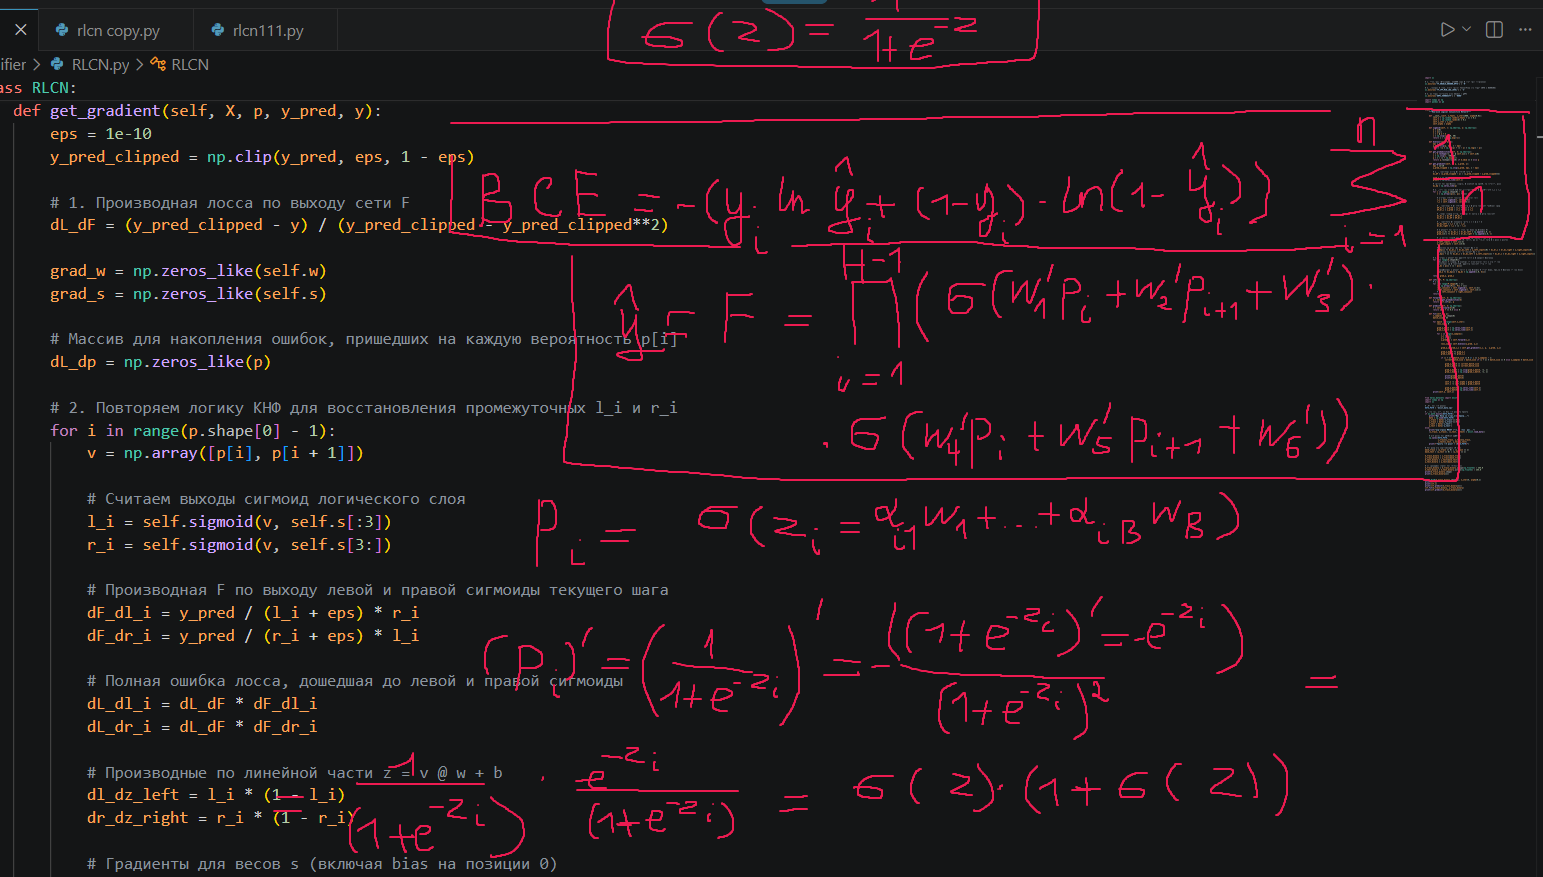" width="793.7572726949114" height="451.4194342551873"/></g></svg>
<!-- #endregion -->
